# Exploratory Data Analysis (EDA) on Obesity dataset
## 1) DATA LOADING & CLEANING
In the first phase of the assignment, we load the dataset, determine how many variables and observations we have available, and understand their nature.<br> We also check for missing values and then look for a solution to the problem.
### Importing libraries
let us import the libraries necessary for the code to function correctly

In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage,fcluster,cophenet
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score 
import gower
from scipy.spatial.distance import squareform
from pyclustering.cluster.kmedoids import kmedoids
from sklearn.manifold import MDS

## Data Loading
We load the dataset and display the first few rows:

In [2]:
dataset = pd.read_csv("Obesity.csv")
display(dataset.head())

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


### Dataset size
Now let's view the number of observations and variables present:

In [3]:
print(f"\n The dataset contains {dataset.shape[0]} observations and {dataset.shape[1]} variables.\n")


 The dataset contains 2114 observations and 17 variables.



We list the variables present, showing their type:

In [4]:
display(dataset.dtypes)

Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

In [5]:
var_numeriche = dataset.select_dtypes(include=["float64"]).columns
var_categoriche = dataset.select_dtypes(exclude=["float64"]).columns
print(f"\n Numeric variables: {list(var_numeriche)} \n")
print(f"\n Categorical variables: {list(var_categoriche)} \n")


 Numeric variables: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'] 


 Categorical variables: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad'] 



It is possible to divide numeric variables into: **Continuous** and **Discrete**:<br><br>
**CONTINOUS**
1. Age
2. Height
3. Weight
<br><br>

**DISCRETE**
1. FCVC (1,2,3)
2. NCP (1,2,3,4)
3. CH2O (1,2,3)
4. FAF (0,1,2,3)
5. TUE (0,1,2)

<br><br>

We can further subdivide categorical variables into: **Nominals** e **Ordinals**: <br><br>
**NOMINALS**
1. Gender (Male/Female)

2. family_history_with_overweight (yes/no)

3. FAVC (yes/no)

4. SMOKE (yes/no)

5. SCC (yes/no)

6. MTRANS (Public_Transportation, Automobile, Walking, Motorbike, Bike) <br><br>

**ORDINALS**

1. CAEC (no, Sometimes, Frequently, Always)

2. CALC (no, Sometimes, Frequently, Always)

3. NObeyesdad (Insufficient_Weight, Normal_Weight, Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III) (**Target Variable**)

For convenience, we have chosen to rename some of the variables in order to facilitate operations.

In [6]:
dataset.rename(columns={"FAVC": "High_Caloric_Food", 
                        "FCVC": "Vegetable_Consumption", 
                        "NCP": "Main_Meals_Per_Day", 
                        "CAEC": "Food_Between_Meals", 
                        "CH2O": "Water_Intake", 
                        "SCC": "Calorie_Monitoring", 
                        "FAF": "Physical_Activity_Frequency", 
                        "TUE": "Tech_use_Time", 
                        "CALC": "Alcohol_Consumption", 
                        "MTRANS": "Transport_Mode", 
                        "NObeyesdad": "Obesity_Level",}, inplace=True)

var_numeriche = dataset.select_dtypes(include=["float64"]).columns
var_categoriche = dataset.select_dtypes(exclude=["float64"]).columns

print(f"\n Numerical variables : {list(var_numeriche)} \n")
print(f"\n Categorical variables: {list(var_categoriche)} \n")


 Numerical variables : ['Age', 'Height', 'Weight', 'Vegetable_Consumption', 'Main_Meals_Per_Day', 'Water_Intake', 'Physical_Activity_Frequency', 'Tech_use_Time'] 


 Categorical variables: ['Gender', 'family_history_with_overweight', 'High_Caloric_Food', 'Food_Between_Meals', 'SMOKE', 'Calorie_Monitoring', 'Alcohol_Consumption', 'Transport_Mode', 'Obesity_Level'] 



Following some inconsistencies found between the numerical values in the dataset, we cleaned the data to ensure greater accuracy. <br>
First, we standardised the unit of measurement for height to centimetres rather than metres to avoid potential approximation errors. <br>
Next, we rounded all numerical values. The changes made are detailed below.

In [7]:
dataset["Height"] *= 100
dataset[var_numeriche] = dataset[var_numeriche].round().astype(int)
display(dataset.head())

,Gender,Age,Height,Weight,family_history_with_overweight,High_Caloric_Food,Vegetable_Consumption,Main_Meals_Per_Day,Food_Between_Meals,SMOKE,Water_Intake,Calorie_Monitoring,Physical_Activity_Frequency,Tech_use_Time,Alcohol_Consumption,Transport_Mode,Obesity_Level
0,Female,21,162,64,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight
1,Female,21,152,56,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,180,77,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight
3,Male,27,180,87,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I
4,Male,22,178,90,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II


### Missing Values
We check for missing values within the data for each variable:

In [8]:
print("\nMissing values for each variable\n")
missing_values = dataset.isna().sum()
display(missing_values)


Missing values for each variable



Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
High_Caloric_Food                 0
Vegetable_Consumption             0
Main_Meals_Per_Day                0
Food_Between_Meals                0
SMOKE                             0
Water_Intake                      0
Calorie_Monitoring                0
Physical_Activity_Frequency       0
Tech_use_Time                     0
Alcohol_Consumption               5
Transport_Mode                    0
Obesity_Level                     1
dtype: int64

In [9]:
missing_values_percent = ((missing_values/len(dataset))*100).round(2)
missing_values_table = pd.DataFrame({"Missing Values": missing_values, "%": missing_values_percent})
display(missing_values_table[missing_values_table["Missing Values"] > 0])

,Missing Values,%
Alcohol_Consumption,5,0.24
Obesity_Level,1,0.05


We can see that there are five missing values relating to alcohol consumption and only one missing value relating to obesity levels. <br> Let's see which row they correspond to: 

In [10]:
print("\nMissing values relating to alcohol consumption:\n")
dataset[dataset["Alcohol_Consumption"].isna()] 


Missing values relating to alcohol consumption:



,Gender,Age,Height,Weight,family_history_with_overweight,High_Caloric_Food,Vegetable_Consumption,Main_Meals_Per_Day,Food_Between_Meals,SMOKE,Water_Intake,Calorie_Monitoring,Physical_Activity_Frequency,Tech_use_Time,Alcohol_Consumption,Transport_Mode,Obesity_Level
13,Male,41,180,99,no,yes,2,3,Sometimes,no,2,no,2,1,NaN,Automobile,Obesity_Type_I
94,Female,24,160,48,no,yes,3,3,Sometimes,no,2,no,2,0,NaN,Public_Transportation,Normal_Weight
162,Female,21,163,60,yes,yes,3,3,Always,yes,2,no,2,0,NaN,Public_Transportation,Normal_Weight
278,Female,32,157,57,yes,yes,3,3,Sometimes,no,2,no,0,0,NaN,Automobile,Normal_Weight
463,Male,17,180,68,yes,no,2,3,Sometimes,no,1,no,2,1,NaN,Public_Transportation,Normal_Weight


In [11]:
print("\n Missing values referring to obesity level\n")
dataset[dataset["Obesity_Level"].isna()] 


 Missing values referring to obesity level



,Gender,Age,Height,Weight,family_history_with_overweight,High_Caloric_Food,Vegetable_Consumption,Main_Meals_Per_Day,Food_Between_Meals,SMOKE,Water_Intake,Calorie_Monitoring,Physical_Activity_Frequency,Tech_use_Time,Alcohol_Consumption,Transport_Mode,Obesity_Level
376,Female,36,158,60,yes,no,3,3,Sometimes,no,1,no,2,0,Sometimes,Automobile,NaN


### Handling missing values
During the previous phase we noticed the absence of 5 observations for the variable relating to alcohol consumption and 1 observation for the variable relating to obesity levels, both of which are categorical. <br>
These represent approximately 0.3% of the entire dataset, so we can say that we can continue to operate by removing the missing values, since continuing with mode-based imputation would result in a high level of complexity that would not benefit the analysis. <br> We could also say that with the imputation of missing values, the risk of introducing a bias, albeit certainly irrelevant, outweighs the benefit of doing so.

In [12]:
dataset_clean = dataset.dropna()
missing_values = dataset_clean.isna().sum()
display(missing_values)

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
High_Caloric_Food                 0
Vegetable_Consumption             0
Main_Meals_Per_Day                0
Food_Between_Meals                0
SMOKE                             0
Water_Intake                      0
Calorie_Monitoring                0
Physical_Activity_Frequency       0
Tech_use_Time                     0
Alcohol_Consumption               0
Transport_Mode                    0
Obesity_Level                     0
dtype: int64

In [13]:
print("Impact Analysis of removing missing values\n")

# Original dataset vs. cleaned dataset
original_shape = dataset.shape
clean_shape = dataset_clean.shape

print(f"Original dataset: {original_shape[0]} observations")
print(f"Clean dataset: {clean_shape[0]} observations")
print(f"Removed: {original_shape[0] - clean_shape[0]} ({((original_shape[0] - clean_shape[0])/original_shape[0])*100:.2f}%)\n")

Impact Analysis of removing missing values

Original dataset: 2114 observations
Clean dataset: 2108 observations
Removed: 6 (0.28%)



## 2) UNIVARIATE DATA DESCRIPTION 
We perform a statistical analysis that examines and summarises the characteristics of each variable individually.
<br>
The dataset features have been separated into numeric and discrete ordinal variables.

This distinction is crucial because, although both types are represented by numbers, they require different statistical treatments:

- **Numeric variables**: These represent continuous measurements or actual counts, for which mathematical operations (such as calculating the mean or standard deviation) provide meaningful physical information.

- **Discrete ordinal variables** : These represent ordered categories. For these variables, the "distance" between values is not necessarily uniform. Therefore, measures of central tendency such as the median or mode and frequency distributions are statistically more valid than the arithmetic mean.

Furthermore, by isolating these groups, we ensure that descriptive statistics and subsequent visualizations (such as histograms for numeric data versus bar charts for ordinal data) accurately reflect the true nature of the information.

In [14]:
num_vars = dataset_clean.select_dtypes(include=[np.number]).columns
cat_vars = dataset_clean.select_dtypes(include=["object"]).columns

discrete_ordinal_vars = [ 'Vegetable_Consumption', 'Water_Intake', 'Tech_use_Time']

num_vars = [col for col in num_vars if col not in discrete_ordinal_vars]

print("Numeric Variables")
print(num_vars)
print("\nDiscrete Ordinal Variables")
print(discrete_ordinal_vars)

Numeric Variables
['Age', 'Height', 'Weight', 'Main_Meals_Per_Day', 'Physical_Activity_Frequency']

Discrete Ordinal Variables
['Vegetable_Consumption', 'Water_Intake', 'Tech_use_Time']


### Descriptive Statistics
Let's start by calculating the main descriptive statistics for the cleaned dataset. <br>

In [15]:
print("\nDescriptive statistics relating to numerical variables: \n")
stats_n = dataset_clean[num_vars].describe()
stats_n.rename(index={"50%": "median"}, inplace=True)
stats_n.loc["skewness"] = dataset_clean.skew(numeric_only=True)
stats_n.loc["kurtosis"] = dataset_clean.kurt(numeric_only=True)
stats_n = stats_n.round(2)
display(stats_n)


Descriptive statistics relating to numerical variables: 



,Age,Height,Weight,Main_Meals_Per_Day,Physical_Activity_Frequency
count,2108.00,2108.00,2108.00,2108.00,2108.00
mean,24.30,170.17,86.61,2.69,1.01
std,6.34,9.33,26.20,0.81,0.90
min,14.00,145.00,39.00,1.00,0.00
25%,20.00,163.00,66.00,3.00,0.00
median,23.00,170.00,83.00,3.00,1.00
75%,26.00,177.00,107.25,3.00,2.00
max,61.00,198.00,173.00,4.00,3.00
skewness,1.53,-0.01,0.25,-1.06,0.46
kurtosis,2.84,-0.56,-0.70,0.37,-0.71


<ul>
    <li><b>Age:</b> Skewness indicates a strong positive skewness (right-tailed). This means that most people in the dataset are young (75% are under 26), but there are some much older individuals (up to 61) who tend to push the mean higher. <br>
        The high kurtosis confirms the presence of outliers. </li>
    <li><b>Height:</b> The almost zero skewness (-0.01) tells us that the height is perfectly symmetrically distributed. <br>
        The mean and median coincide at 170 cm.  </li> 
    <li><b>Weight:</b> Weight has a very high standard deviation (26.20 kg), indicating significant heterogeneity in the sample. It ranges from a minimum of 39 kg to a maximum of 173 kg. <br>
        The slight right-hand skewness, suggesting a significant presence of overweight subjects.</li>
    <li><b>Main_Meals_Per_Day:</b> The 25th, 50th (median), and 75th percentiles are all equal to 3.00. This means that the vast majority of the sample consumes exactly 3 meals a day.</li>
    <li><b>Physical_Activity_Frequency:</b> Given the mean and median, the population analyzed appears to have a generally sedentary lifestyle or one with moderate physical activity. <br> 
    Negative kurtosis indicates a "platycurtic" (flat) distribution. This means that there is no strong concentration on a single value, but rather the subjects are spread across the various levels.</li>
    
</ul>


 Distributions of numerical variables: 



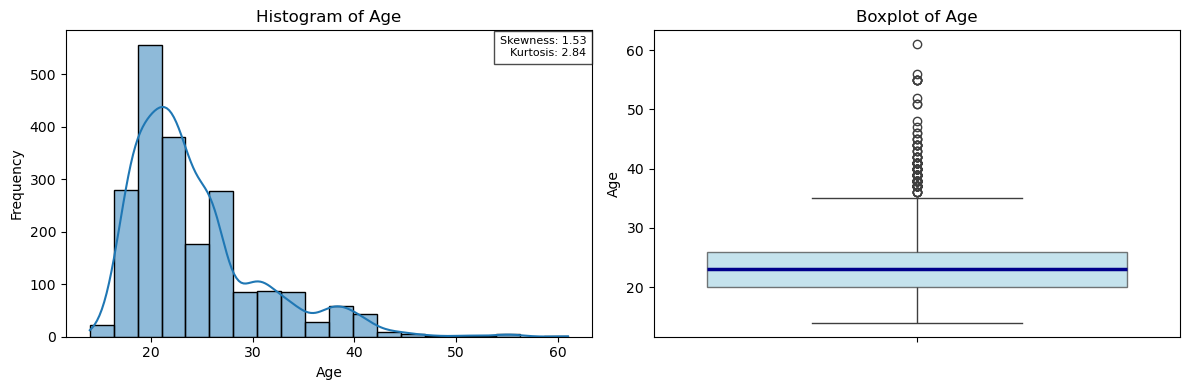

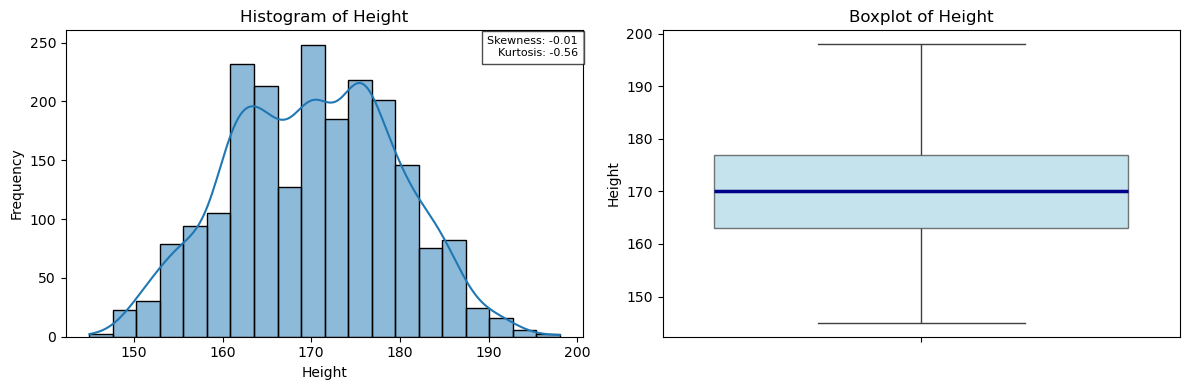

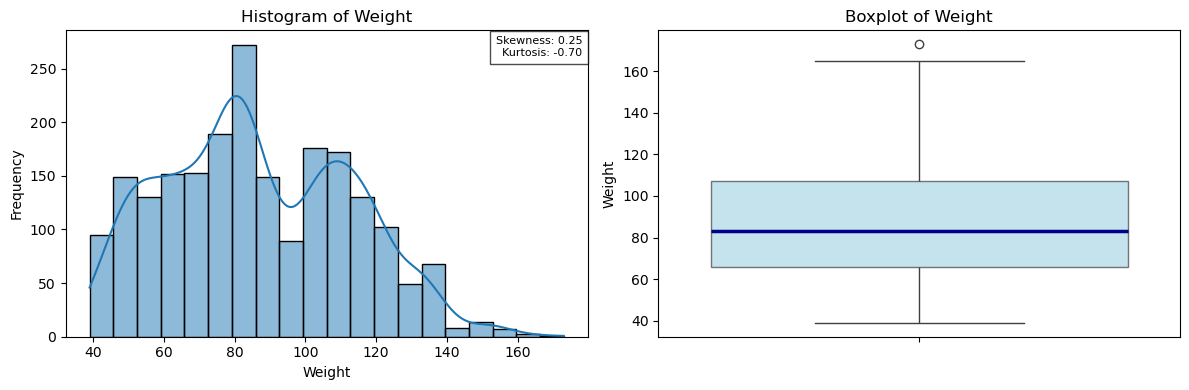

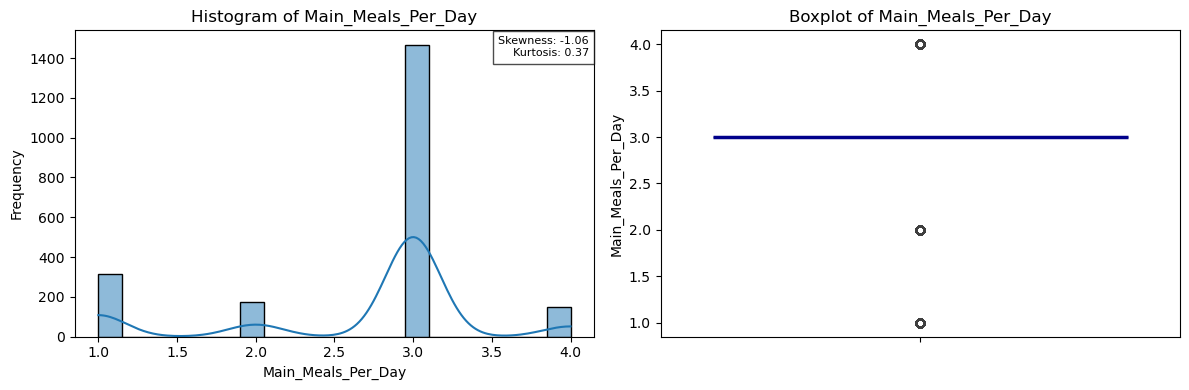

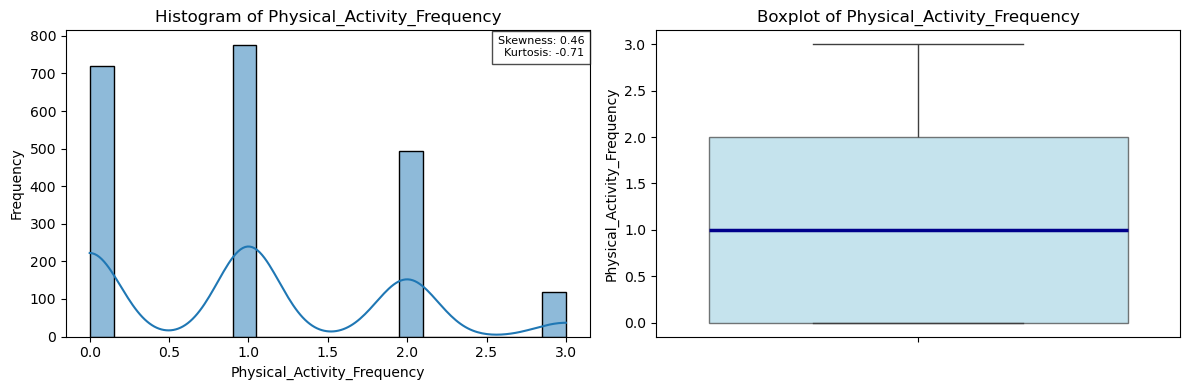

In [16]:
print("\n Distributions of numerical variables: \n")

for var in num_vars:
    skew_val = dataset_clean[var].skew()
    kurt_val = dataset_clean[var].kurt()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # histogram
    sns.histplot(dataset_clean[var], kde=True, bins=20, ax=axes[0], )
    axes[0].set_title(f"Histogram of {var}")
    axes[0].set_xlabel(var)
    axes[0].set_ylabel("Frequency")

    # skewness + kurtosis 
    axes[0].text(
        0.99, 0.98,
        f"Skewness: {skew_val:.2f}\nKurtosis: {kurt_val:.2f}",
        ha="right", va="top",
        transform=axes[0].transAxes,
        fontsize=8,
        bbox=dict(facecolor="white", edgecolor="black", alpha=0.7)
    )

    # boxplot
    sns.boxplot(y=dataset_clean[var], ax=axes[1], boxprops=dict(facecolor="lightblue", alpha=0.7), medianprops=dict(color="darkblue", linewidth=2.5))
    axes[1].set_title(f"Boxplot of {var}")
    axes[1].set_ylabel(var)

    plt.tight_layout()
    plt.show()

<ul>
    <li><b>Age:</b>
        <ul>
            <li><b>Histogram:</b>This confirms the high positive skewness. The bulk of the data is between 18 and 25 years old. The distribution is not a clean bell-shaped curve and drops rapidly after age 20.</li>
            <li><b>Boxplot:</b>The presence of many outliers is noted</li>
        </ul></li>
    <li><b>Height:</b> 
        <ul>
            <li><b>Histogram:</b>Kde almost perfectly symmetric</li>
            <li><b>Boxplot:</b>There are no outliers</li>
        </ul></li>
    <li><b>Weight:</b>
        <ul>
            <li><b>Histogram:</b> Bimodal distribution. There's a peak around 80 kg and another, smaller one around 110-120 kg. This suggests that the sample is naturally divided between those two weight ranges.</li>
            <li><b>Boxplot:</b>There is only one outlier near 180 kg.</li>
        </ul></li>
    <li><b>Main_Meals_Per_Day:</b> 
        <ul>
            <li><b>Histogram:</b>Here we clearly see why the skewness was negative. <br>
                Almost everyone is on the 3 meal bar. The bars on 1 and 2 are very low, creating that tail on the left.</li>
            <li><b>Boxplot:</b>It appears flat because 25th, the median, and 75th percentiles all fall on the same value. Outliers at the 1st, 2nd, and 4th percentiles are considered such because the vast majority behave identically (3 meals).</li>
        </ul></li>
    <li><b>Physical_Activity_Frequency:</b>
        <ul>
            <li><b>Histogram:</b>Since it's a discrete variable, the histogram shows sharp peaks. The highest values ​​are recorded at 0 and 1, confirming a generally sedentary lifestyle.</li>
            <li><b>Boxplot:</b>People are fairly evenly distributed across various levels of laziness or activity.</li>
        </ul> </li>
    
</ul>

Given the high presence of outliers in the boxplot of the age variable, let's now try to calculate their real number:

In [17]:
Q1 = dataset_clean["Age"].quantile(0.25)
Q3 = dataset_clean["Age"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
    
outliers = dataset_clean[(dataset_clean["Age"] < lower_bound) | (dataset_clean["Age"] > upper_bound)]
perc = (len(outliers)/dataset_clean.shape[0])*100
print("Lower Bound: ", lower_bound)
print("Upper Bound: ", upper_bound)
print(f"Outliers: {len(outliers)} ({perc:.1f}%)")

Lower Bound:  11.0
Upper Bound:  35.0
Outliers: 158 (7.5%)


Anyone aged 36 and over is considered an anomaly by the IQR method compared to the sample size. <br>
This confirms the sample's bias toward younger subjects, although it does not exclude older subjects.
<br><br><br>
We also examine the number of outliers related to weight:

In [18]:
Q1 = dataset_clean["Weight"].quantile(0.25)
Q3 = dataset_clean["Weight"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
    
outliers = dataset_clean[(dataset_clean["Weight"] < lower_bound) | (dataset_clean["Weight"] > upper_bound)]
perc = (len(outliers)/dataset_clean.shape[0])*100
print("Lower Bound: ", lower_bound)
print("Upper Bound: ", upper_bound)
print("Outliers: ", len(outliers))
print(f"Outliers: {len(outliers)} ({perc:.2f}%)")

Lower Bound:  4.125
Upper Bound:  169.125
Outliers:  1
Outliers: 1 (0.05%)


There is only one outlier which evidently corresponds to the maximum value found previously (173 kg)
<br><br><br>

Since the boxplot for the number of main meals collapsed, we chose to use a violin plot instead.

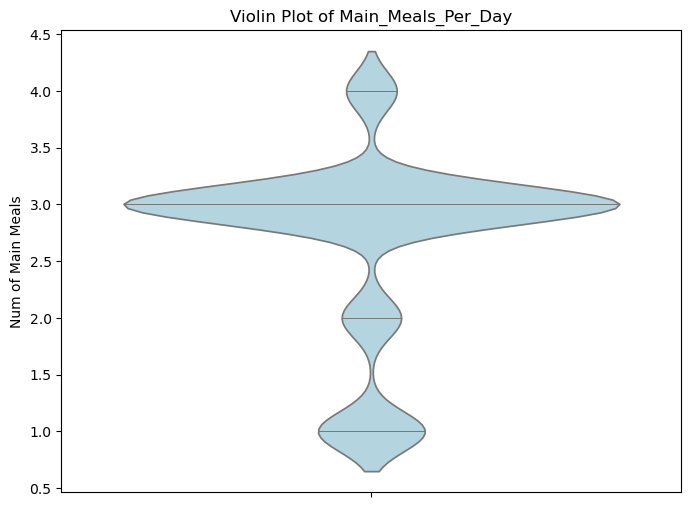

In [19]:
plt.figure(figsize=(8, 6))

sns.violinplot(y=dataset_clean['Main_Meals_Per_Day'], color="lightblue", inner="stick")
plt.title(f"Violin Plot of {'Main_Meals_Per_Day'}")
plt.ylabel("Num of Main Meals")
plt.show()

While the boxplot only said that almost everyone eats 3 times and the rest are seen as exceptions, the Violin plot says that almost everyone eats 3 times, but there is a clear hierarchy between the exceptions. <br><br>
Skipping meals is a more common habit (1 and 2 bulb more pronounced) than eating extra meals (4 bulb thinner). <br><br>

In [20]:
print("\nDescriptive Statistics for Discrete Ordinal Variables: \n")
stats_d = pd.DataFrame({
    'median': dataset_clean[discrete_ordinal_vars].median(),
    'mode': dataset_clean[discrete_ordinal_vars].mode().iloc[0]
})

display(stats_d.T)


Descriptive Statistics for Discrete Ordinal Variables: 



,Vegetable_Consumption,Water_Intake,Tech_use_Time
median,2.0,2.0,1.0
mode,2.0,2.0,0.0


<ul>
    <li><b>Vegetable_Consumption:</b> The mode and the median coincide</li>
    <li><b>Water_Intake:</b> The mode and the median coincide</li>
    <li><b>Tech_use_Time:</b> Positive skew</li>
</ul>

In [21]:
print("\nDescriptive Statistics for Categorical Variables: \n")
stats_c = dataset_clean[cat_vars].describe()
stats_c.rename(index={"top": "mode"}, inplace=True)
stats_c = stats_c.round(2)
display(stats_c)


Descriptive Statistics for Categorical Variables: 



,Gender,family_history_with_overweight,High_Caloric_Food,Food_Between_Meals,SMOKE,Calorie_Monitoring,Alcohol_Consumption,Transport_Mode,Obesity_Level
count,2108,2108,2108,2108,2108,2108,2108,2108,2108
unique,2,2,2,4,2,2,4,5,7
mode,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_I
freq,1067,1722,1864,1763,2065,2012,1399,1579,350


<ul>
    <li><b>Gender:</b>The sample is equally divided between males and females</li>
    <li><b>family_history_with_overweight:</b>Most of the people in the dataset have a family history of being overweight. <br>
        This suggests that family history is a dominant factor.</li>
    <li><b>High_Caloric_Food:</b>The majority of people eat high caloric foods</li>
    <li><b>Food_Between_Meals:</b>Eating between meals is a common habit, but not extreme for most.</li>
    <li><b>SMOKE:</b>The sample is almost entirely composed of nonsmokers. <br>
        This means that smoking will not be a significant discriminant variable for the analysis of obesity, since there is very little variance.</li>
    <li><b>Calorie_Monitoring:</b>Almost no one tracks calories</li>
    <li><b>Alcohol_Consumption:</b>Alcohol consumption is common but not excessive</li>
    <li><b>Transport_Mode:</b>The most used means of transport is public transport</li>
    <li><b>Obesity_Level:</b>Having 2108 observations and 7 modes in total for this variable, if they were perfectly balanced we should have about 300 observations per class. <br>
        Therefore, given the value of the mode, the dataset appears to be quite well balanced.</li>
</ul>

In [22]:
#print("\nFrequency tables: \n")
#list(var_cat)
#for var in (discrete_ordinal_vars + list(var_cat)):
#    freq = dataset_clean[var].value_counts()
#    perc = dataset_clean[var].value_counts(normalize=True) * 100

#    table = pd.DataFrame({
#        "Frequency": freq,
#        "Percentage (%)": perc.round(2)
#    })

#    display(table)
#    print("\n")

In [23]:
#print("\n Distributions of categorical variables: \n")
#for var in (discrete_ordinal_vars + list(var_cat)):
#    plt.figure(figsize=(12,4))
#    sns.countplot(x=dataset_clean[var])
#    plt.title(f"Frequency of categories in {var}")
#    plt.xlabel(var)
#    plt.ylabel("Count")
#    plt.xticks(rotation=45)
#    plt.show()

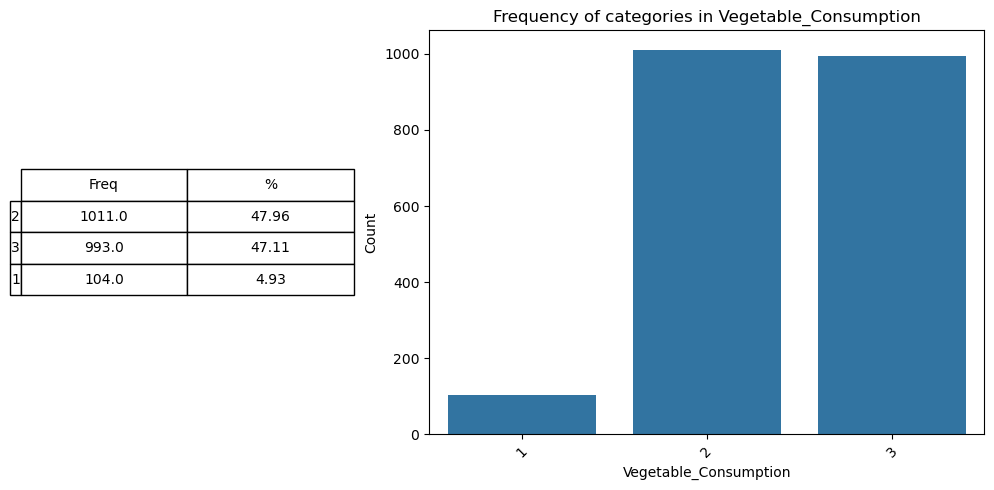

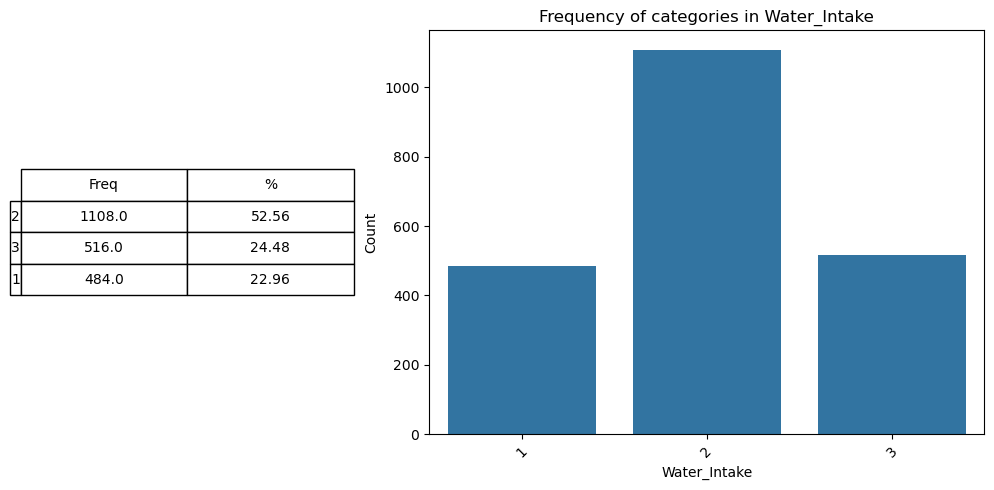

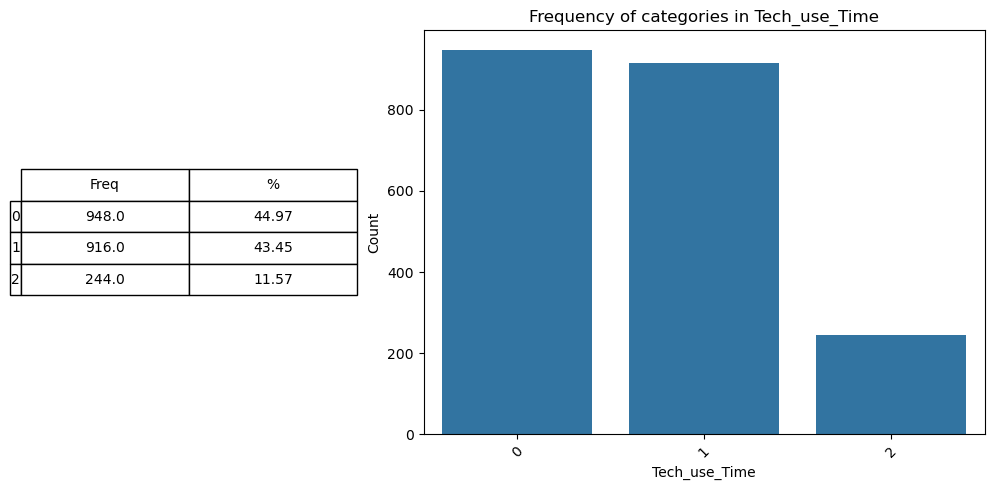

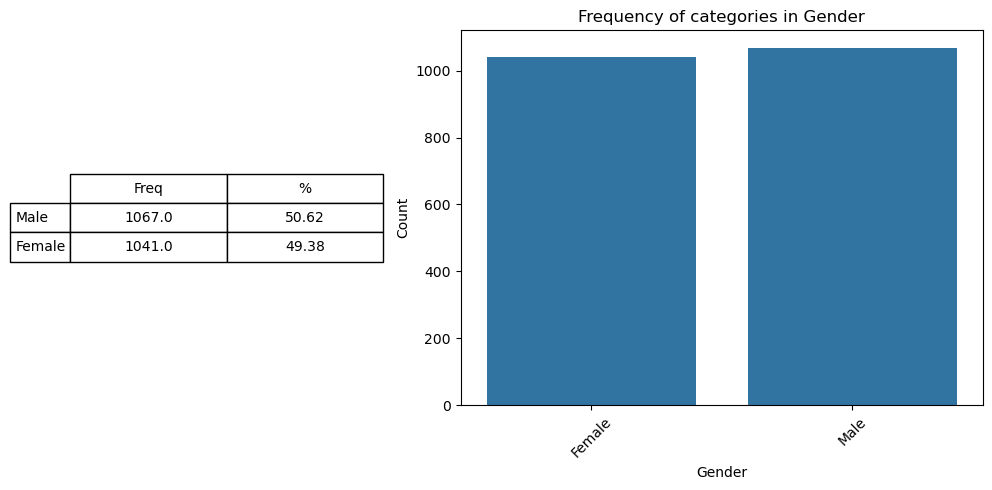

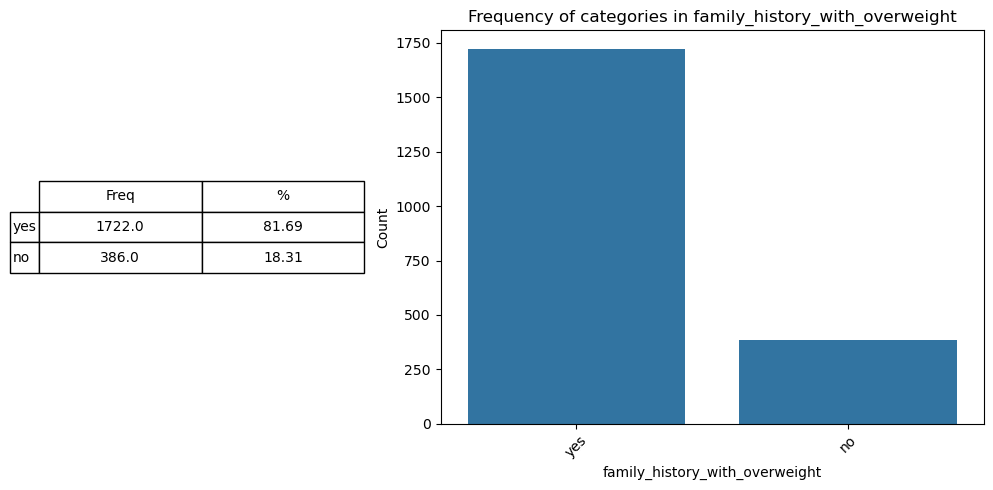

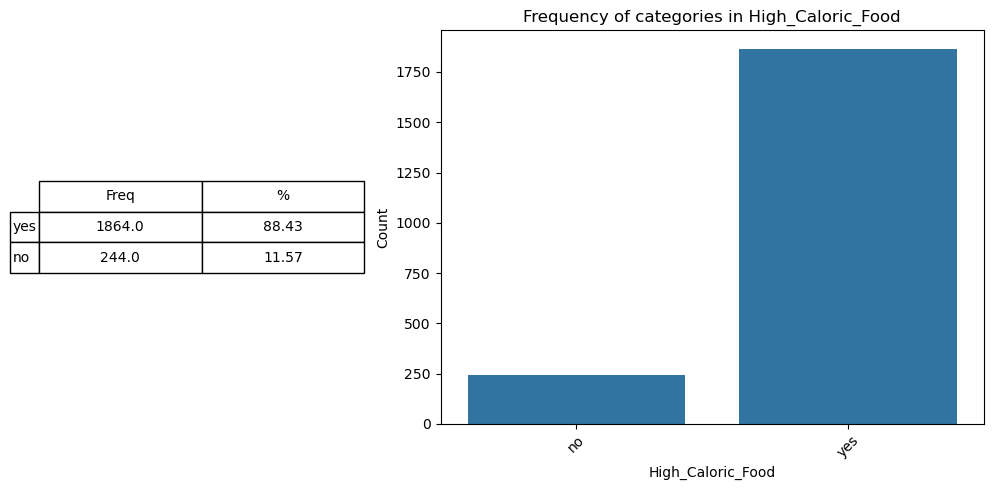

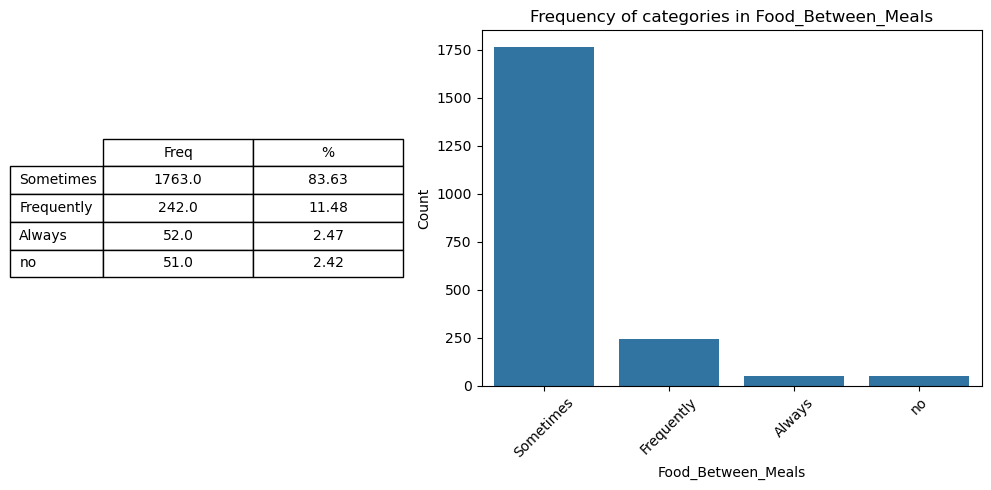

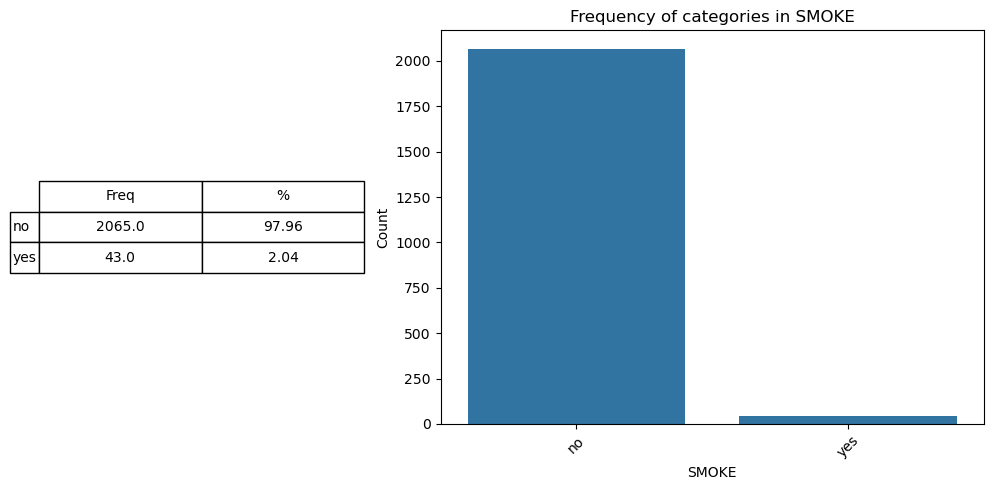

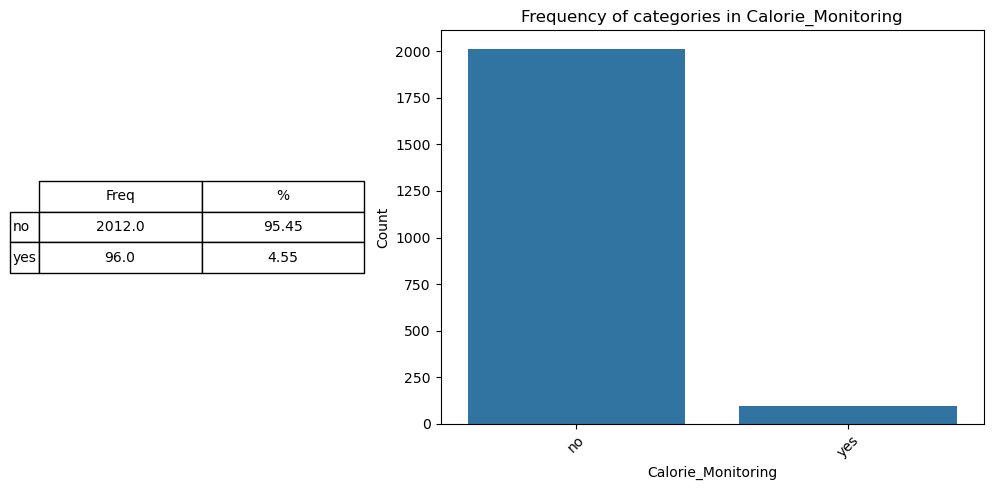

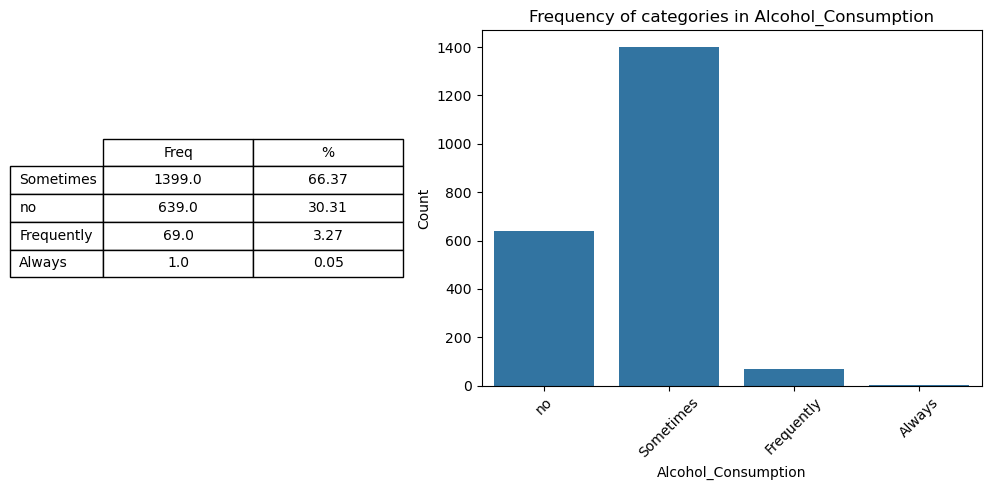

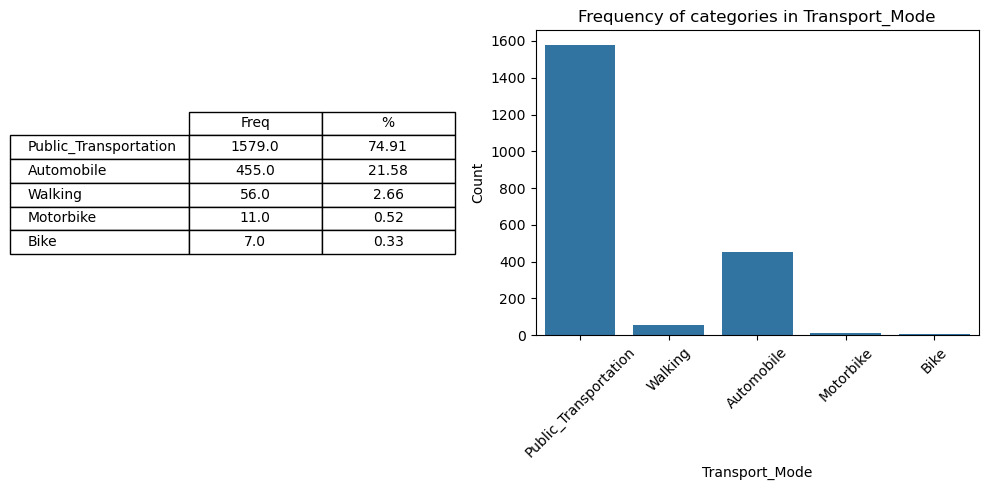

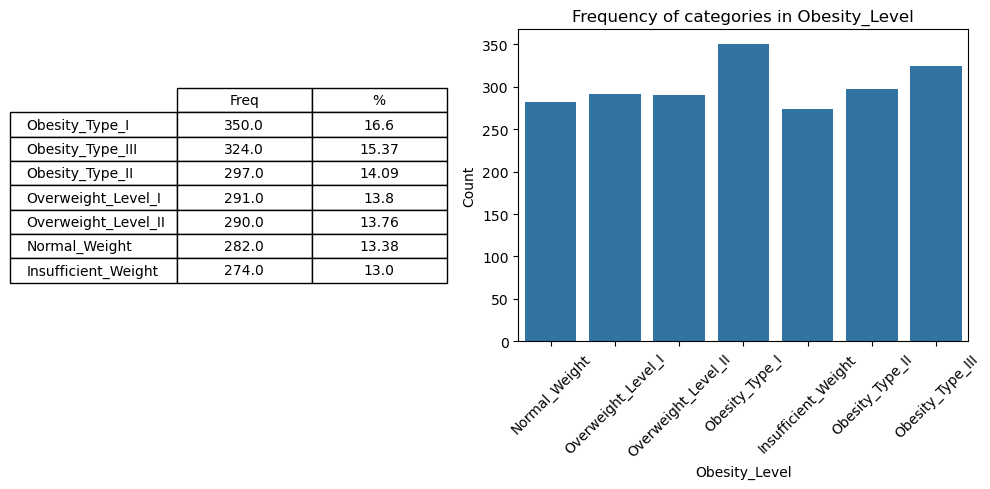

In [24]:
vars_to_analyze = discrete_ordinal_vars + list(cat_vars)

for var in vars_to_analyze:

    freq = dataset_clean[var].value_counts()
    perc = (dataset_clean[var].value_counts(normalize=True) * 100).round(2)
    table_df = pd.DataFrame({"Freq": freq, "%": perc})

    fig, (ax_table, ax_plot) = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'width_ratios': [1, 2]})

    # frequency table
    ax_table.axis('tight')
    ax_table.axis('off')  # Nascondiamo gli assi perché vogliamo solo vedere la tabella
    
    freq_table = ax_table.table(cellText=table_df.values, 
                              rowLabels=table_df.index, 
                              colLabels=table_df.columns, 
                              loc='center', 
                              cellLoc='center')

    freq_table.set_fontsize(10)
    freq_table.scale(1.2, 1.8) 

    

    # barplot
    sns.countplot(data=dataset_clean, x=var, ax=ax_plot)
    ax_plot.set_title(f"Frequency of categories in {var}")
    ax_plot.set_xlabel(var)
    ax_plot.set_ylabel("Count")
    
    plt.sca(ax_plot)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

<ul>
    <li><b>Vegetable_Consumption:</b> Almost all of the group follows a diet that regularly includes vegetables.</li>
    <li><b>Water_Intake:</b> Most people have a moderate water intake, with about a quarter of the sample drinking a lot and another quarter possibly being underhydrated.</li>
    <li><b>Tech_use_Time:</b> Categories 0 and 1 account for almost all observations. This indicates low technological exposure.</li>
    <li><b>Gender:</b> The demographic composition with respect to gender is extremely balanced.</li>
    <li><b>family_history_with_overweight:</b> There is a very strong hereditary or environmental-family component in the sample. The vast majority of the analyzed group has a genetic predisposition or shares household habits that favor excess weight.</li>
    <li><b>High_Caloric_Food:</b> Almost all of the people analyzed regularly consume high caloric foods.</li>
    <li><b>Food_Between_Meals:</b> Only a tiny percentage tend not to consume food between meals</li>
    <li><b>SMOKE:</b> The sample is almost entirely made up of non-smokers. This suggests that the health risks of this group are linked almost exclusively to nutrition and genetics</li>
    <li><b>Calorie_Monitoring:</b> Only a very small portion of subjects eat by tracking calories. The remainder feed intuitively and uncontrollably, increasing the risk of unintentional calorie surplus.</li>
    <li><b>Alcohol_Consumption:</b> Alcohol does not appear to be a risk factor for this group, although it occasionally contributes to the total caloric balance.</li>
    <li><b>Transport_Mode:</b> There is a very heavy dependence on public transport.</li>
    <li><b>Obesity_Level:</b> Unlike the other variables, there is no single dominant category here. The frequencies are fairly evenly distributed across the various degrees of obesity. <br> 
        However, if we add the categories of overweight and obesity, we obtain an absolute majority of the sample. </li>
</ul>

## 3) BIVARIATE AND MULTIVARIATE DESCRIPTION
After examining the individual features of the dataset in the univariate section, the goal of this section is to investigate the interactions between the variables. <br>

### Relationships between Numerical Variables
We begin by exploring the degree of association between quantitative data. 
By calculating the Correlation Matrix and visualizing it using Heatmap, we identify the strongest links (positive or negative) between the various factors.

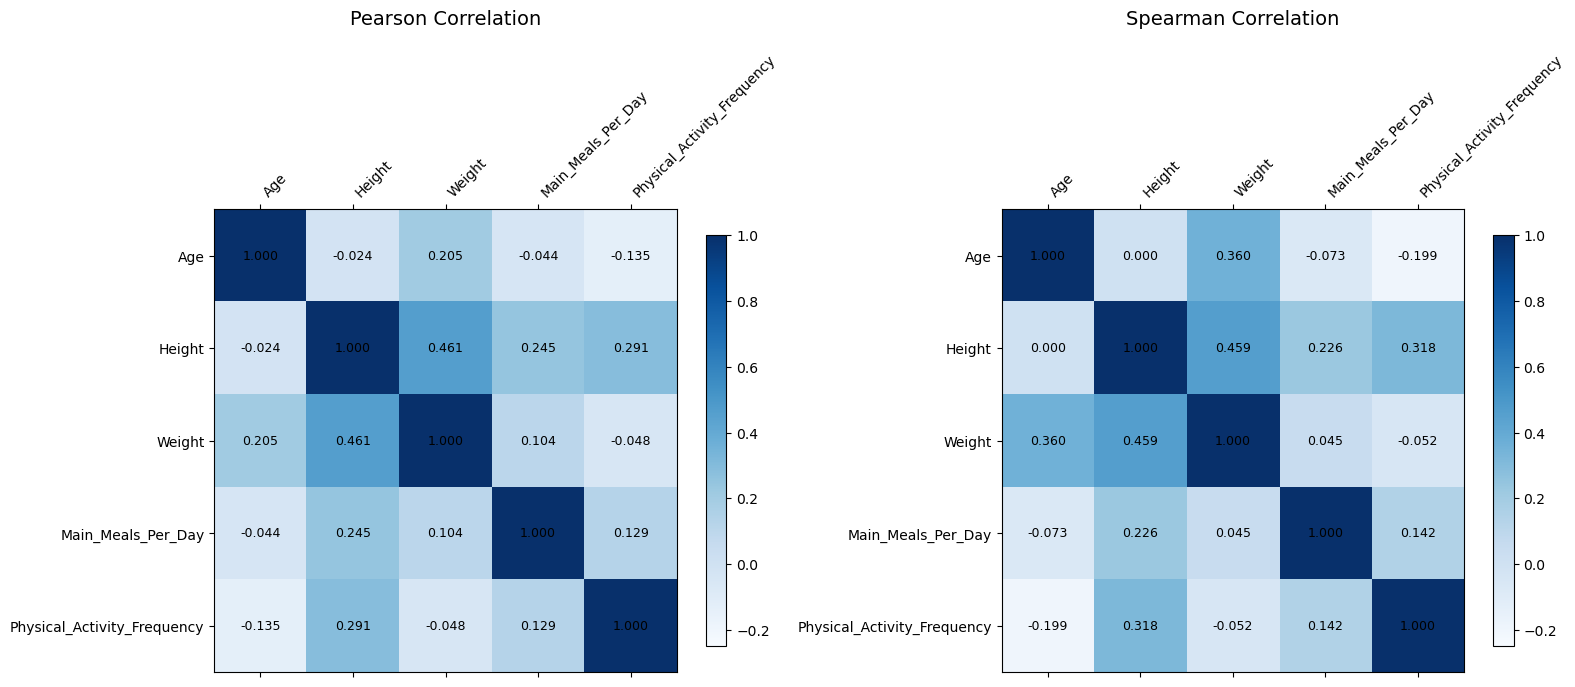

In [25]:
# Calcola le due matrici di correlazione
corr_matrix_pearson = dataset_clean[num_vars].corr(method='pearson')
corr_matrix_spearman = dataset_clean[num_vars].corr(method='spearman')

# Crea una figura con due subplot affiancati
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Heatmap Pearson
cax1 = ax1.matshow(corr_matrix_pearson, cmap="Blues", vmin=-0.25, vmax=1)
fig.colorbar(cax1, ax=ax1, shrink=0.8)

for i in range(len(corr_matrix_pearson)):
    for j in range(len(corr_matrix_pearson)):
        ax1.text(j, i, f'{corr_matrix_pearson.iloc[i, j]:.3f}', 
                ha='center', va='center', fontsize=9)

ax1.set_xticks(range(len(corr_matrix_pearson.columns)))
ax1.set_yticks(range(len(corr_matrix_pearson.columns)))
ax1.set_xticklabels(corr_matrix_pearson.columns, rotation=45, ha='left', fontsize=10)
ax1.set_yticklabels(corr_matrix_pearson.columns, fontsize=10)
ax1.set_title("Pearson Correlation", fontsize=14, pad=20)

# Heatmap Spearman
cax2 = ax2.matshow(corr_matrix_spearman, cmap="Blues", vmin=-0.25, vmax=1)
fig.colorbar(cax2, ax=ax2, shrink=0.8)

for i in range(len(corr_matrix_spearman)):
    for j in range(len(corr_matrix_spearman)):
        ax2.text(j, i, f'{corr_matrix_spearman.iloc[i, j]:.3f}', 
                ha='center', va='center', fontsize=9)

ax2.set_xticks(range(len(corr_matrix_spearman.columns)))
ax2.set_yticks(range(len(corr_matrix_spearman.columns)))
ax2.set_xticklabels(corr_matrix_spearman.columns, rotation=45, ha='left', fontsize=10)
ax2.set_yticklabels(corr_matrix_spearman.columns, fontsize=10)
ax2.set_title("Spearman Correlation", fontsize=14, pad=20)

plt.tight_layout()
plt.show()

Comparison of Pearson and Spearman coefficients confirms the prevalence of nonlinear relationships within the dataset. <br>
In particular, the relationship between Age and Weight shows a Spearman coefficient significantly higher than Pearson's, indicating a non-rectilinear trend. <br>The only relationship that shows a consistent linear nature is that between Height and Weight.<br><br>
Spearman's coefficient was favored for correlation analysis, as it was more suitable for capturing the nonlinear relationships that emerged. <br>Furthermore, the discrete nature of some behavioral variables and the presence of numerous outliers make Spearman a more robust and reliable indicator than Pearson's coefficient, which underestimates non-strictly linear relationships.
<br><br>

From the correlation matrix we can draw the following conclusions:
<ul>
    <li><b>Age-Weight:</b> The coefficient indicates that there is a tendency for weight gain with advancing age.</li>
    <li><b>Age-Physical_Activity_Frequency:</b> There is a slight negative correlation</li>
    <li><b>Height-Weight:</b> Weight gain is proportional to height</li>
    <li><b>Height-Physical_Activity_Frequency:</b> A moderate link is noted between height and frequency of physical activity. <br>
        This may suggest that the highest subjects in the sample are those who practice sports more consistently, or that there is a link between physical development and active lifestyle</li>
    <li><b>Weight-Main_Meals_Per_Day:</b> Weight does not appear to be correlated with the number of meals eaten</li>
    <li><b>Weight-Physical_Activity_Frequency:</b> Strangely, the negative correlation is very weak</li>
</ul>

<br><br>
Scatterplots are usually used to visualize linear relationships between continuous variables. <br>
A scatterplot projects each individual as a point in a Cartesian plane.<br>
The purpose is to see the shape of the cloud. If the points follow a direction, there is a relationship.<br>
Furthermore, this graph shows us how weight categories actually separate.<br>

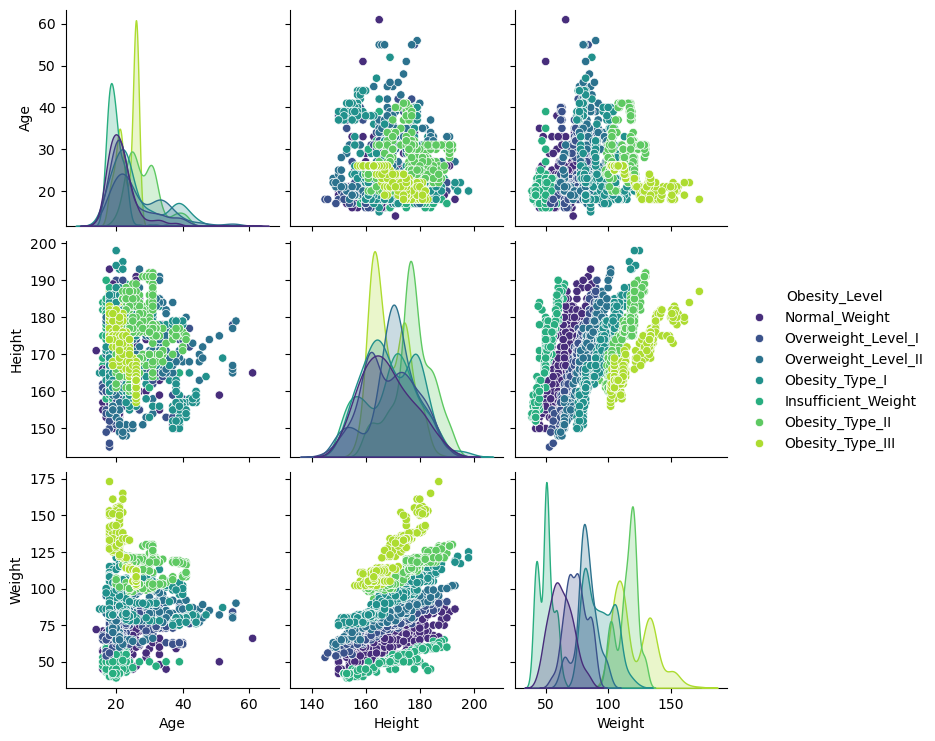

In [26]:
continuous_vars = ['Age', 'Height', 'Weight']
sns.pairplot(dataset_clean[continuous_vars + ['Obesity_Level']], 
             hue="Obesity_Level", 
             palette = sns.color_palette(palette="viridis", n_colors = 7),
             diag_kind="kde")

plt.show()

**Height vs Weight**:
- The points are arranged along an ascending diagonal. So, as height increases, weight increases
- Obesity categories form nearly perfect diagonal stripes. <br><br>
**Conclusion**: Strong positive linear relationship between Height and Weight.
<br><br><br>
**Age vs Weight**:
- The points are very scattered. There is no clear direction
- We note that Obesity_Type_III is almost exclusively concentrated in the 20-30 age group. This indicates that the most severe cases of obesity in this dataset do not involve older people, but young adults. <br><br>
**Conclusion**: No clear linear relationship between Age and Weight.
<br><br><br>

**Age vs Height**:
- No obvious inclination
- Height doesn't depend much on age<br><br>
**Conclusion**: No significant linear relationship between Age and Height.
<br><br><br>


When we cross a continuous variable with a discrete, the points all stack on vertical columns, making the graph uninformative.
We replaced the scatterplots with **boxplots**.
In this case, to observe a relationship, we need to look at how the medians move:
- **Linear Relationship**: If the medians of the various boxplots rise or fall steadily, the relationship is linear.

- **Nonlinear Relationship**: If the medians form a curve, the relationship is nonlinear. <br>

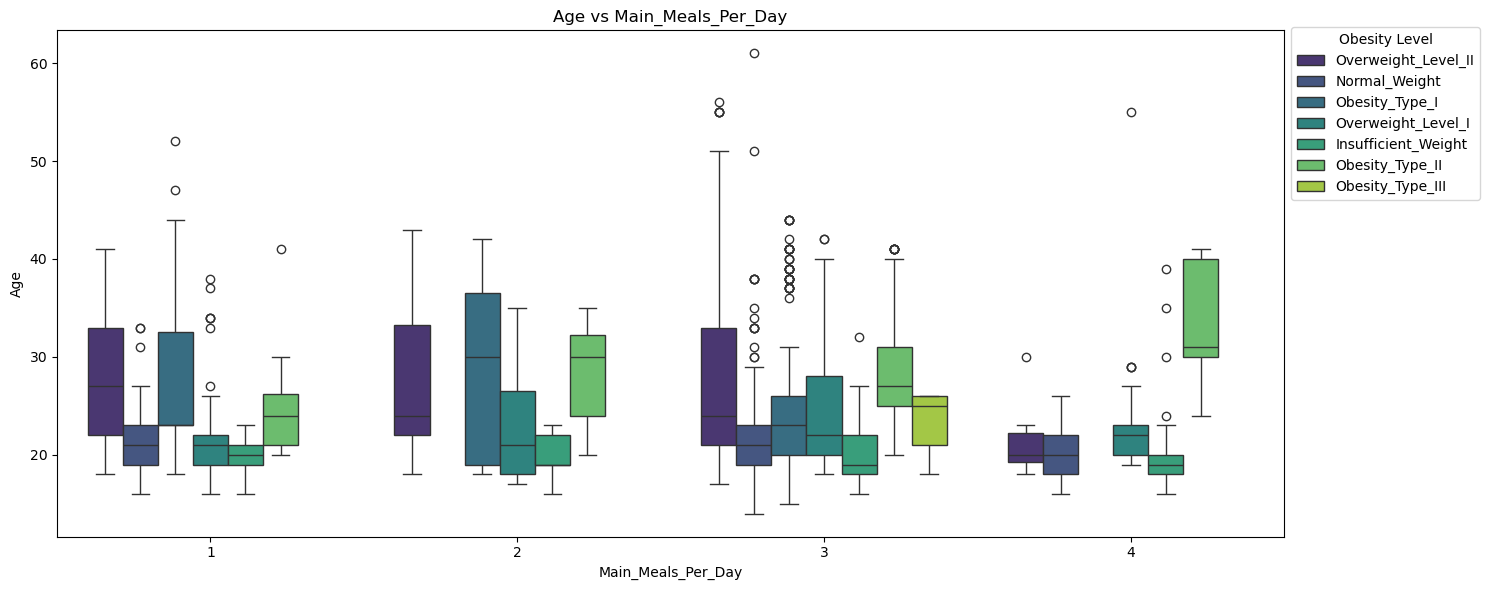

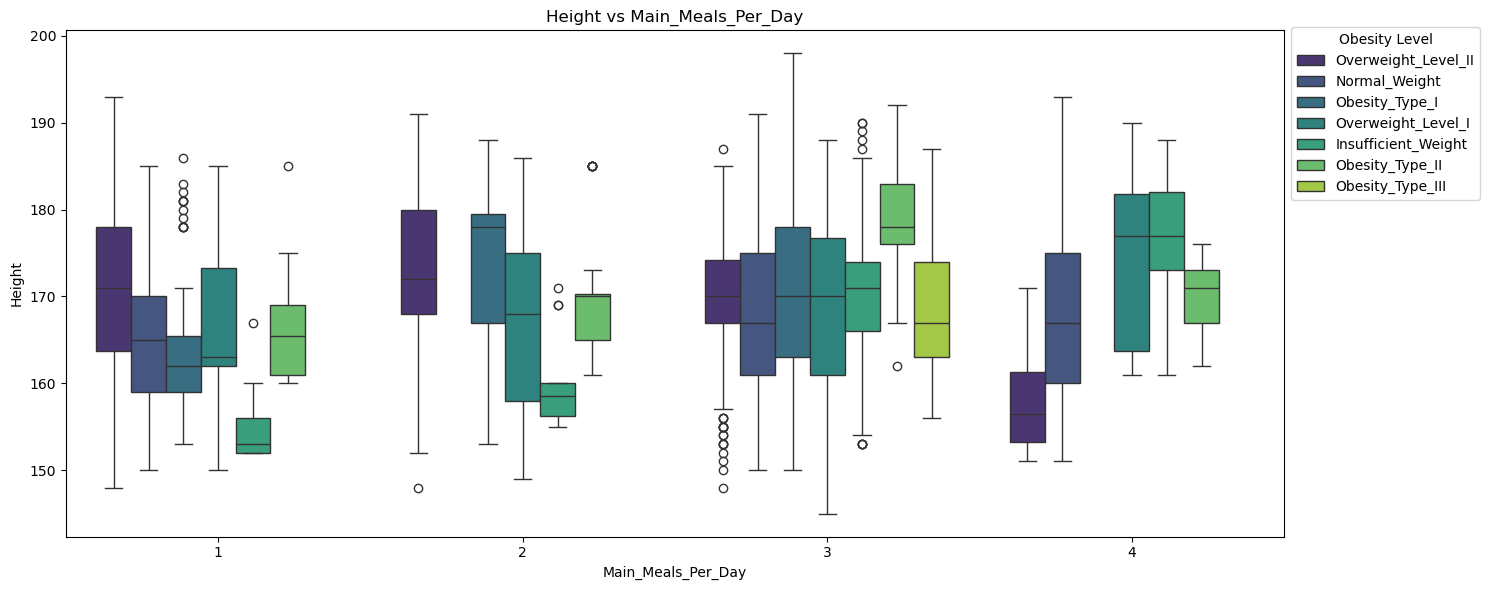

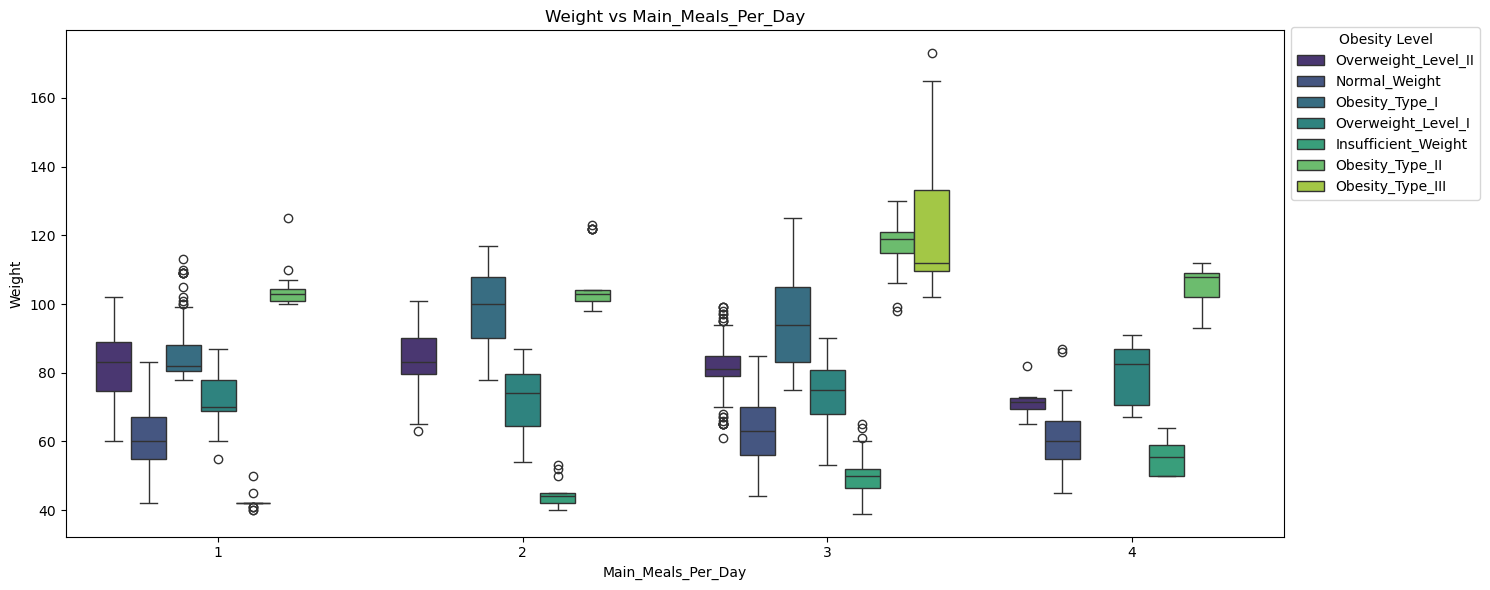

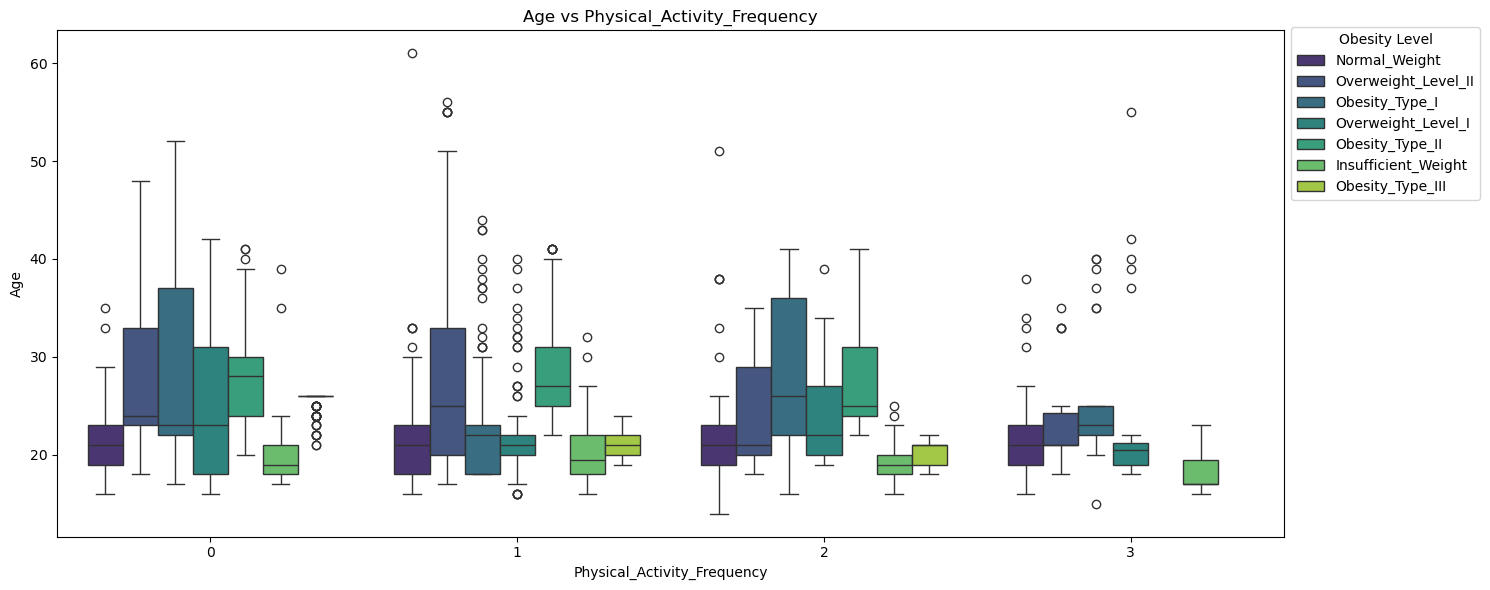

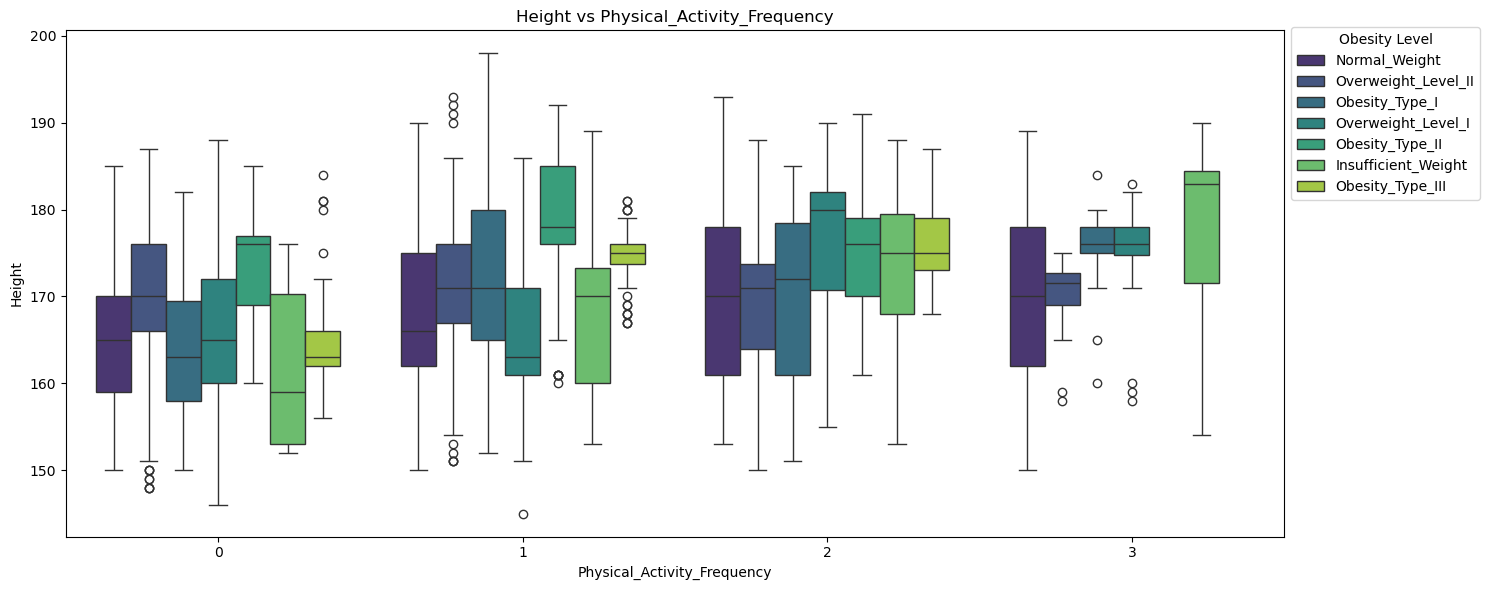

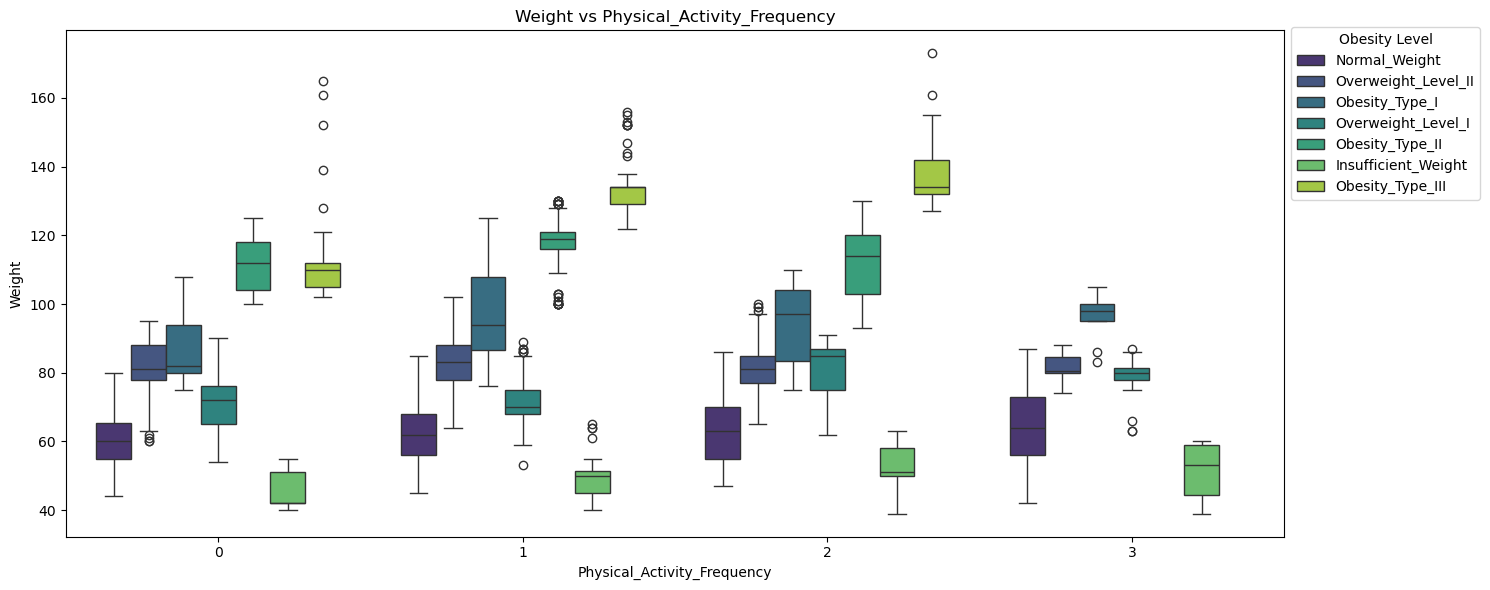

In [27]:
discrete_vars = ['Main_Meals_Per_Day', 'Physical_Activity_Frequency']
for disc in discrete_vars:
    for cont in continuous_vars:
        plt.figure(figsize=(15, 6))
        ax = sns.boxplot(data=dataset_clean, hue='Obesity_Level', 
                        palette=sns.color_palette(palette="viridis", n_colors=7), 
                        x=disc, 
                        y=cont)
        
        # Legenda all'esterno a destra
        plt.legend(title='Obesity Level', loc='upper left', bbox_to_anchor=(1, 1.02))
        
        plt.title(f"{cont} vs {disc}")
        plt.xlabel(f"{disc}")
        plt.ylabel(f"{cont}")
        plt.tight_layout()
        plt.show()

<ul>
    <li><b>Age vs Main_Meals_Per_Day:</b> No linear relationship is observed between the age and the number of meals. Although there are variations in medians between groups, they do not follow a constant incremental or decremental trend.</li>
    <br>
    <li><b>Height vs Main_Meals_Per_Day:</b> From the analysis of height versus meal frequency, no global linear relationship is found. However, it is observed that for the Insufficient Weight category, the median height increases as the number of meals increases.</li>
    <br>
    <li><b>Weight vs Main_Meals_Per_Day:</b> A total absence of linear relationship between Weight and meal frequency is observed. The weight trend across the groups is discontinuous. However, a nonlinear relationship emerges: the maximum weight is concentrated in the group of 3 meals, and then decreases in the group of 4. This disproves the hypothesis of linear weight growth as meal frequency increases.</li>
    <br> <br>
    <li><b>Age vs Physical_Activity_Frequency:</b> No linear relationship is observed between Age and Frequency of physical activity. However, the graph shows a nonlinear relationship. In fact, while subjects with normal weight maintain a constant age distribution regardless of exercise, some weight categories (e.g. Overweight_Type_III, Insufficient_Weight) are relegated exclusively to very low age groups with medium-low exercise frequencies (1-2). Furthermore, the high frequency of physical activity observed almost only among younger people suggests another nonlinear relationship</li>
    <br>
    <li><b>Height vs Physical_Activity_Frequency:</b> Visual analysis of the boxplots does not reveal a global linear relationship between height and physical activity. The pitch distribution is homogeneous across the different frequency levels. However, a nonlinear and conditional relationship is observed for specific weight classes: for the Obesity_Type_II category, the median height increases with increasing physical activity, suggesting that in this sample, subjects with high-grade obesity who practice more sports are predominantly tall individuals. In contrast, for the normal weight and underweight classes, the relationship is zero, indicating the statistical independence of the two variables for these segments.</li>
    <br>
    <li><b>Weight vs Physical_Activity_Frequency:</b> From the analysis of Weight versus frequency of physical activity, a marked nonlinear relationship emerges. Contrary to the expectation of a linear decrease in weight as sports increase, data show that the highest weights are concentrated in those who engage in moderate physical activity (levels 1 and 2). However, it is possible to note that after exceeding the 2-day physical activity threshold, the most severe obesity categories disappear or significantly decrease. This suggests that physical activity does not act as a linear weight regulator.</li>
</ul>

<br> <br><br> <br><br> <br>
We can now use the Chi-square Test to test whether there is a significant association between the two discrete variables.
The test compares the frequencies observed in the contingency table with the expected frequencies, that is, those that would exist if the variables were independent. 
<br>
From this test we obtain:
- **Chi-square:** The chi-square value measures how different the actual heatmap is from the expected frequency heatmap. <br>
The higher this number, the less independent the data is.

- **p-value:** is a number between 0 and 1 that indicates the probability that the results obtained are due to pure chance or not. 


- **Degrees of Freedom:** This number depends on the size of the table.<br>
It is calculated as: $(Rows - 1) \times (Columns - 1)$.<br>
Indicates how many table cells are free to vary before the total is fixed.

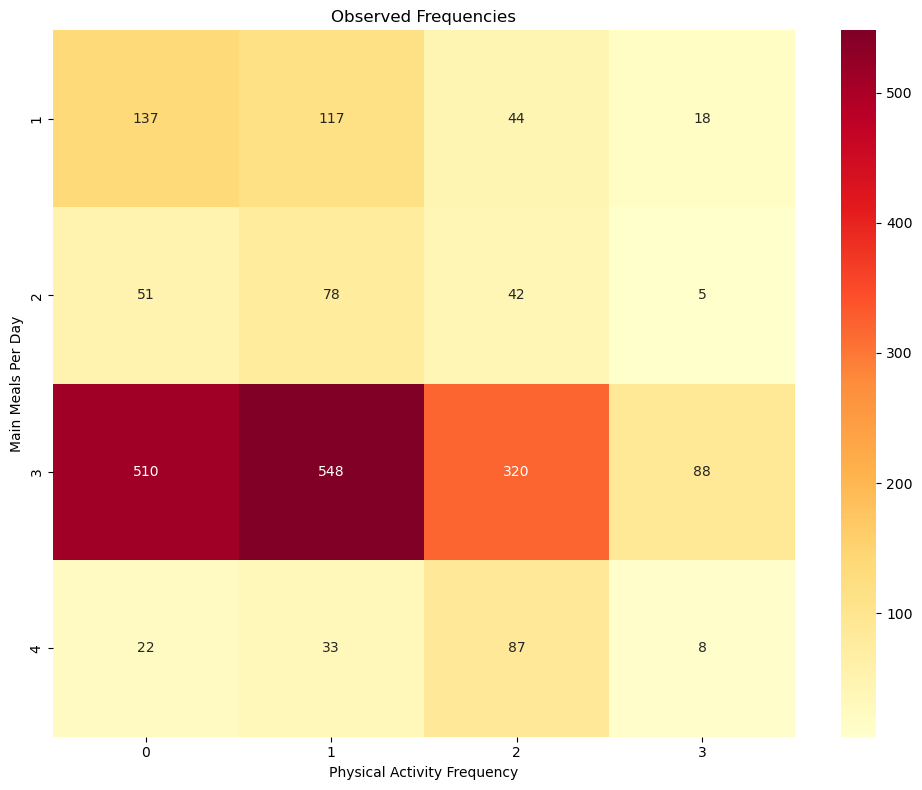

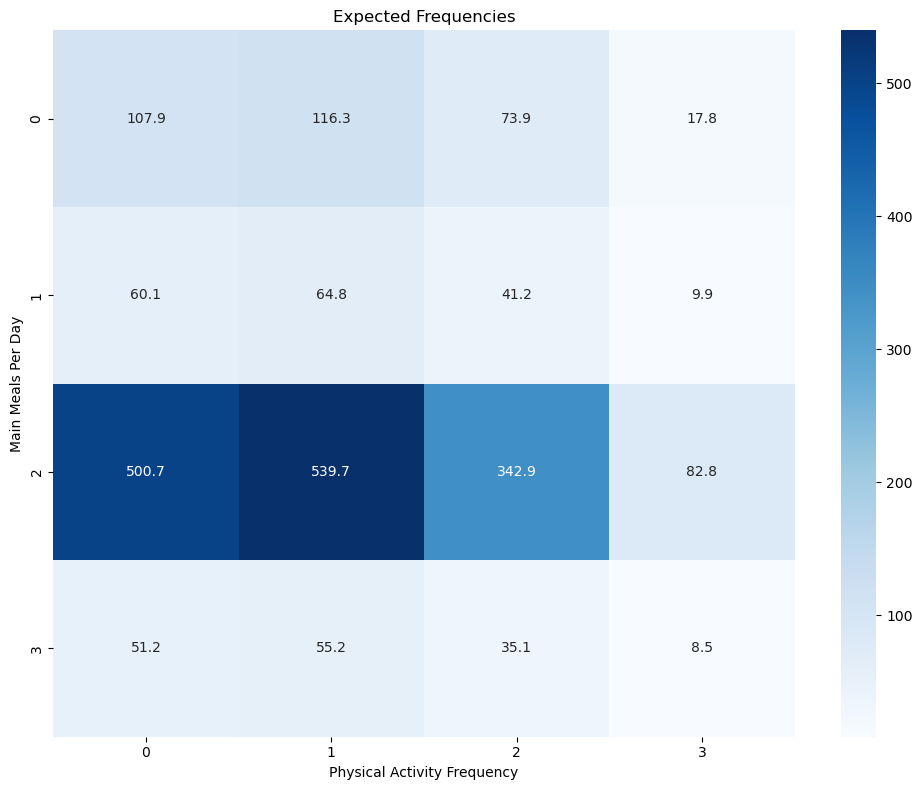

RESULTS: 


Chi-square: 131.1209
p-value: 0.0000
degrees of freedom: 9

 p-value (0.0000) < 0.05: There is a real association between the variables


In [28]:
contingency_table = pd.crosstab(dataset_clean['Main_Meals_Per_Day'], dataset_clean['Physical_Activity_Frequency'])

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# Heatmap of observed frequencies
plt.figure(figsize=(10, 8))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlOrRd')
plt.title("Observed Frequencies")
plt.xlabel("Physical Activity Frequency")
plt.ylabel("Main Meals Per Day")
plt.tight_layout()
plt.show()

# Heatmap of expected frequencies
plt.figure(figsize=(10, 8))
sns.heatmap(expected, annot=True, fmt='.1f', cmap='Blues')
plt.title("Expected Frequencies")
plt.xlabel("Physical Activity Frequency")
plt.ylabel("Main Meals Per Day")
plt.tight_layout()
plt.show()

print(f"RESULTS: \n\n")
print(f"Chi-square: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"degrees of freedom: {dof}")

alpha = 0.05
if p_value < alpha:
    print(f"\n p-value ({p_value:.4f}) < {alpha}: There is a real association between the variables")
else:
    print(f"\n p-value ({p_value:.4f}) >= {alpha}: There is no evidence of significant association")

The results obtained show that there is a statistical dependence between the number of daily meals and the frequency of physical activity. 
<br><br><br>

Now let's proceed to calculate Cramer's V to evaluate the relationship between these two variables:

In [29]:
n = dataset_clean.shape[0] # Tot number of observations
min_dim = min(contingency_table.shape) - 1
v_cramer = np.sqrt(chi2 / (n * min_dim))
print(f"V of Cramer: {v_cramer:.4f}")

V of Cramer: 0.1440


This reveals that, although the variables are not strictly independent, the association between the number of meals and the frequency of physical activity is extremely weak. 

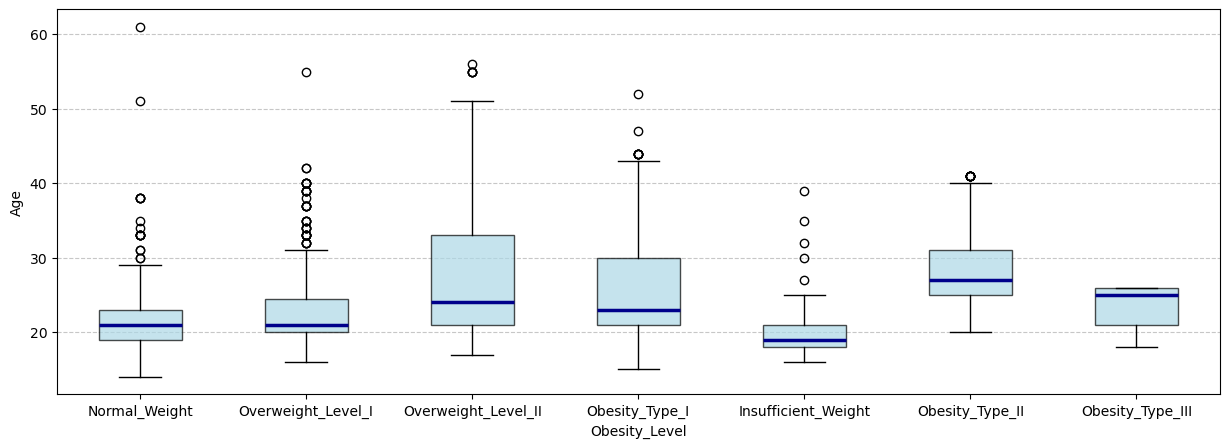

In [30]:
# Comparison of a numerical variable with a categorical variable
# (Example: age distribution for each level of obesity)
target = "Obesity_Level"  # name of the target variable

if target in dataset_clean.columns:
    first_numvar = num_vars[0]  # first numerical variable
    categories = dataset_clean[target].unique()
    plt.figure(figsize=(15,5))
    data_to_plot = [dataset_clean[dataset_clean[target] == cat][first_numvar] for cat in categories]
    plt.boxplot(data_to_plot, tick_labels=categories, patch_artist=True, boxprops=dict(facecolor='lightblue', alpha = 0.7), medianprops=dict(color='darkblue', linewidth=2.5)) 
    plt.xlabel(target)
    plt.ylabel(first_numvar)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

Now we use contingency tables on categorical variables to count how many times the values of two categories appear together.
We calculate two tables for each pair, one for the absolute frequencies and one normalized per row. <br>
The latter has the task of transforming the counts into conditional probabilities, that is, how much of a percentage one category is distributed over the other.<br>
This way, the value present in the heatmap cell is evaluated, which varies between 0 and 1, indicating how strong the association is between the two variables.

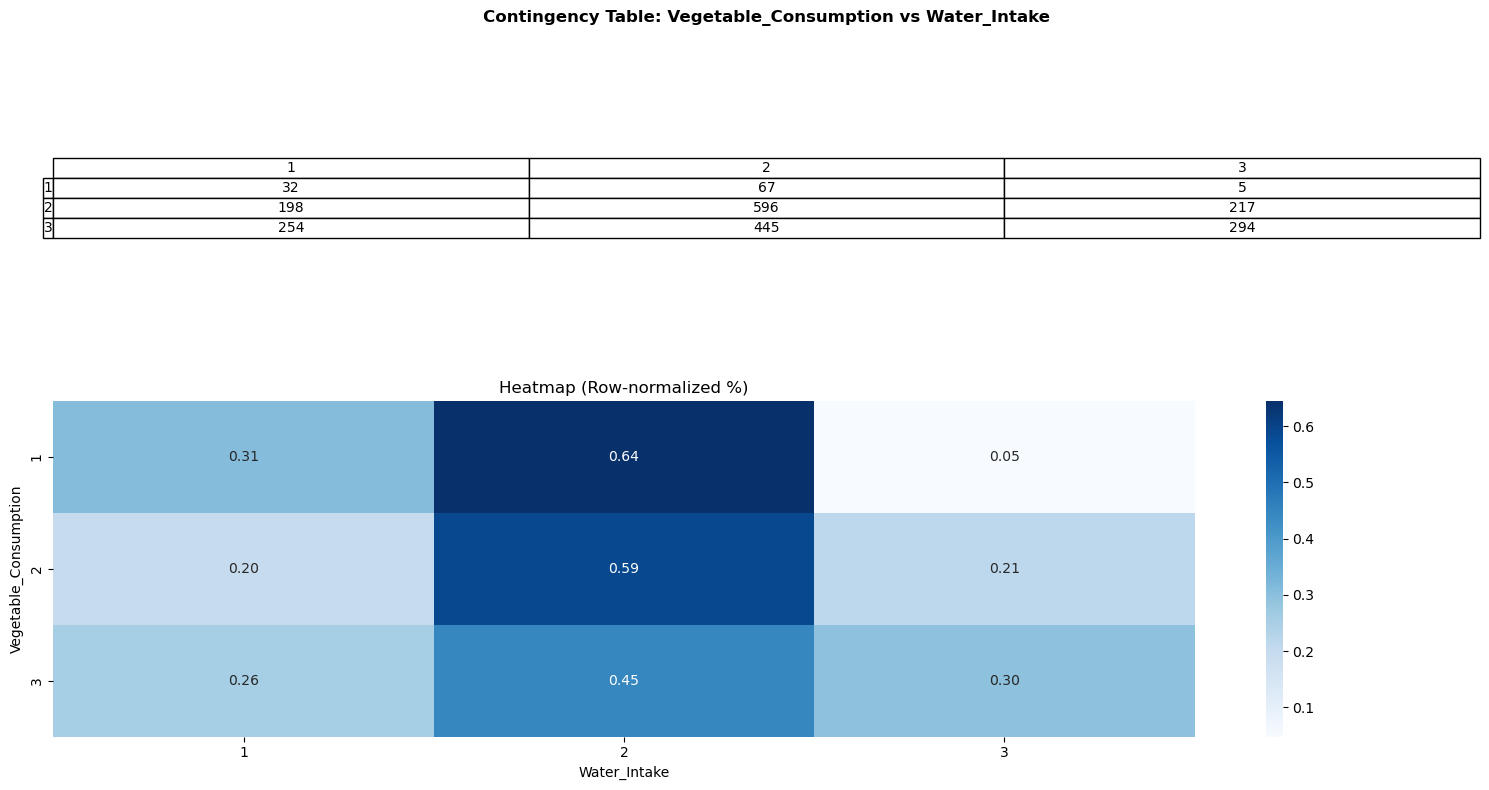

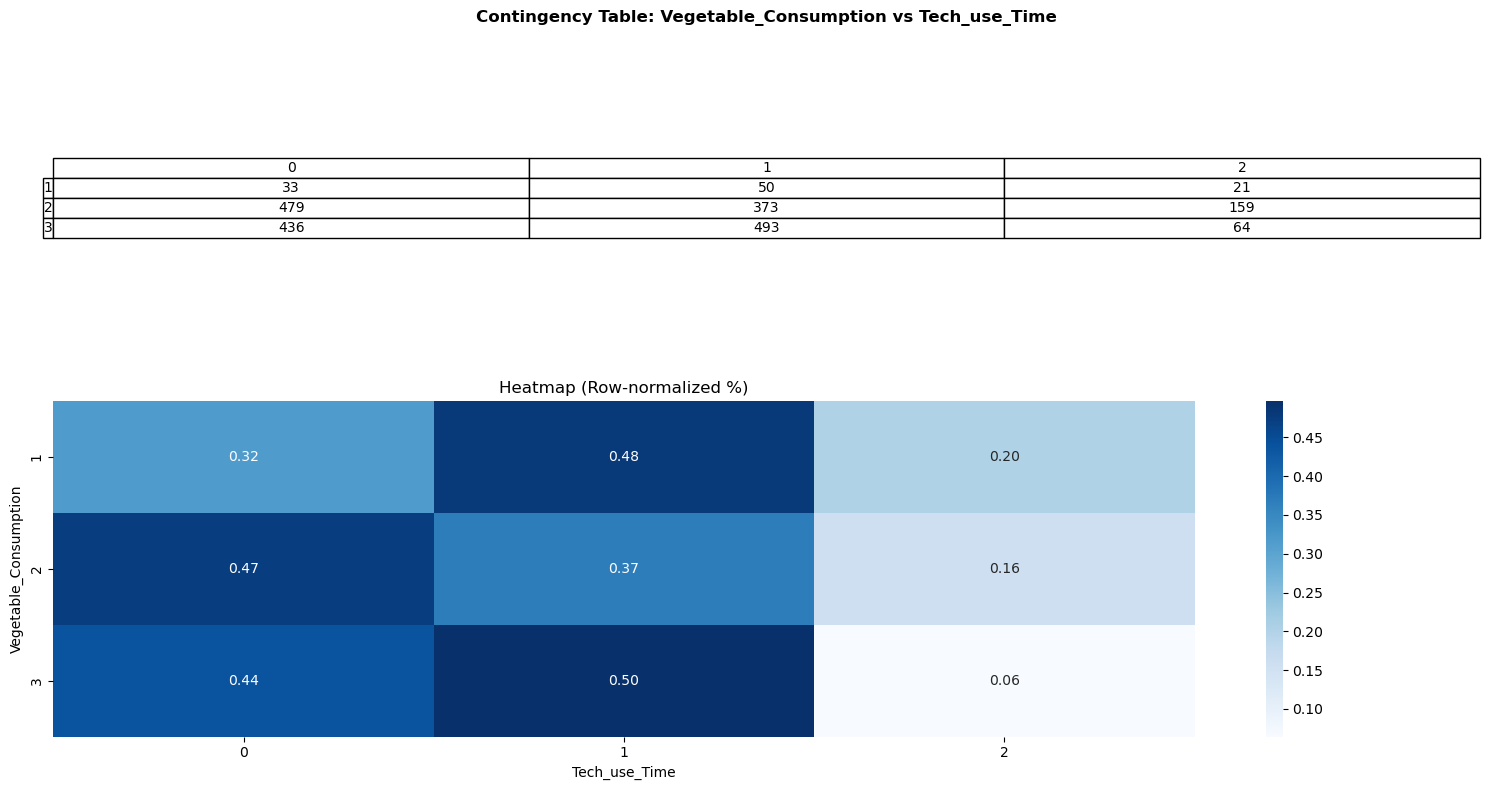

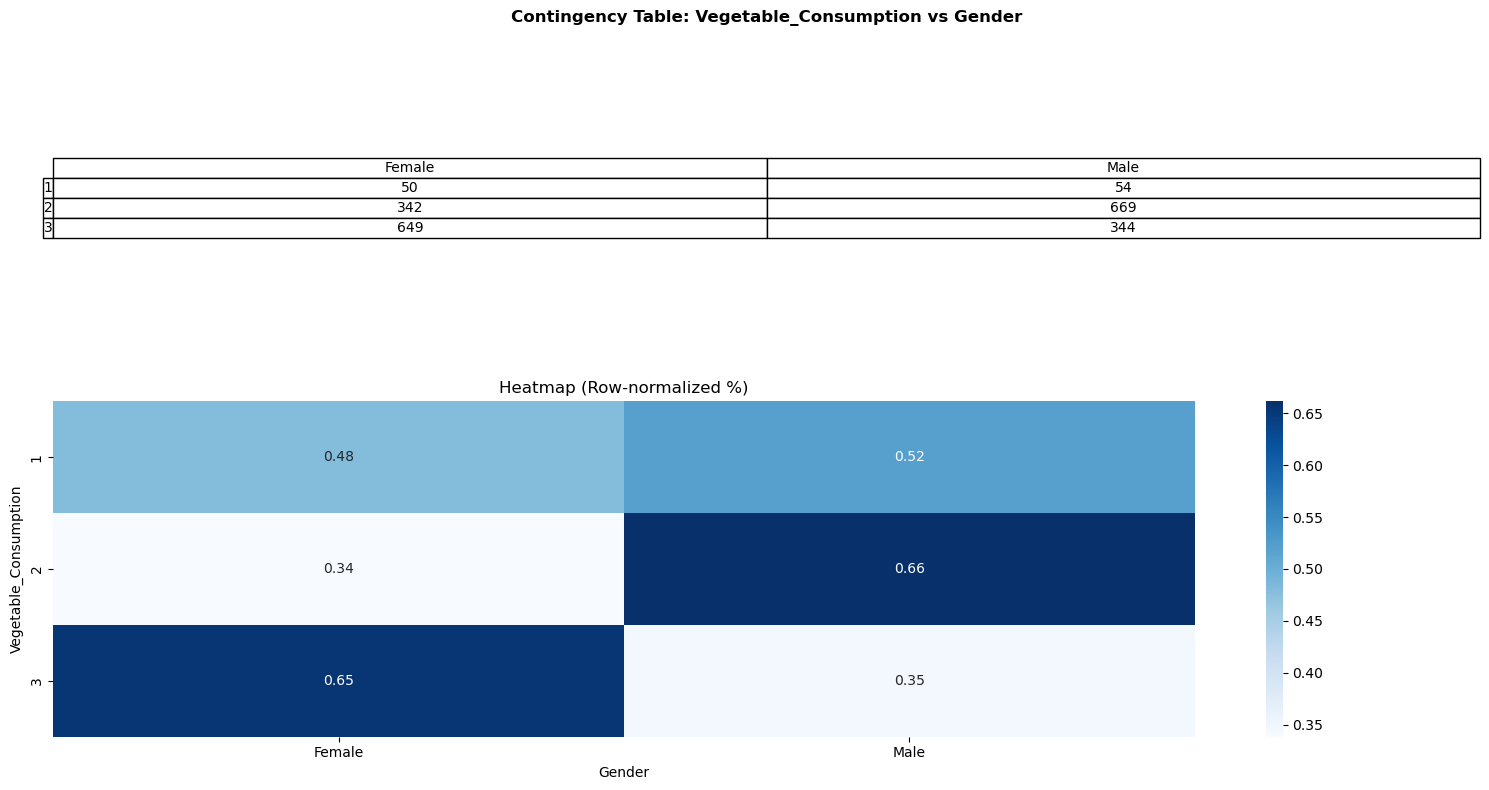

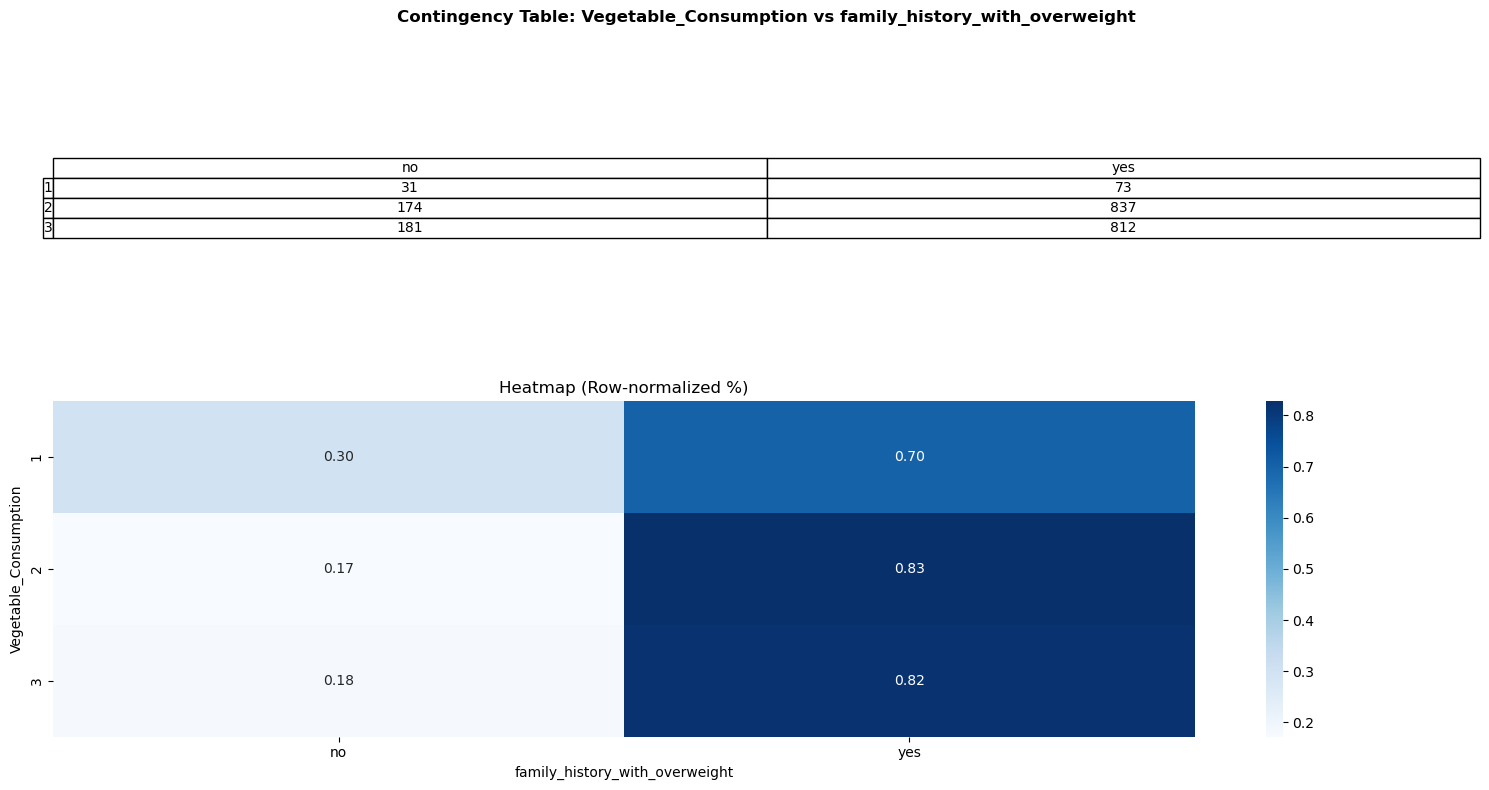

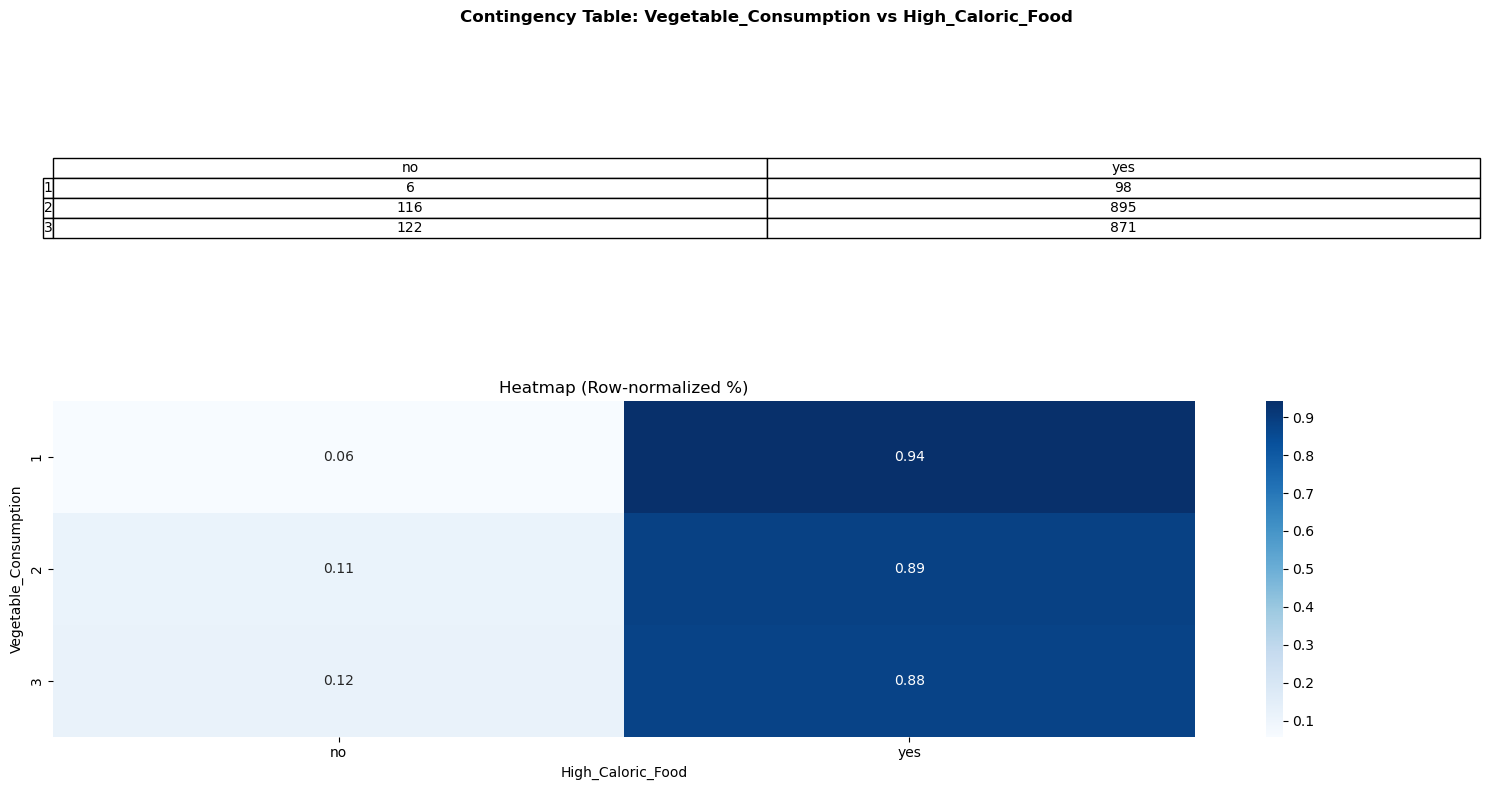

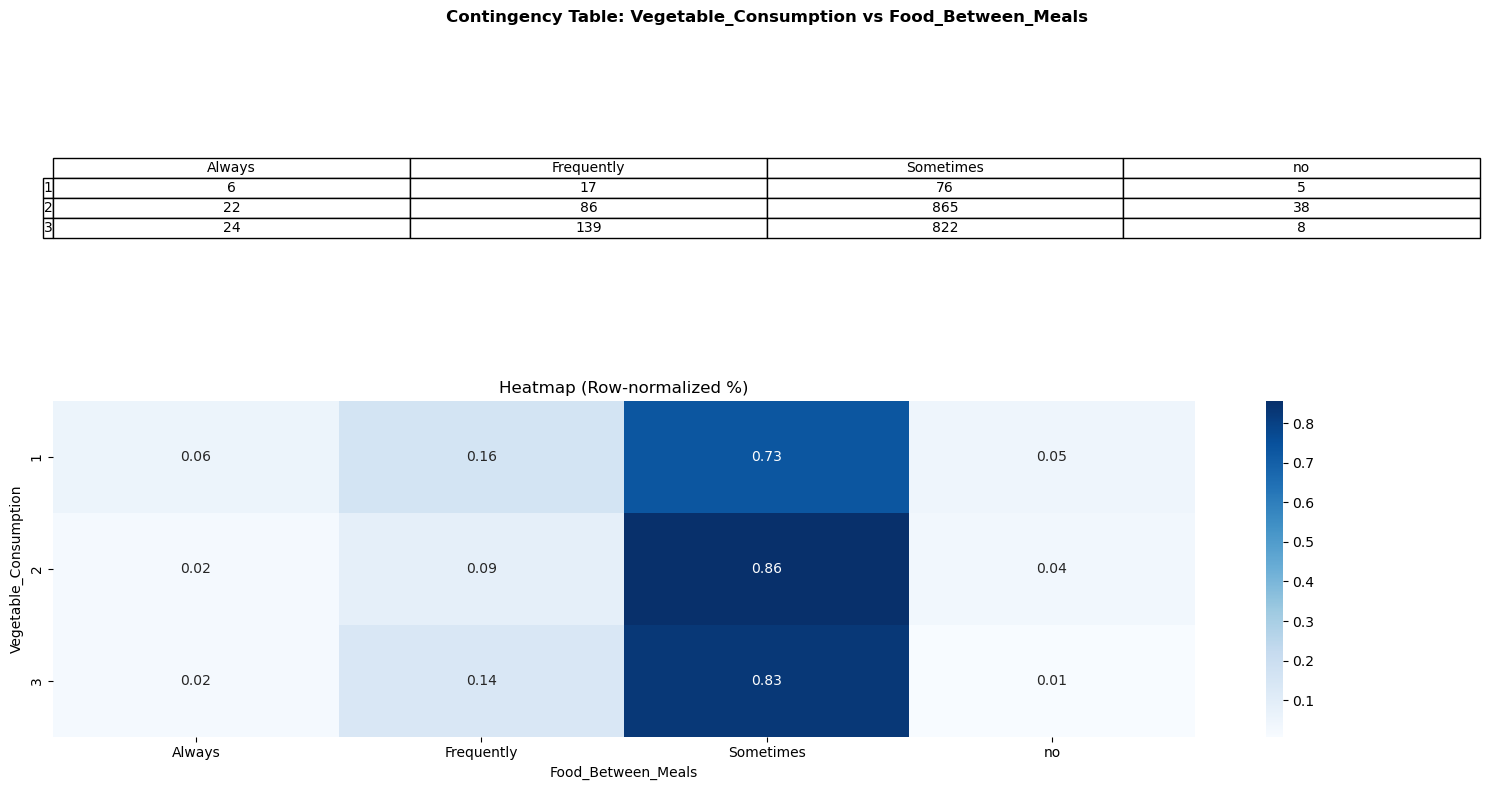

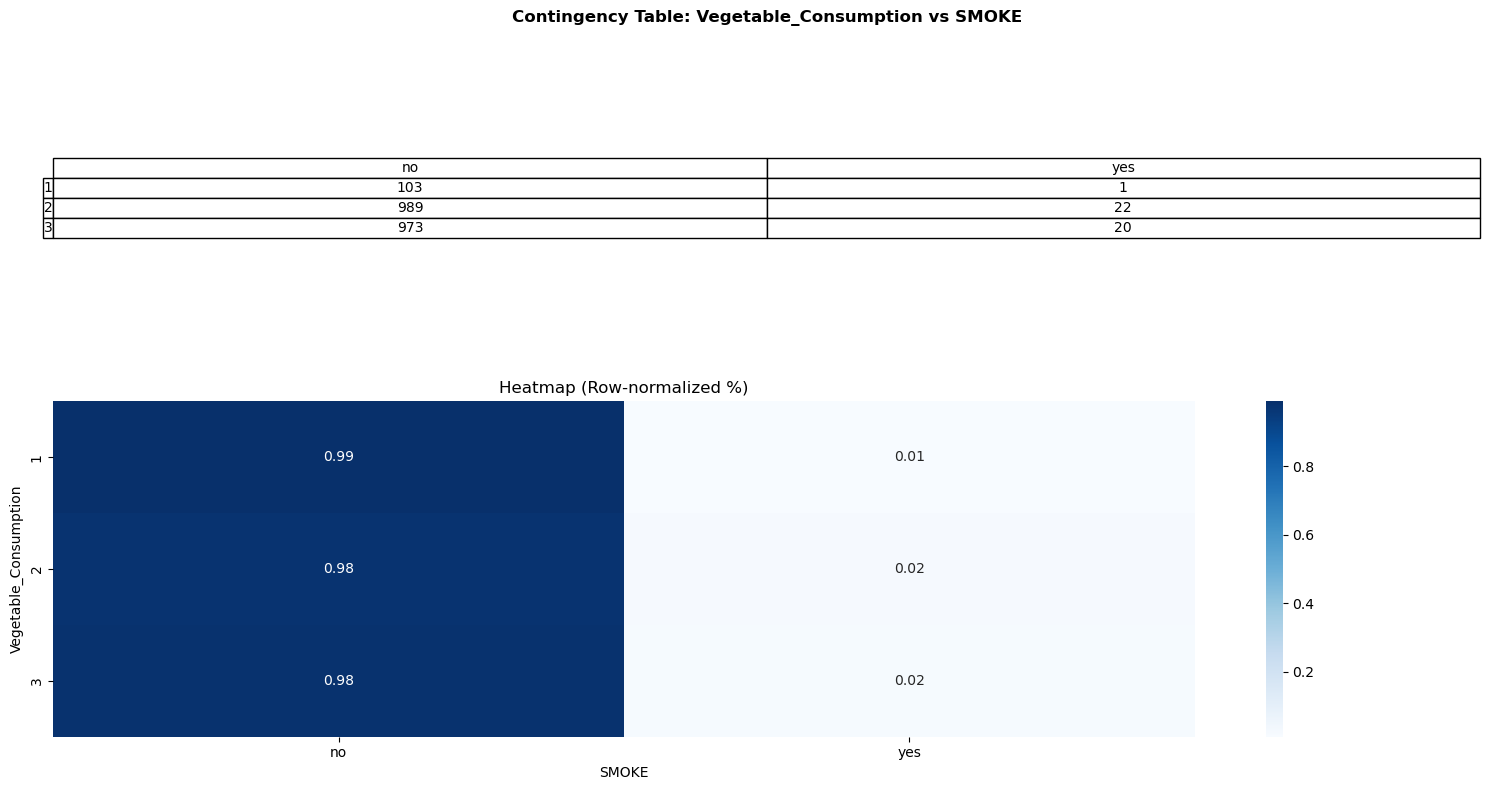

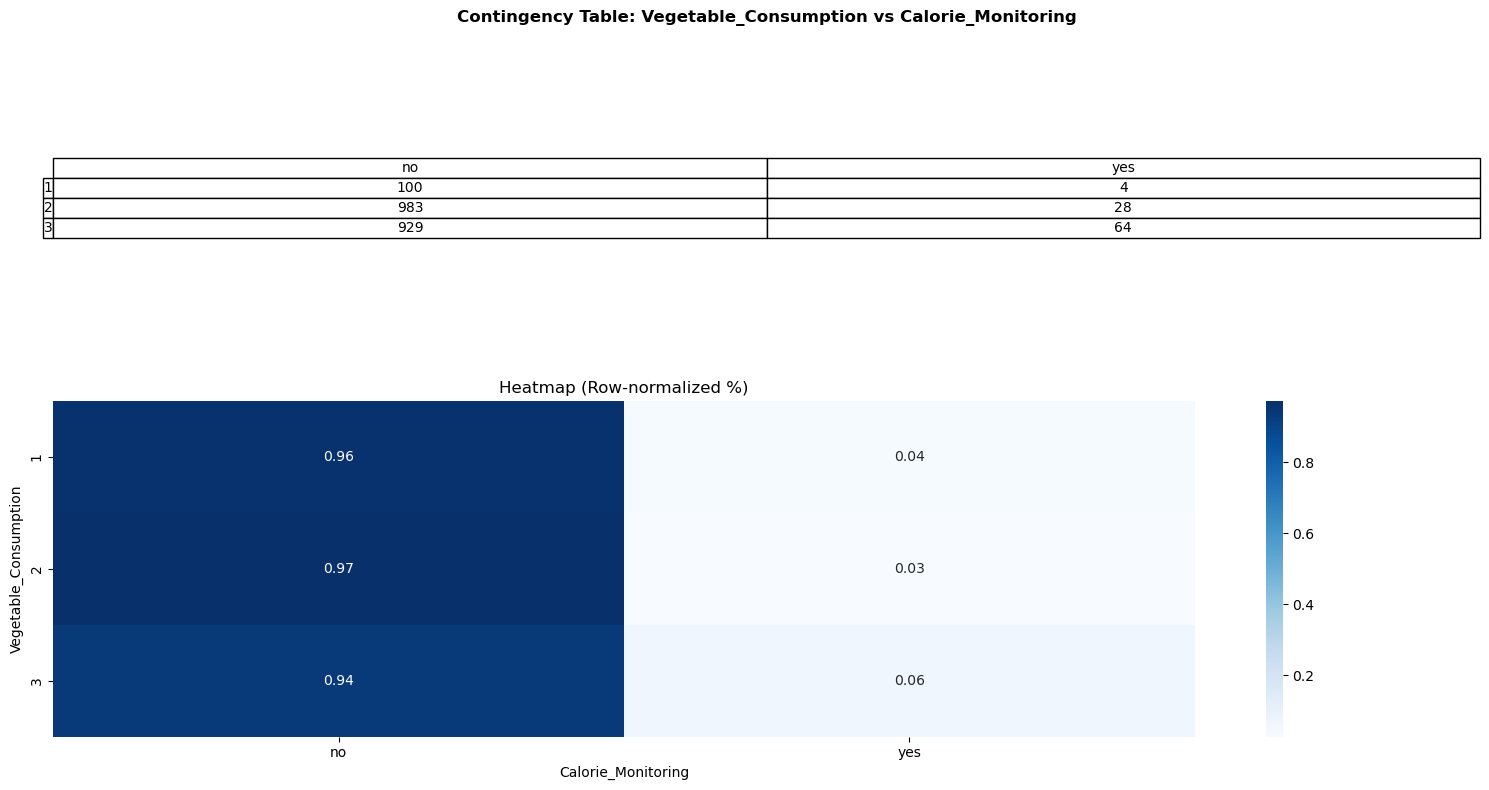

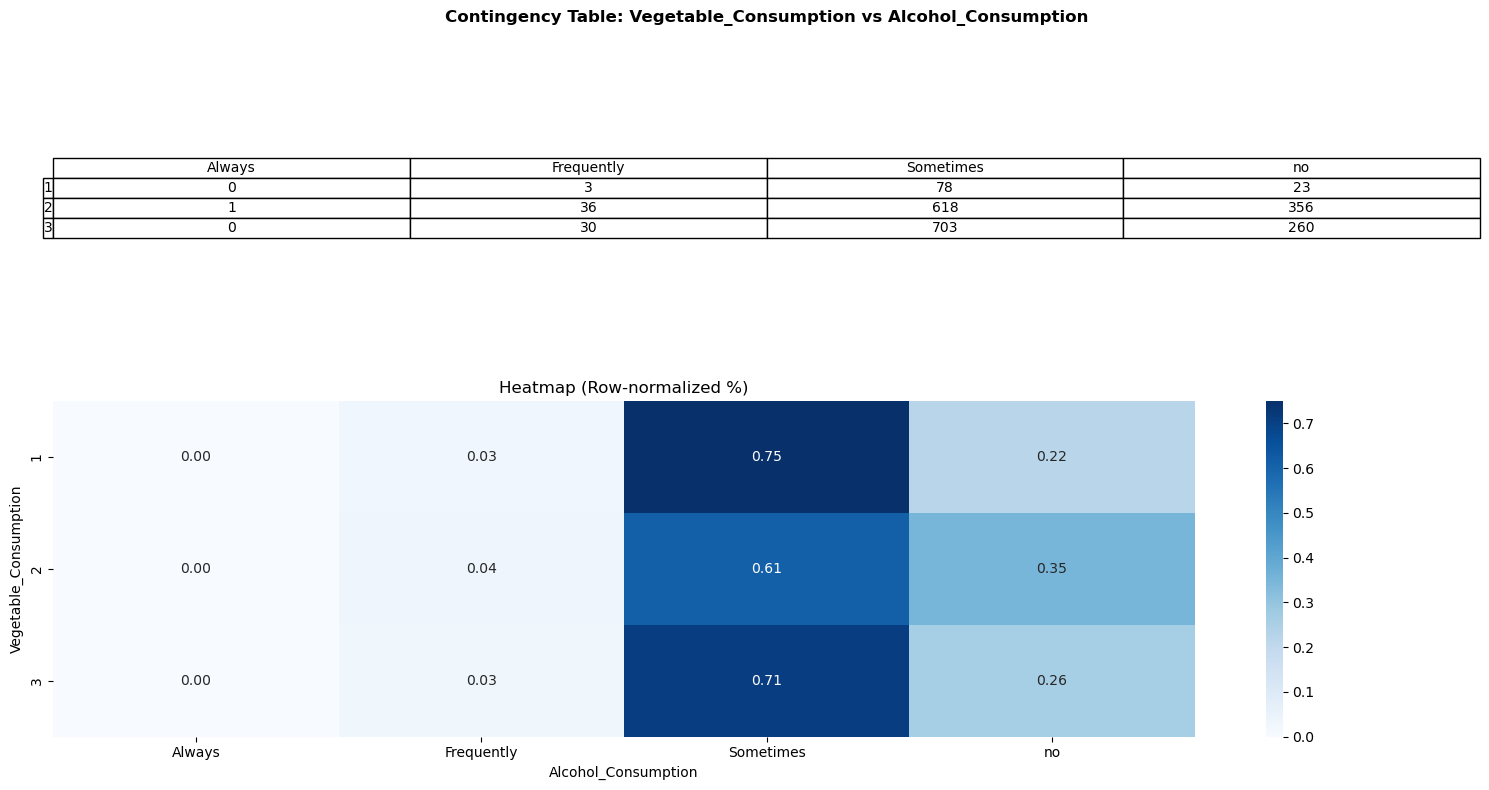

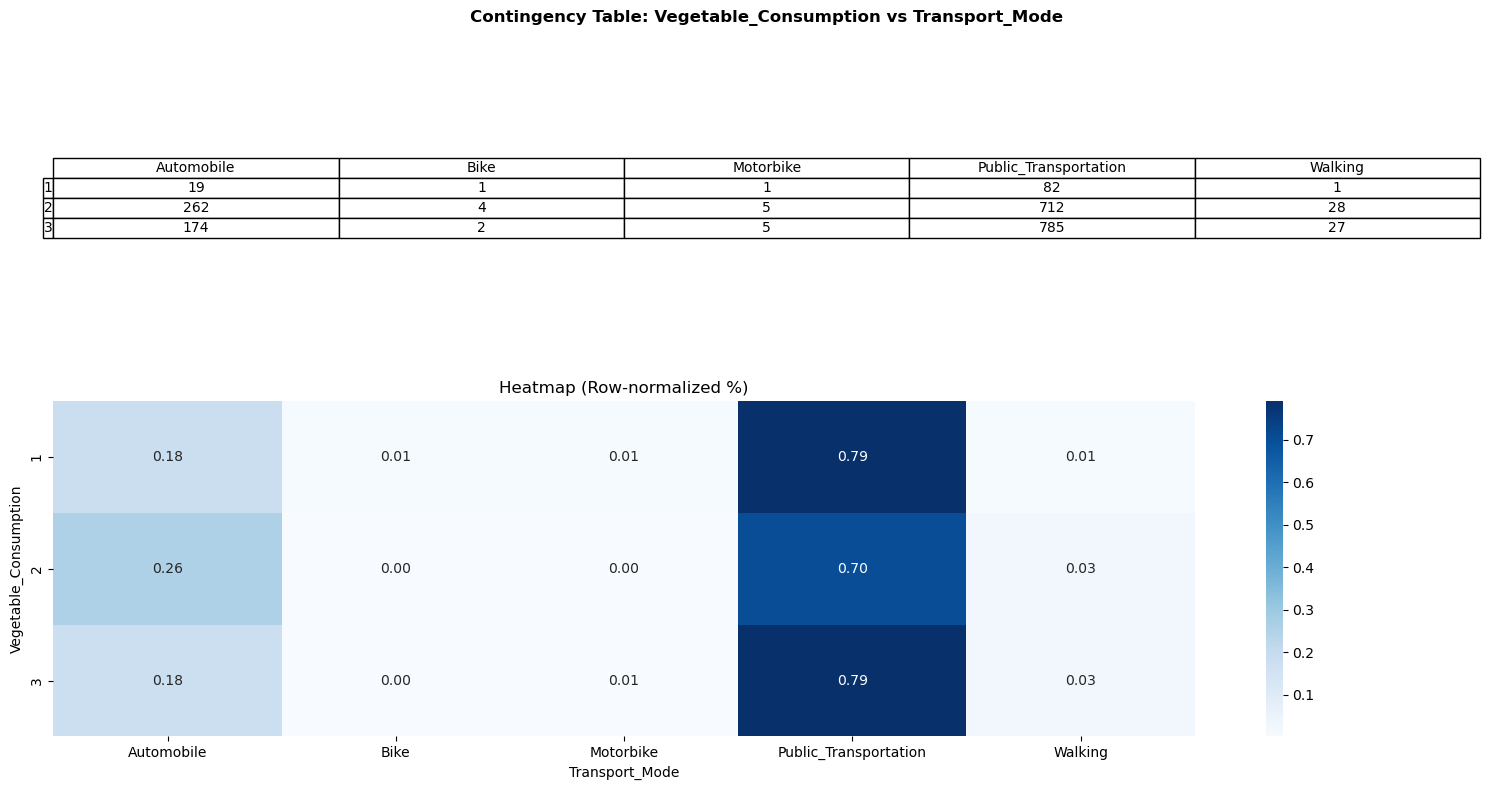

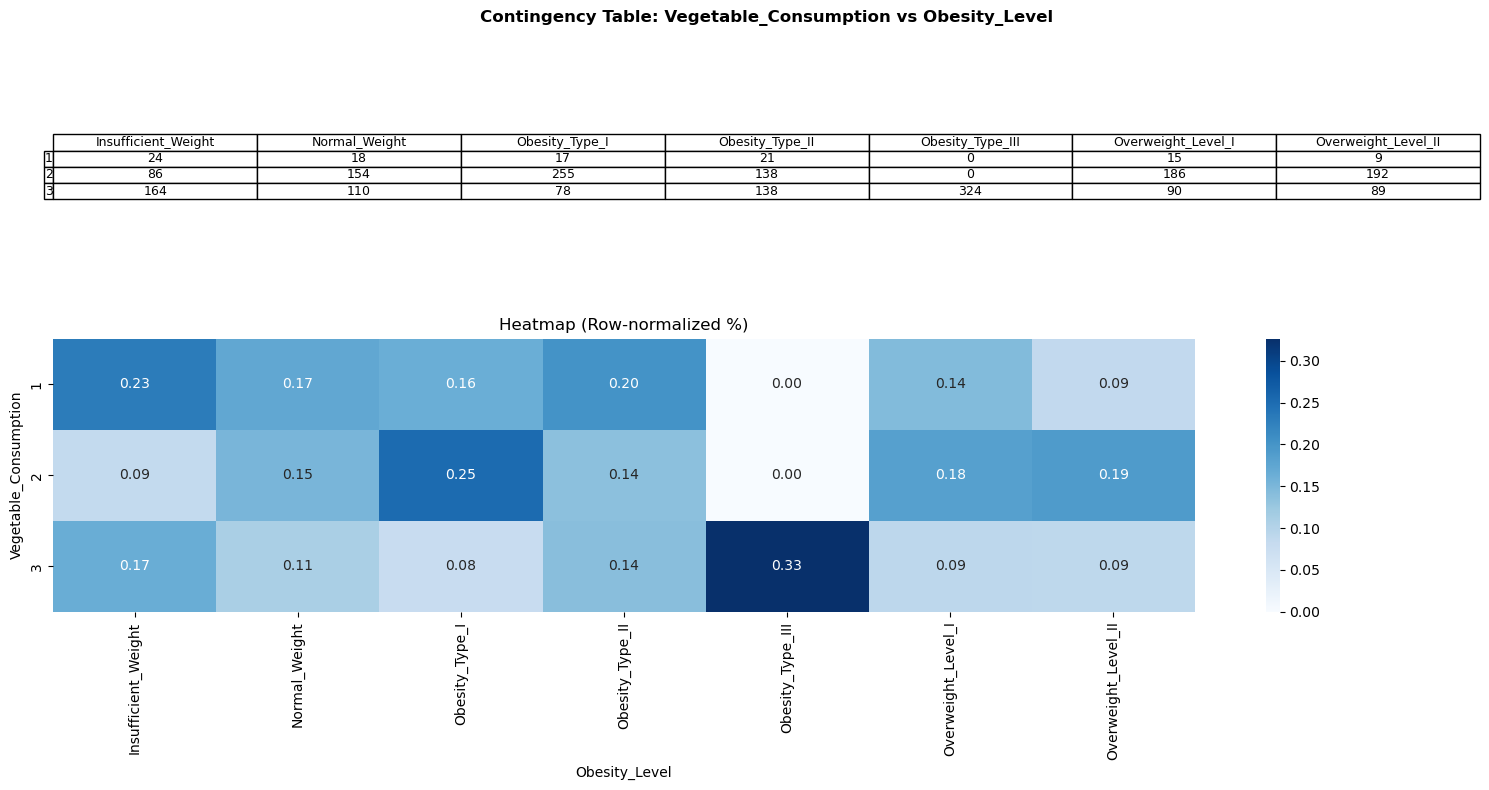

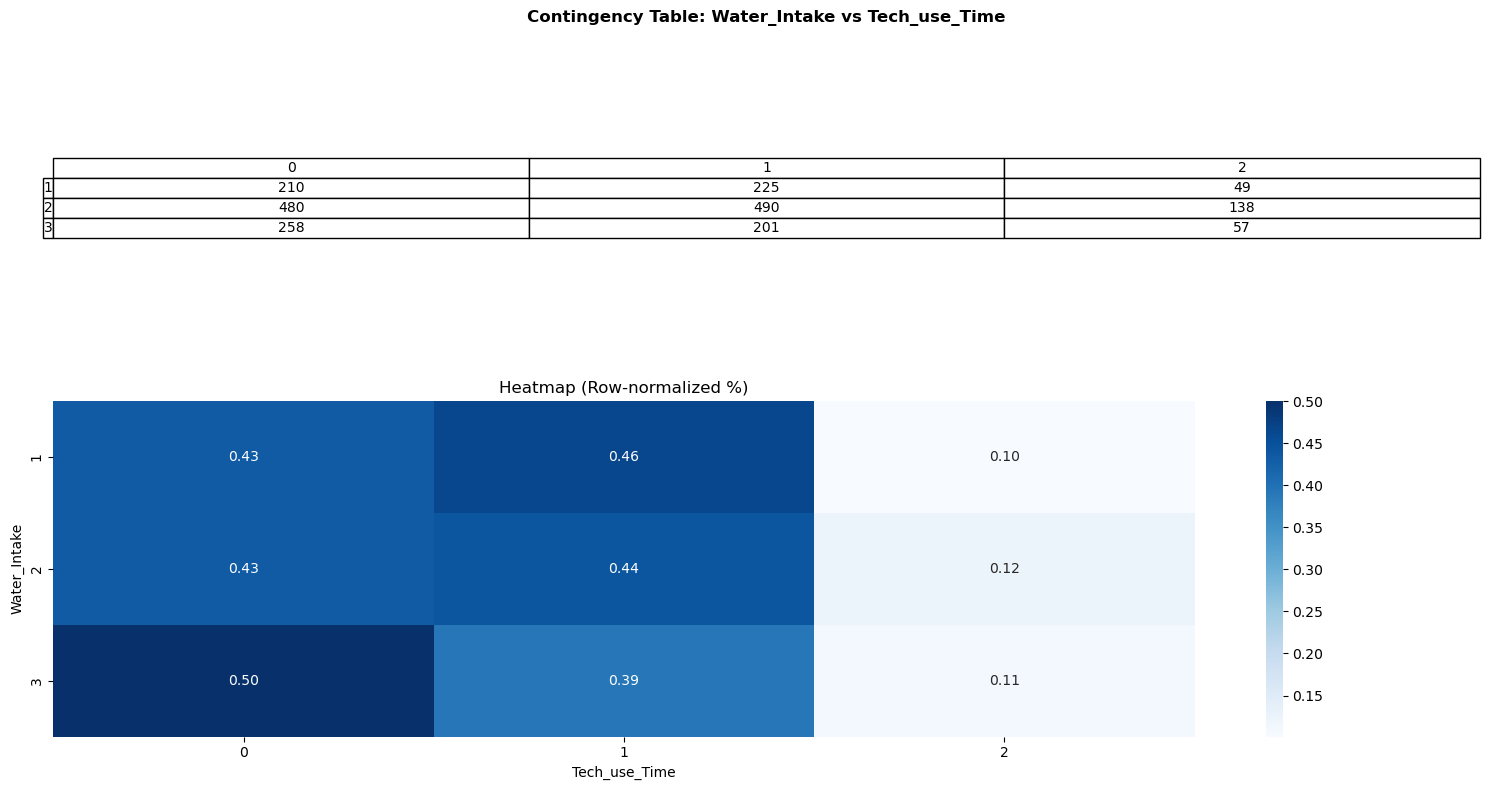

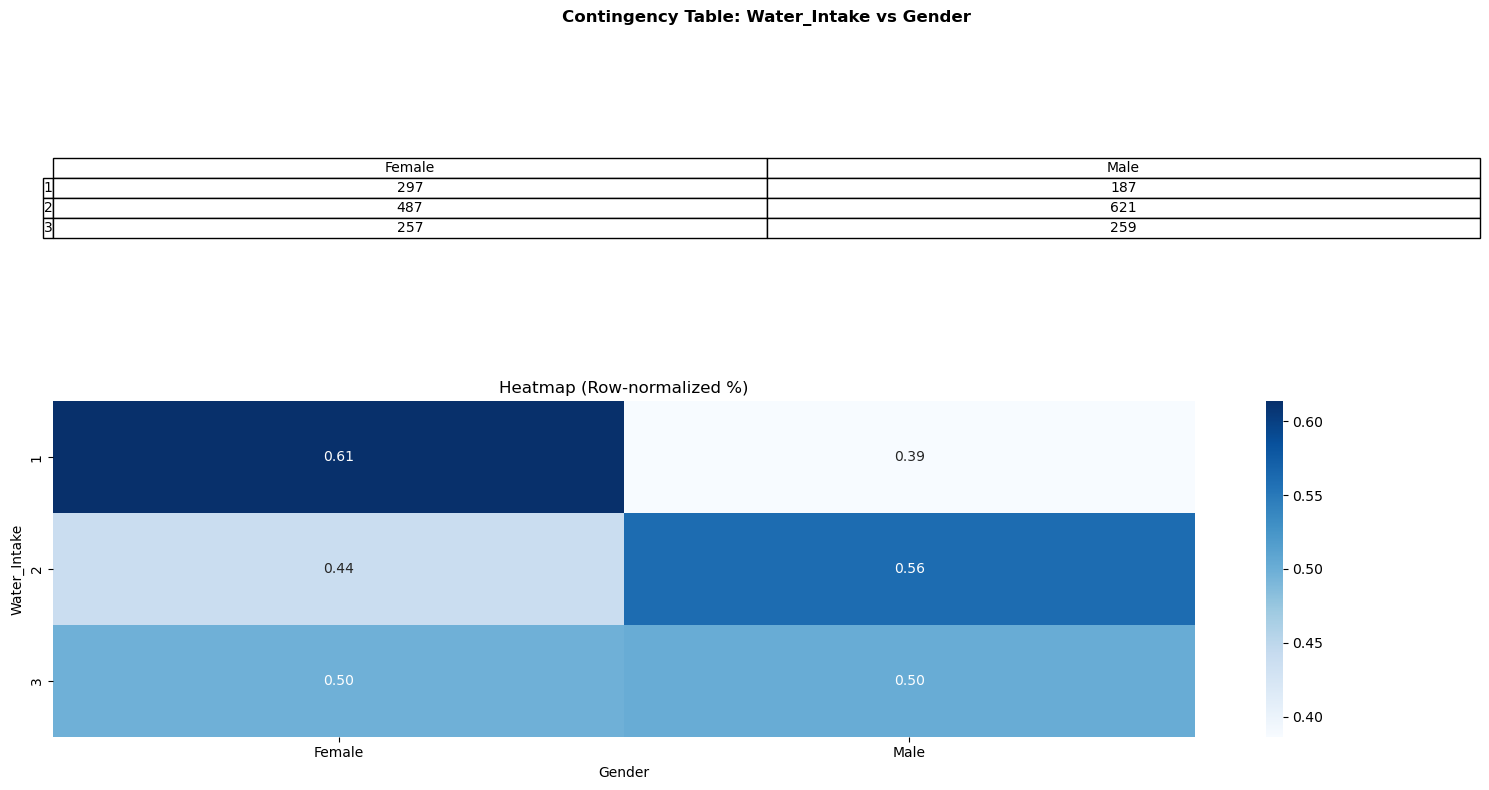

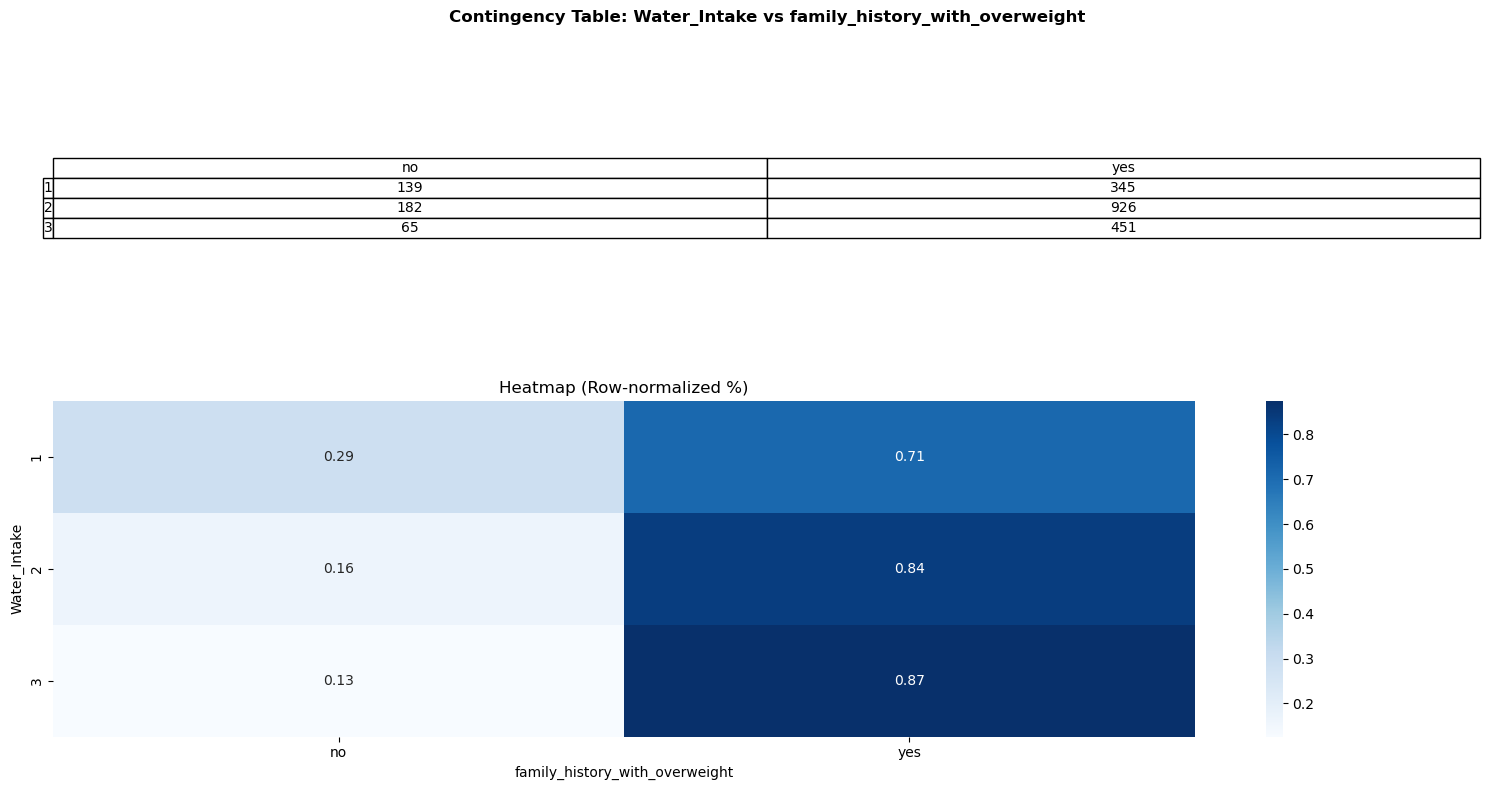

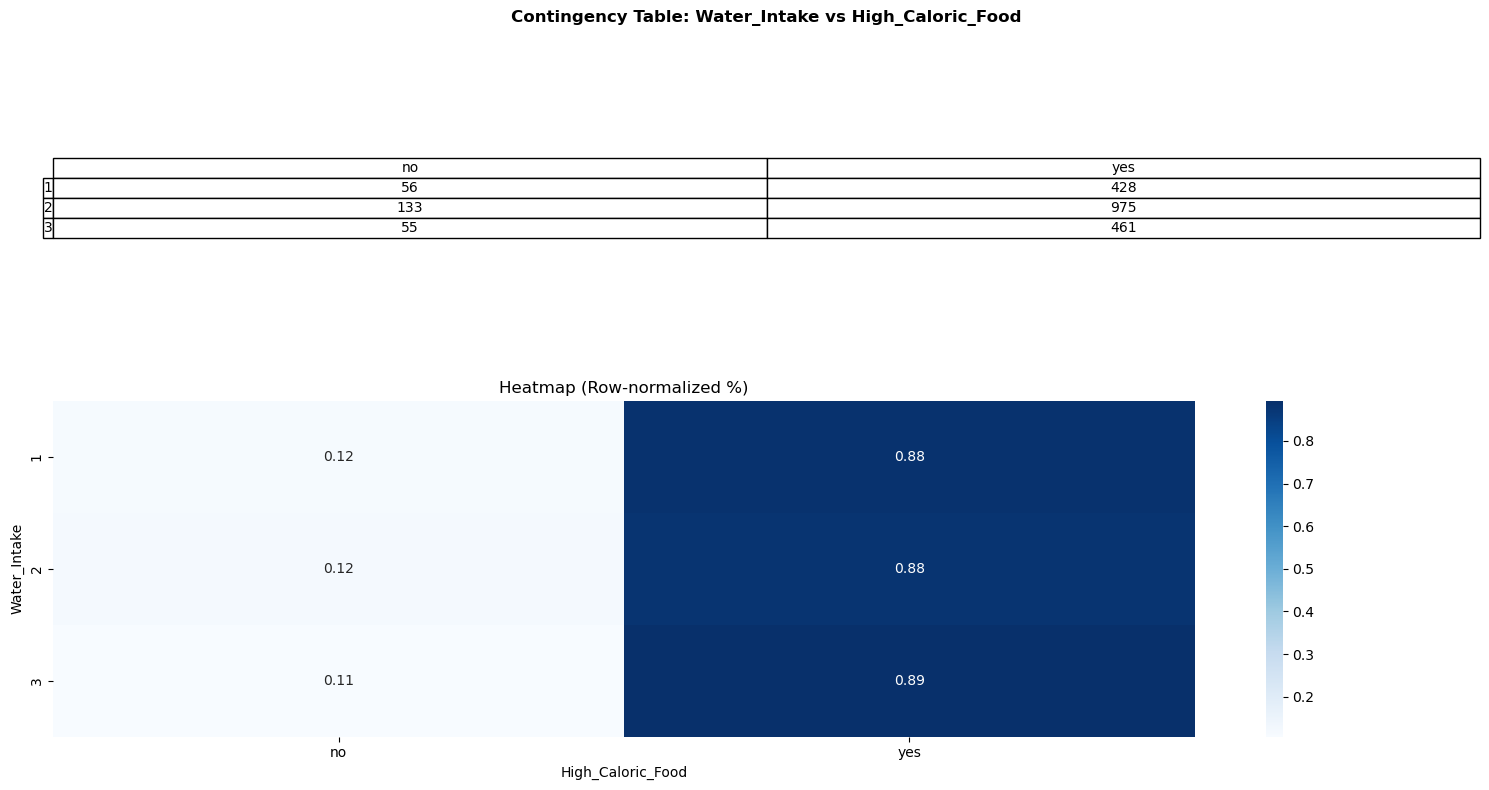

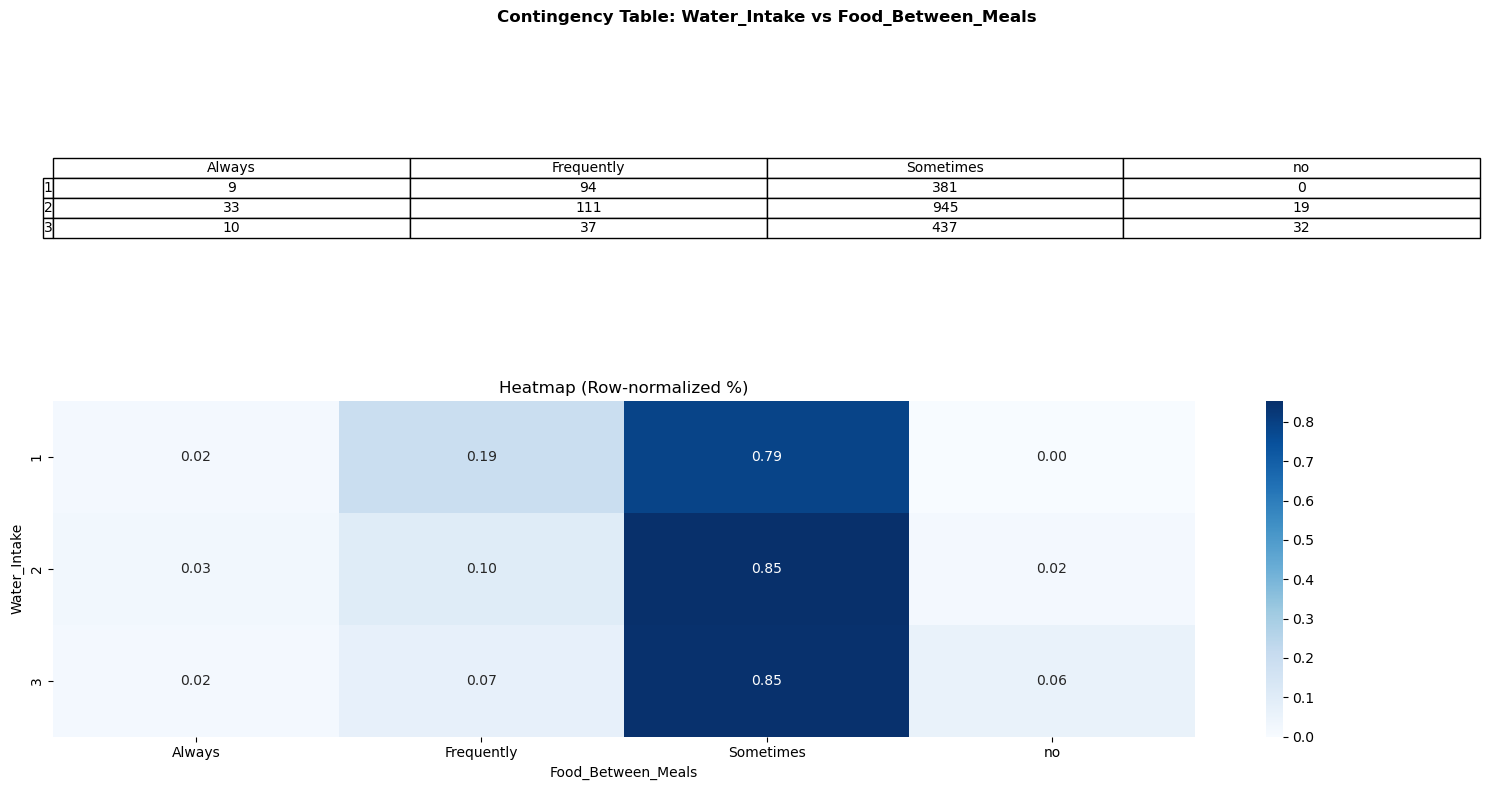

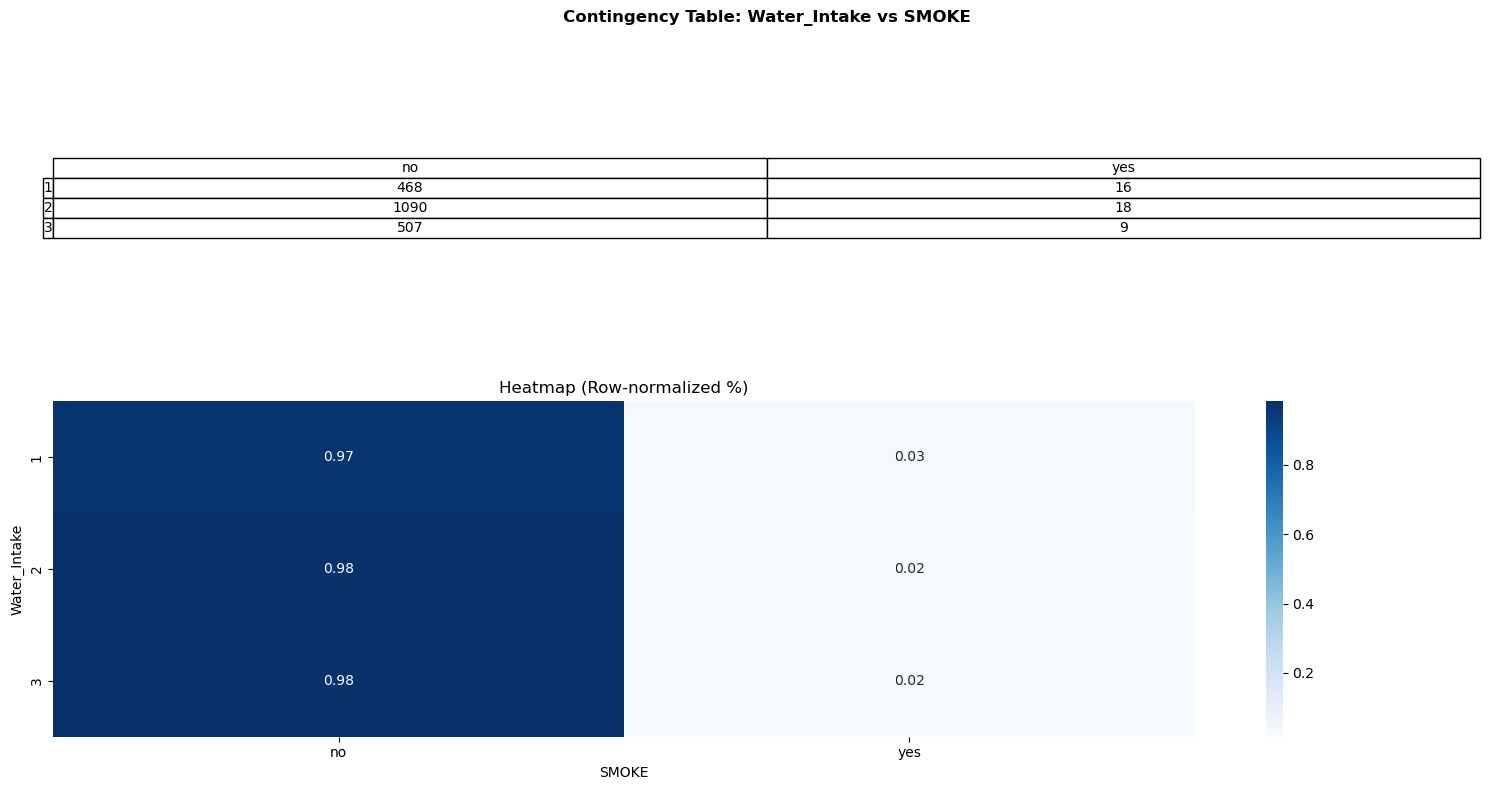

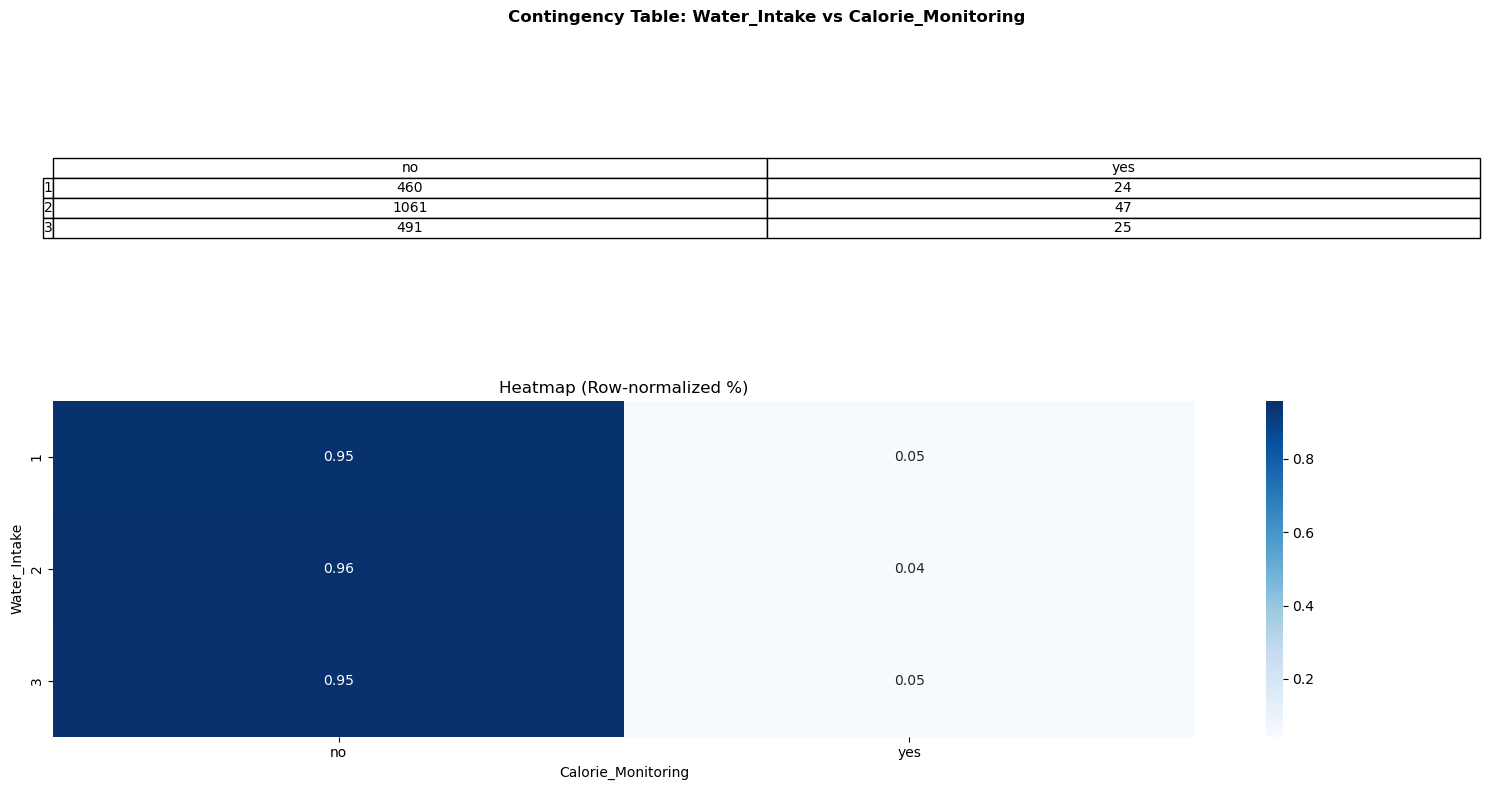

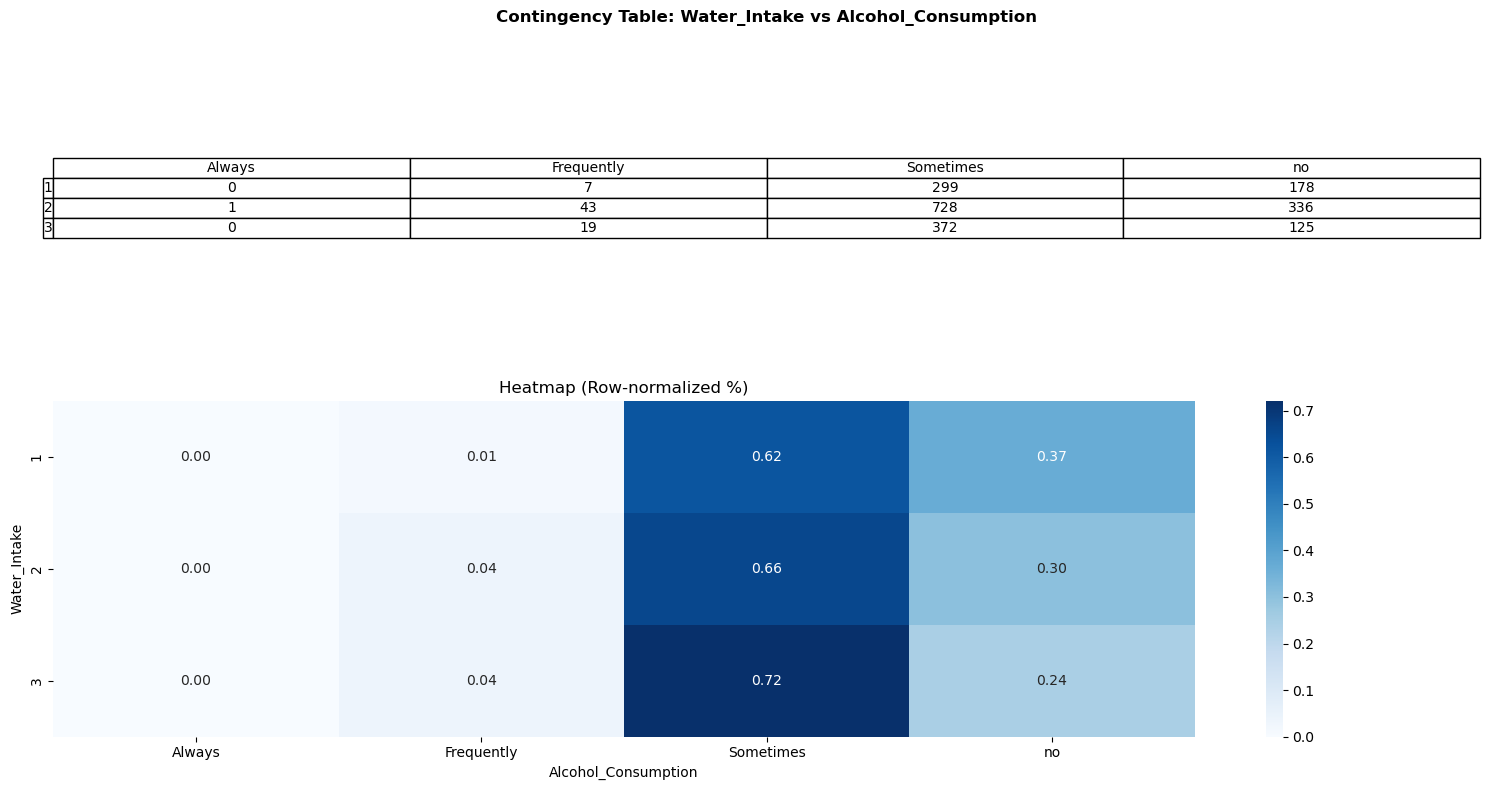

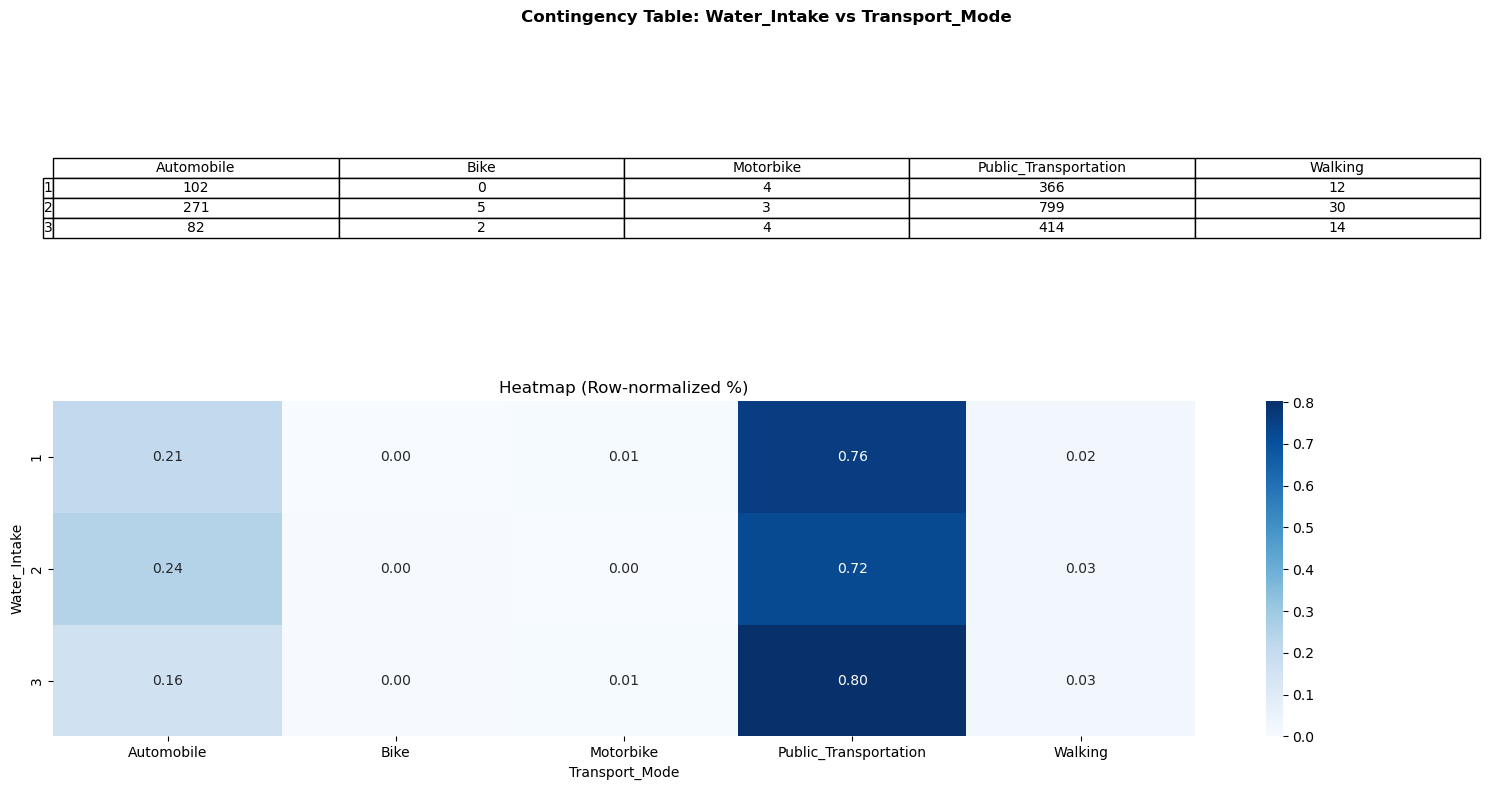

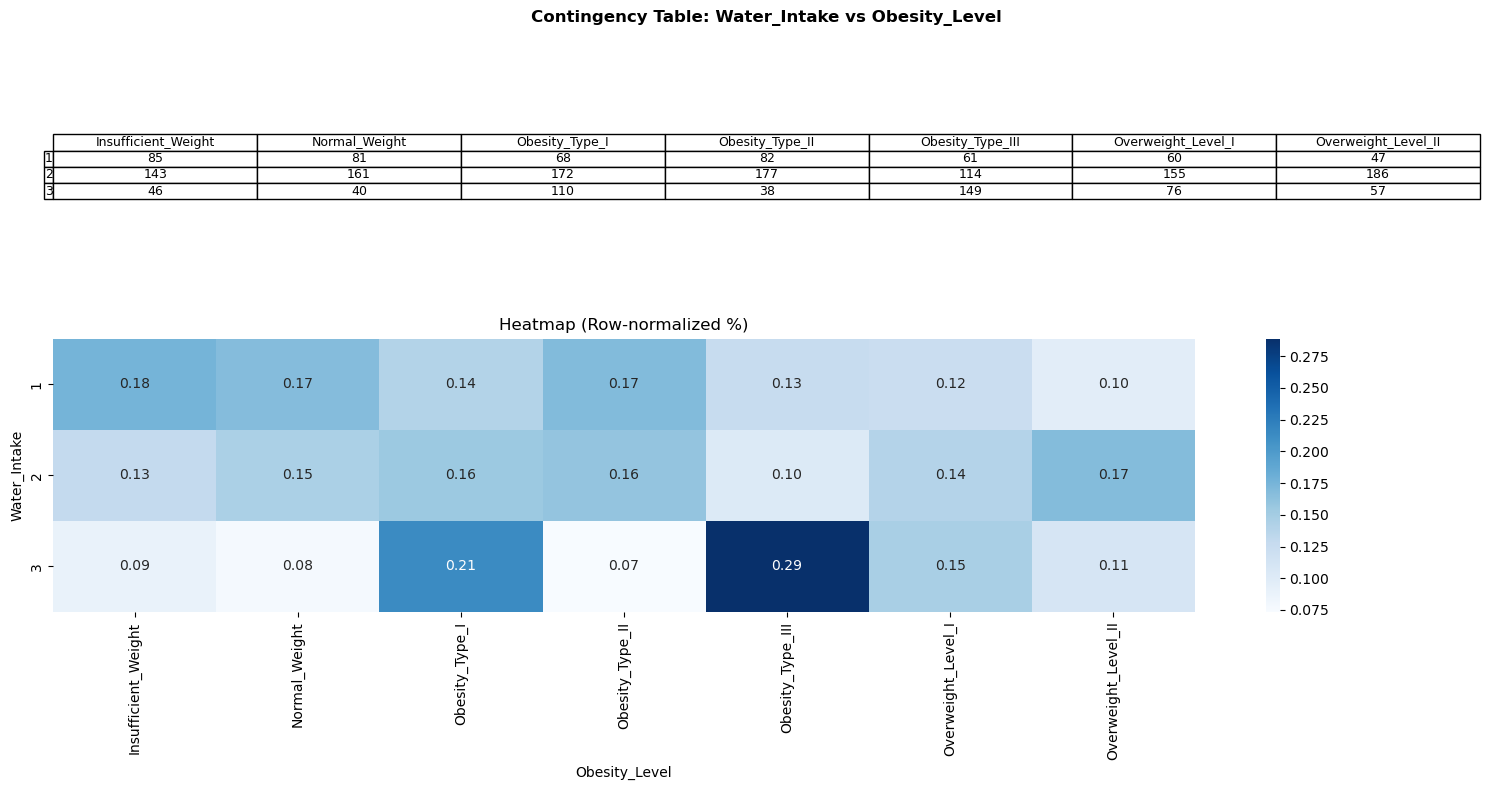

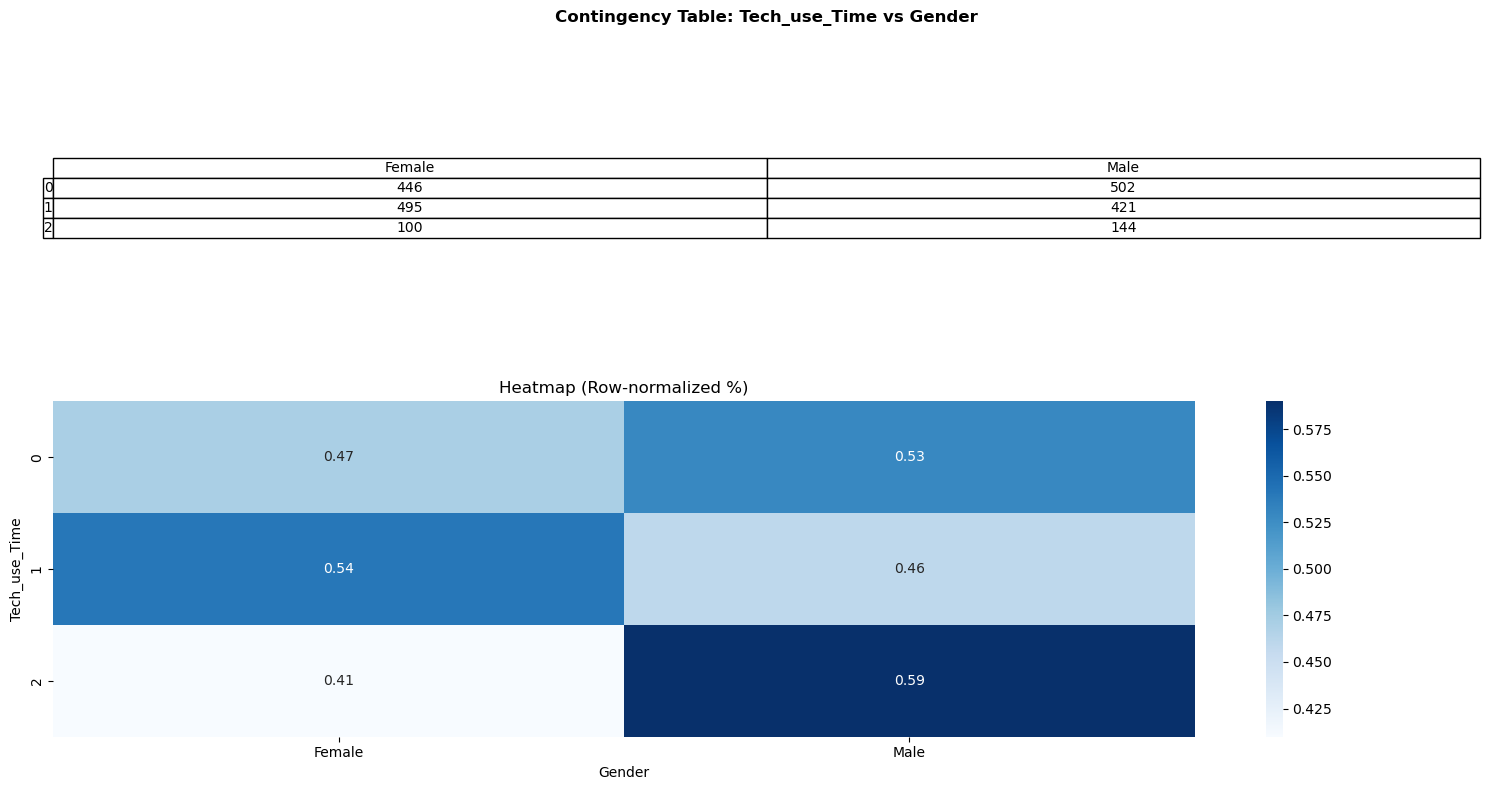

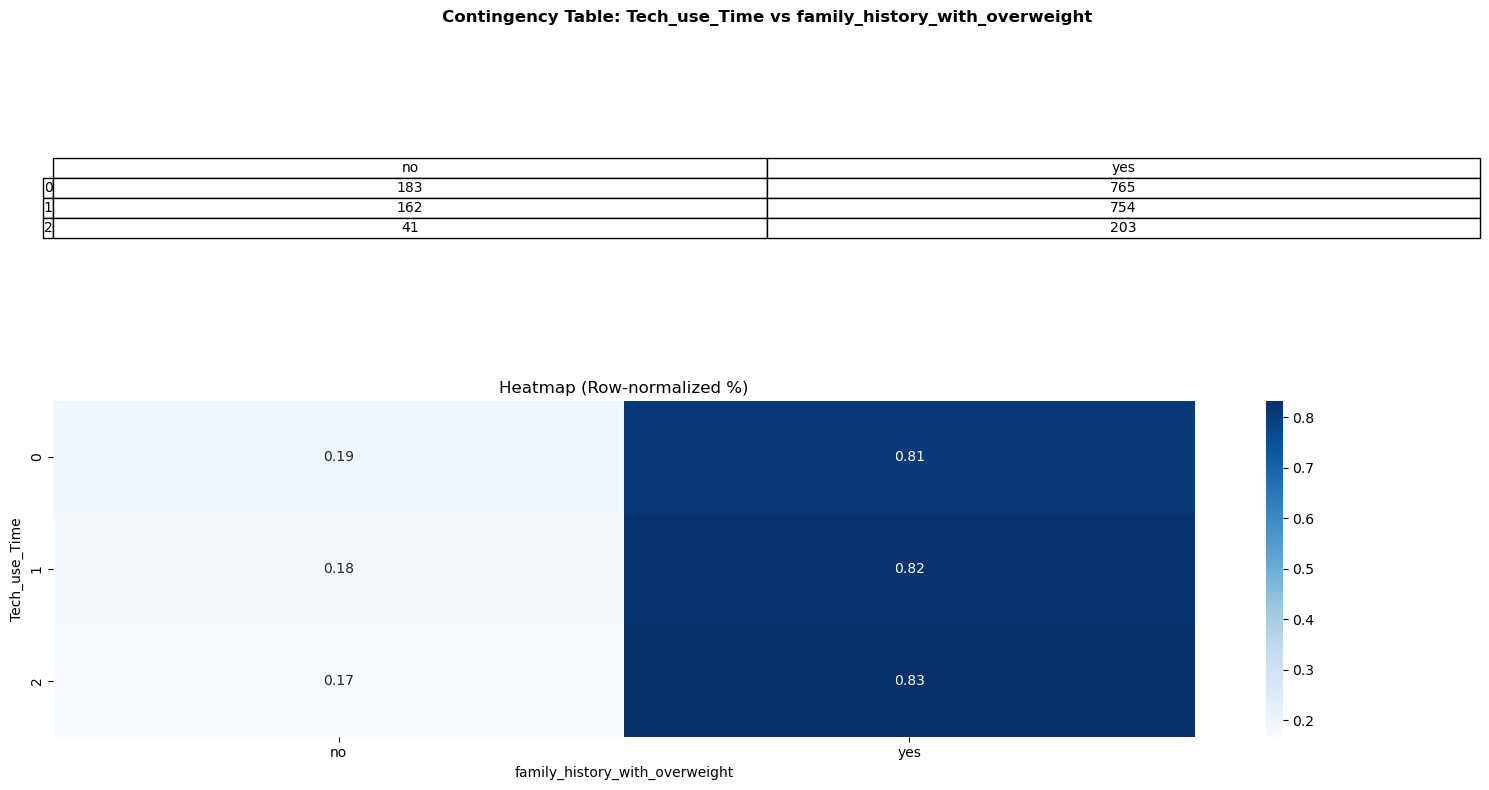

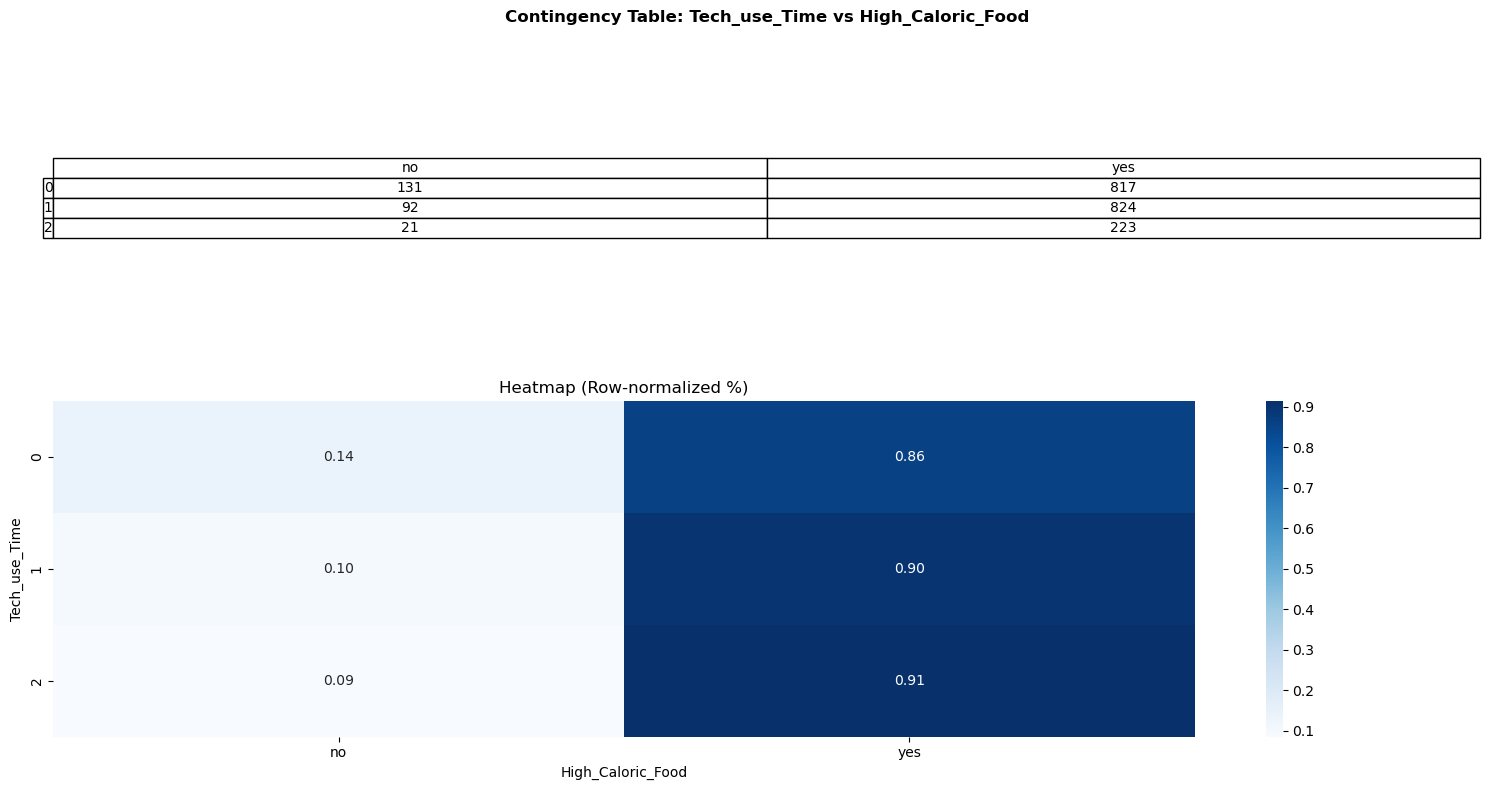

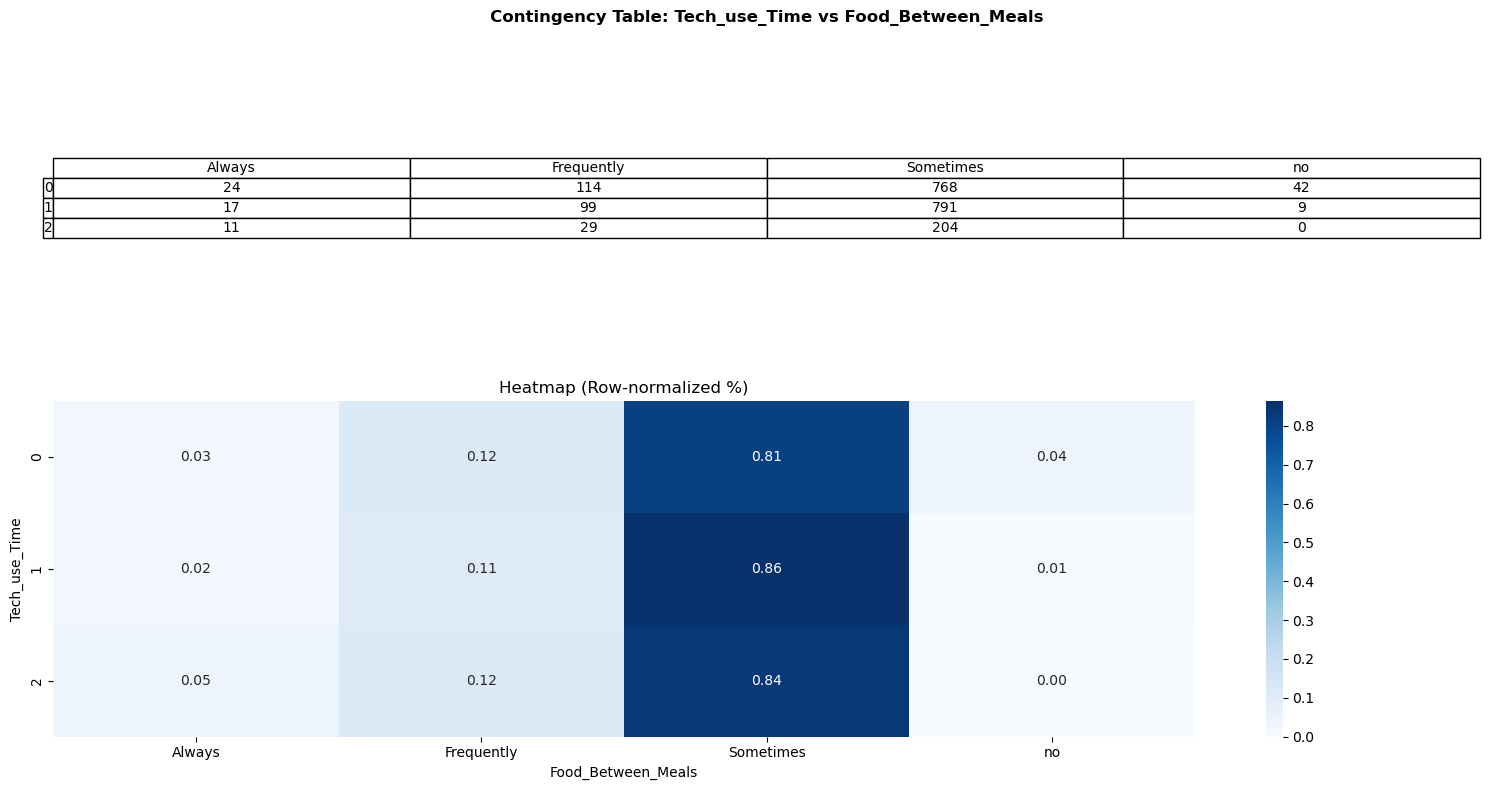

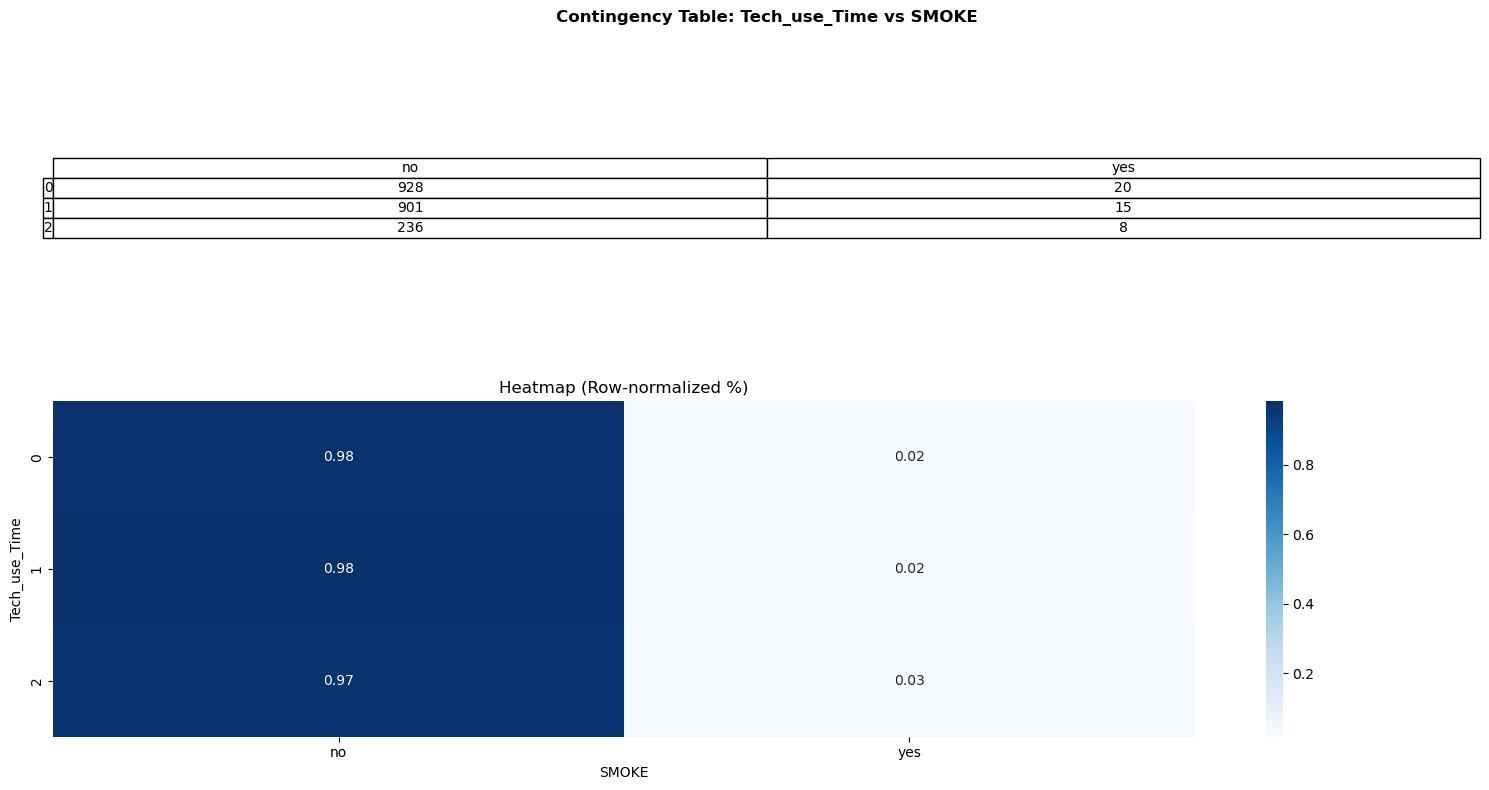

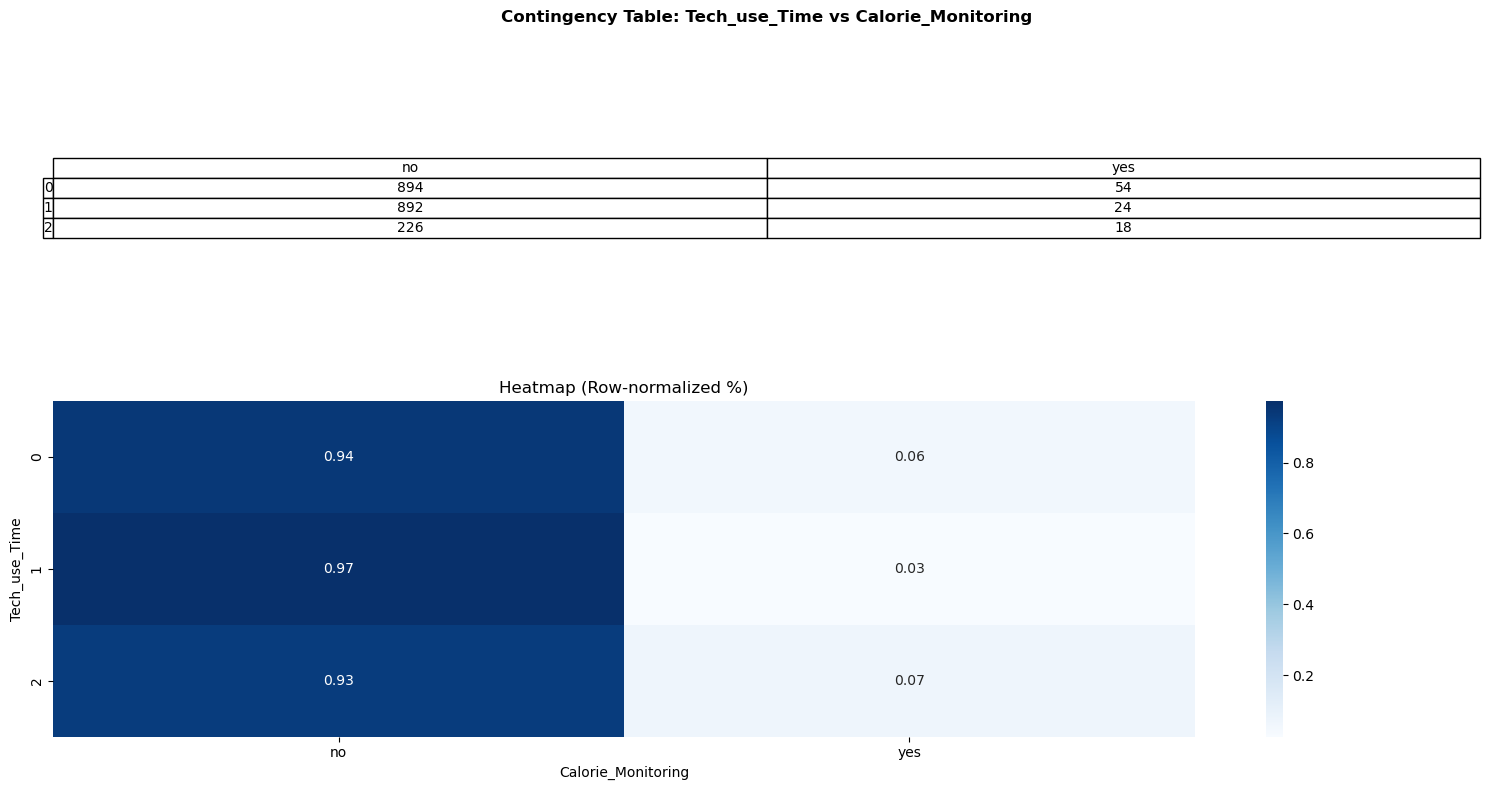

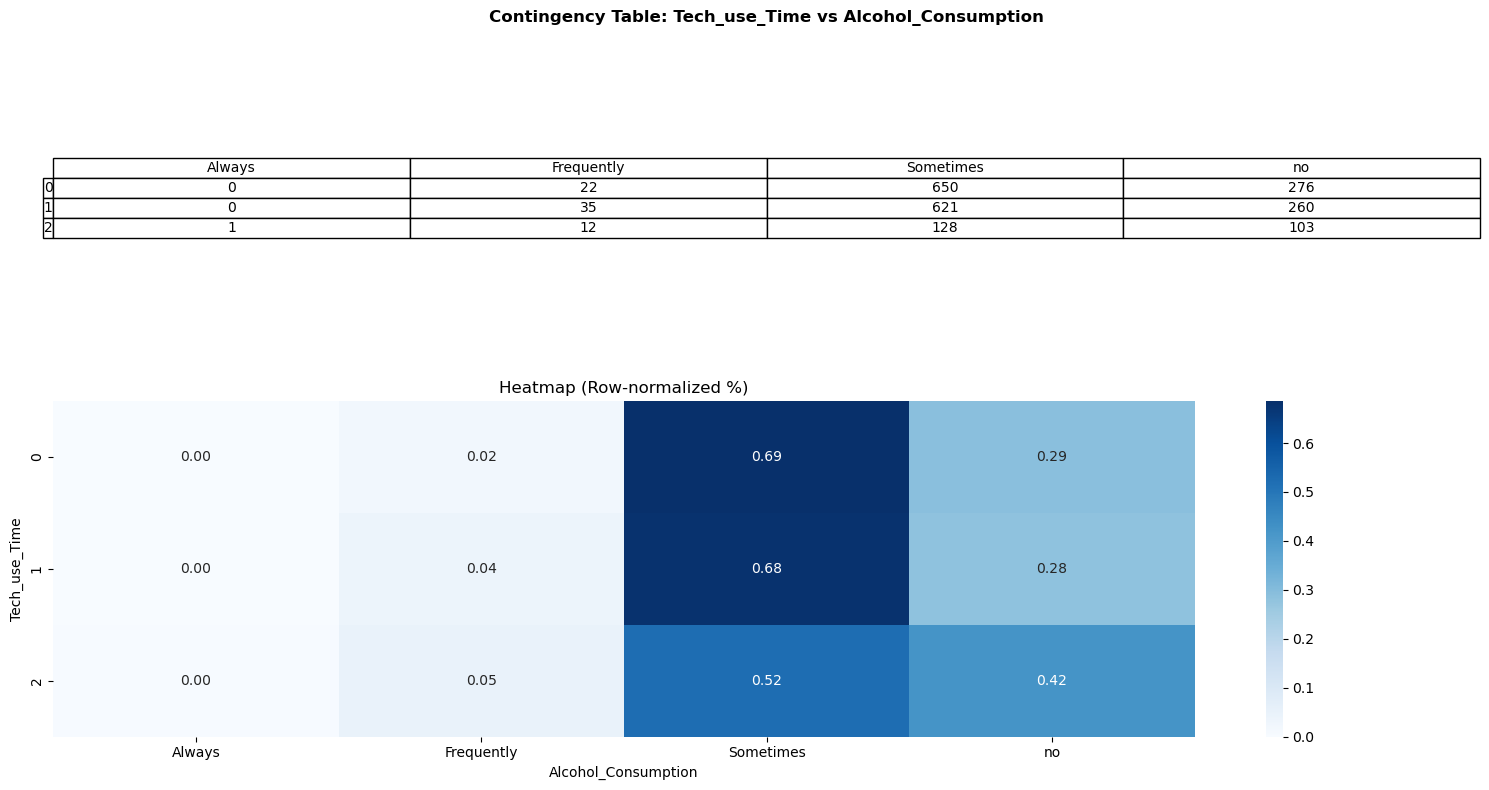

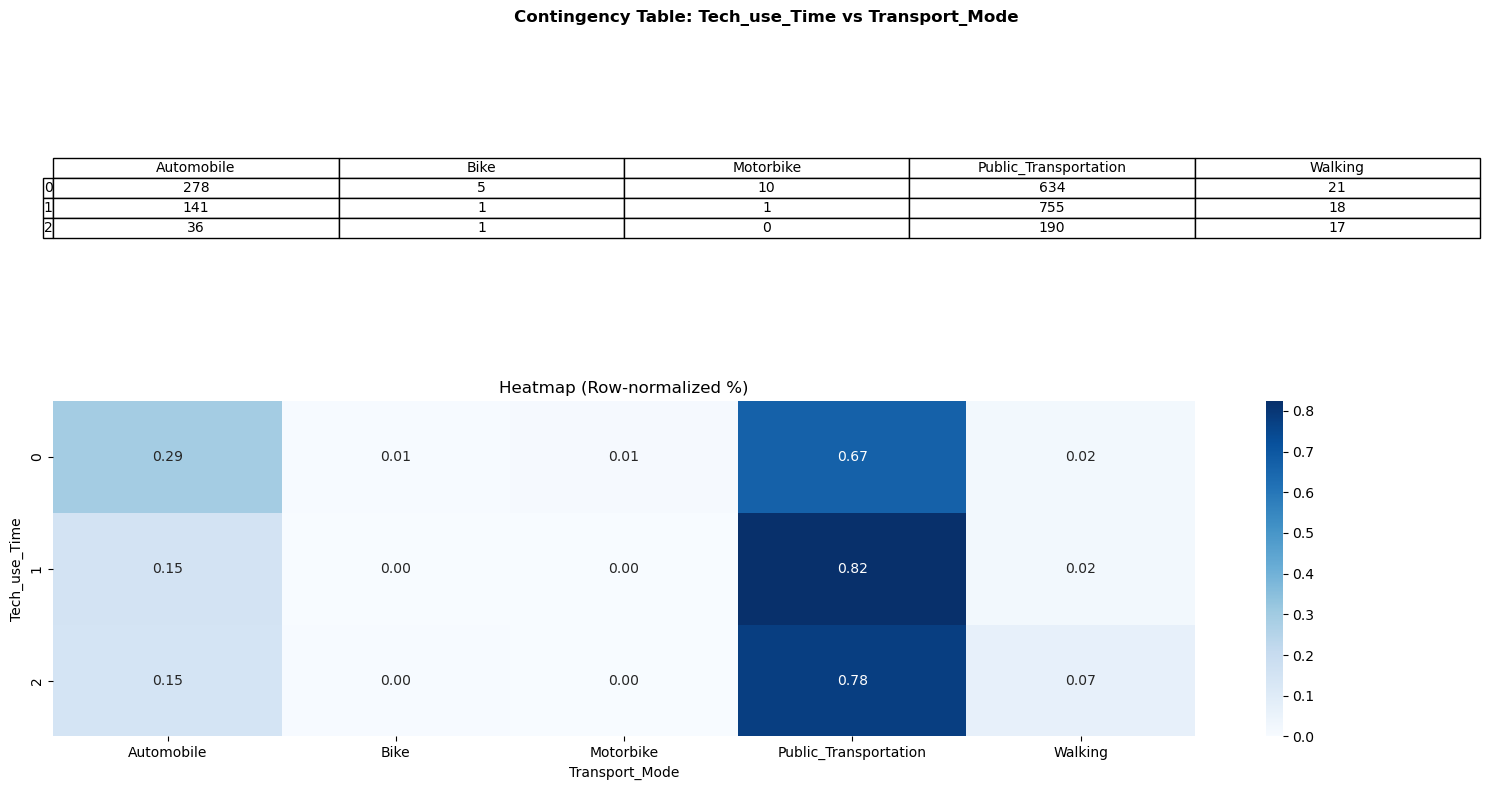

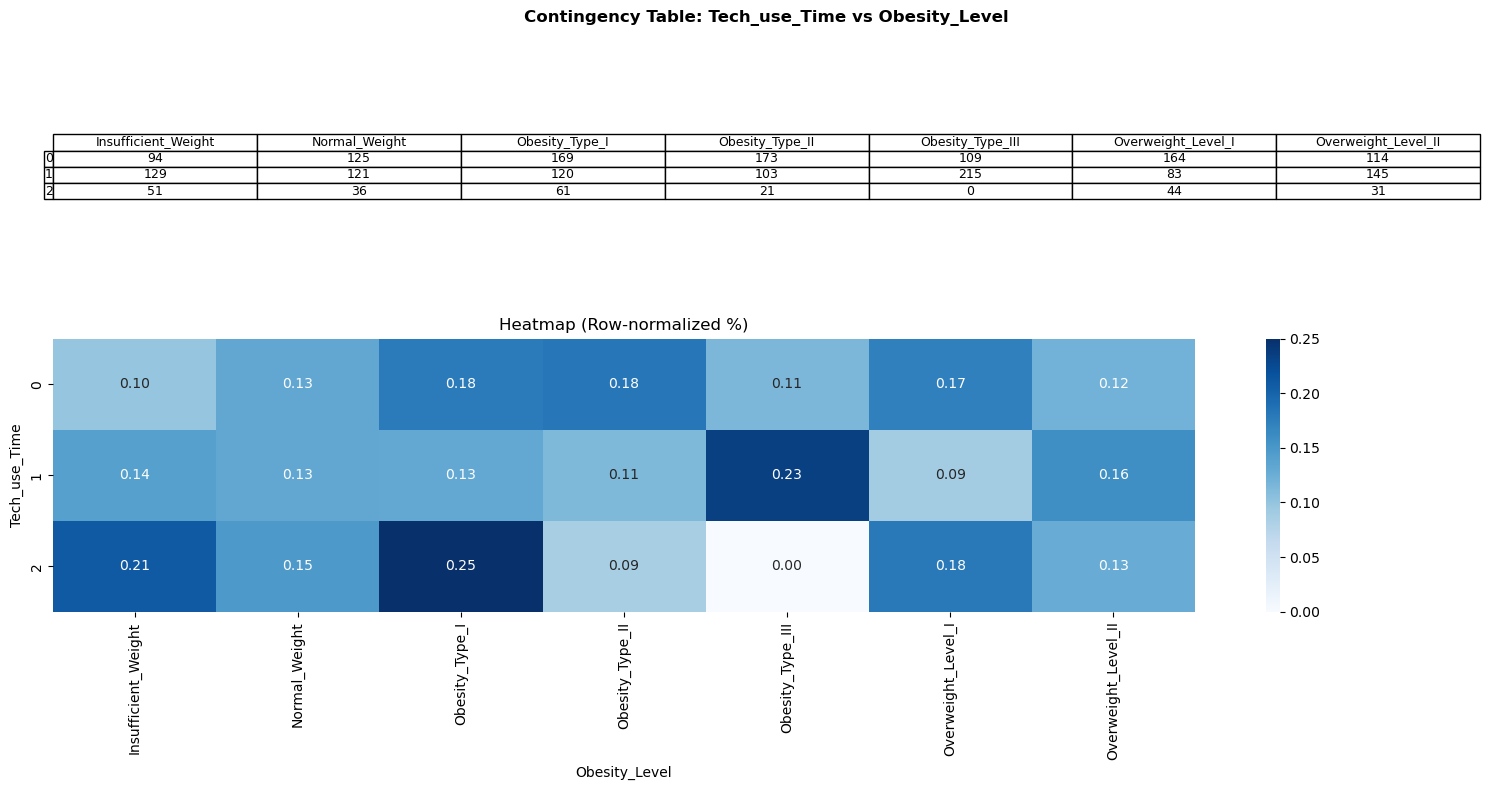

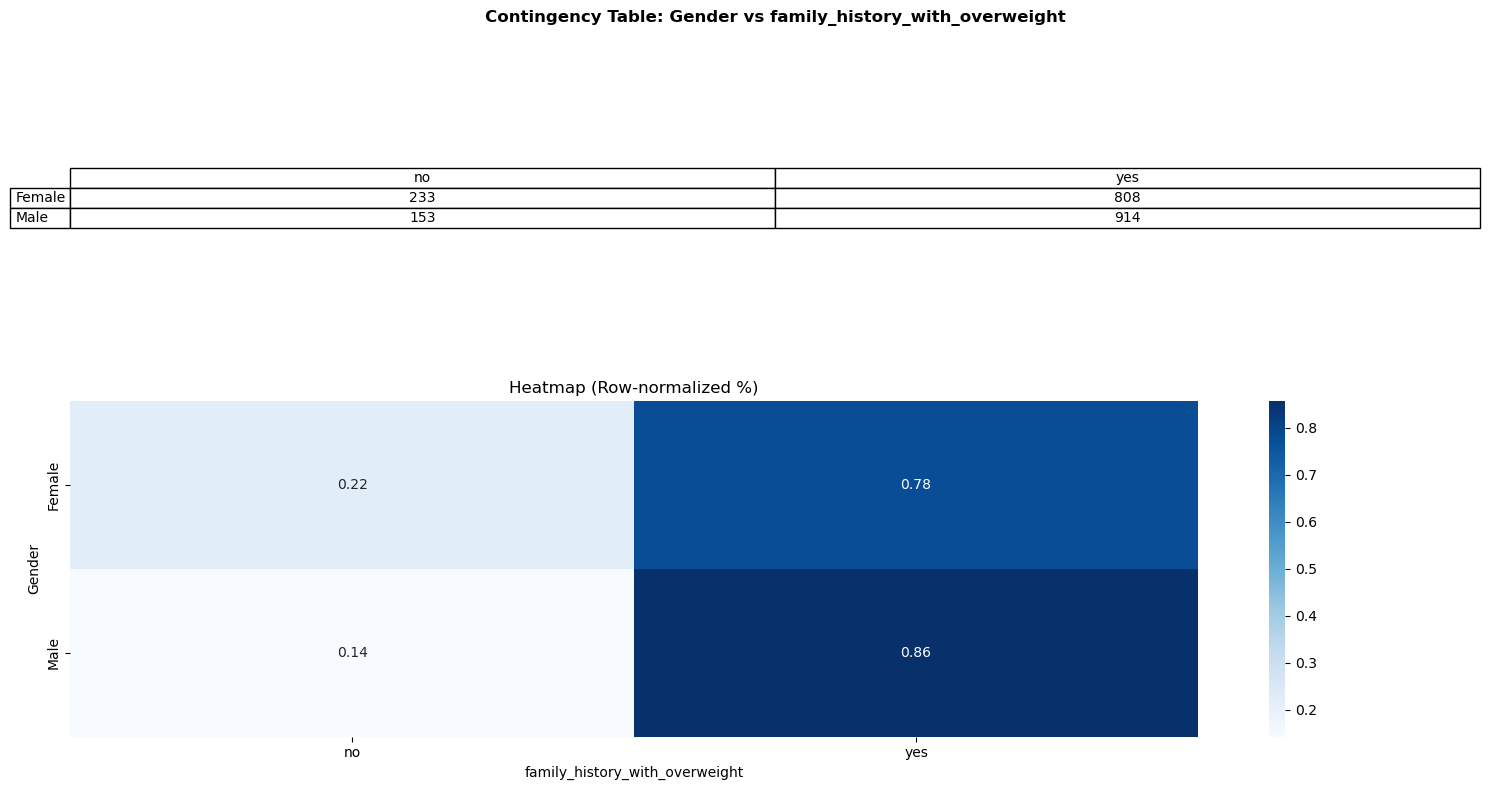

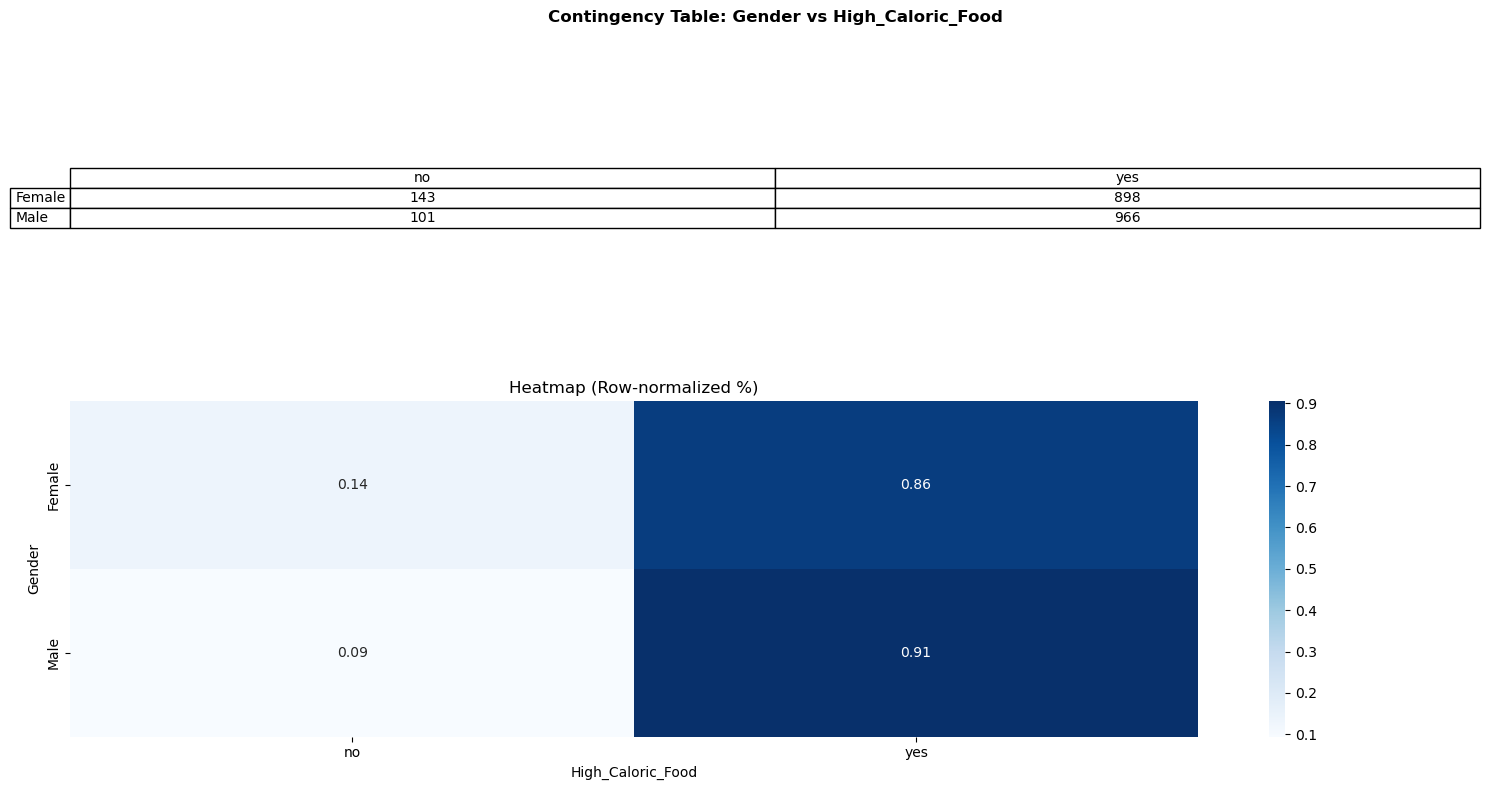

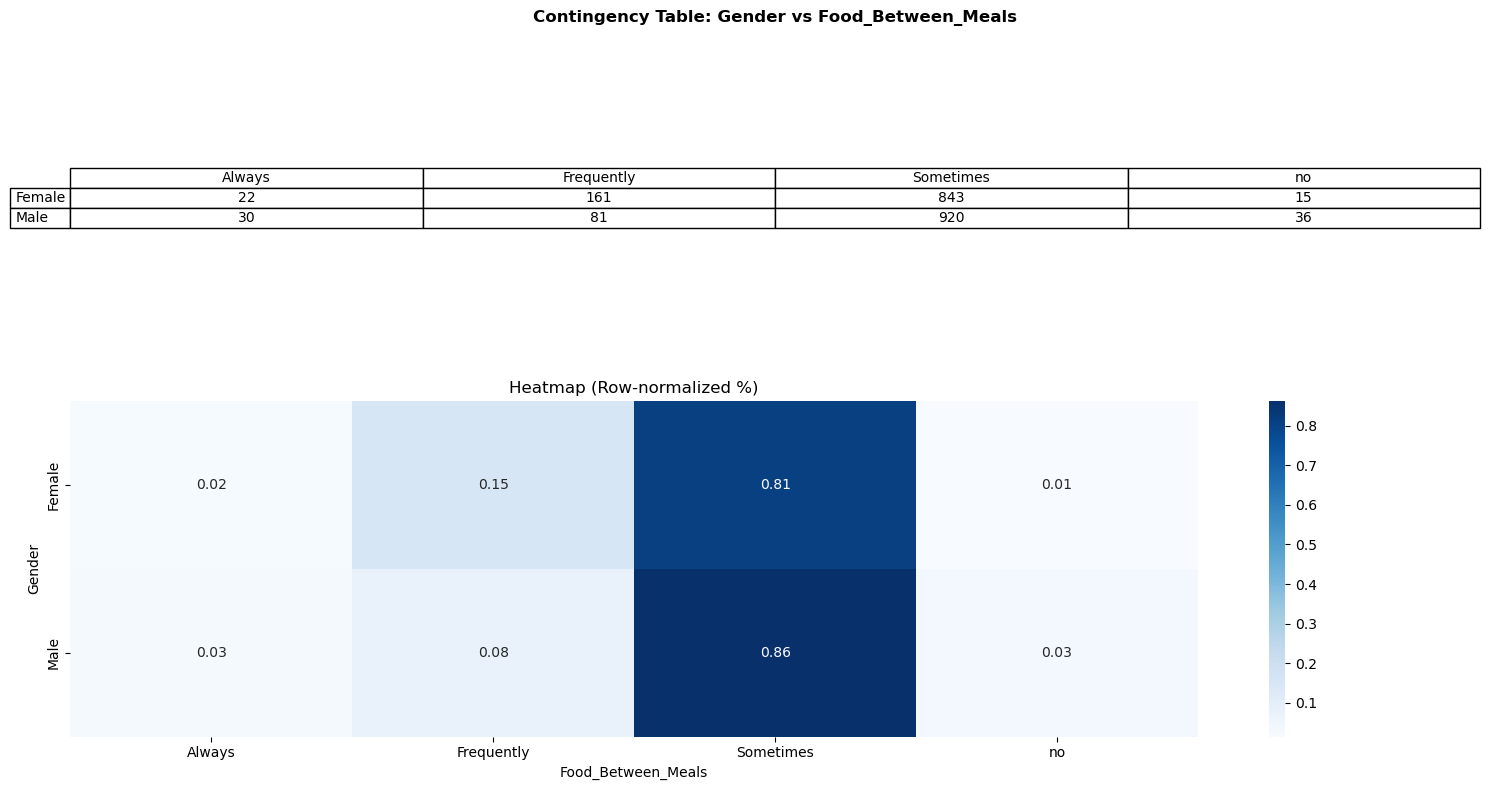

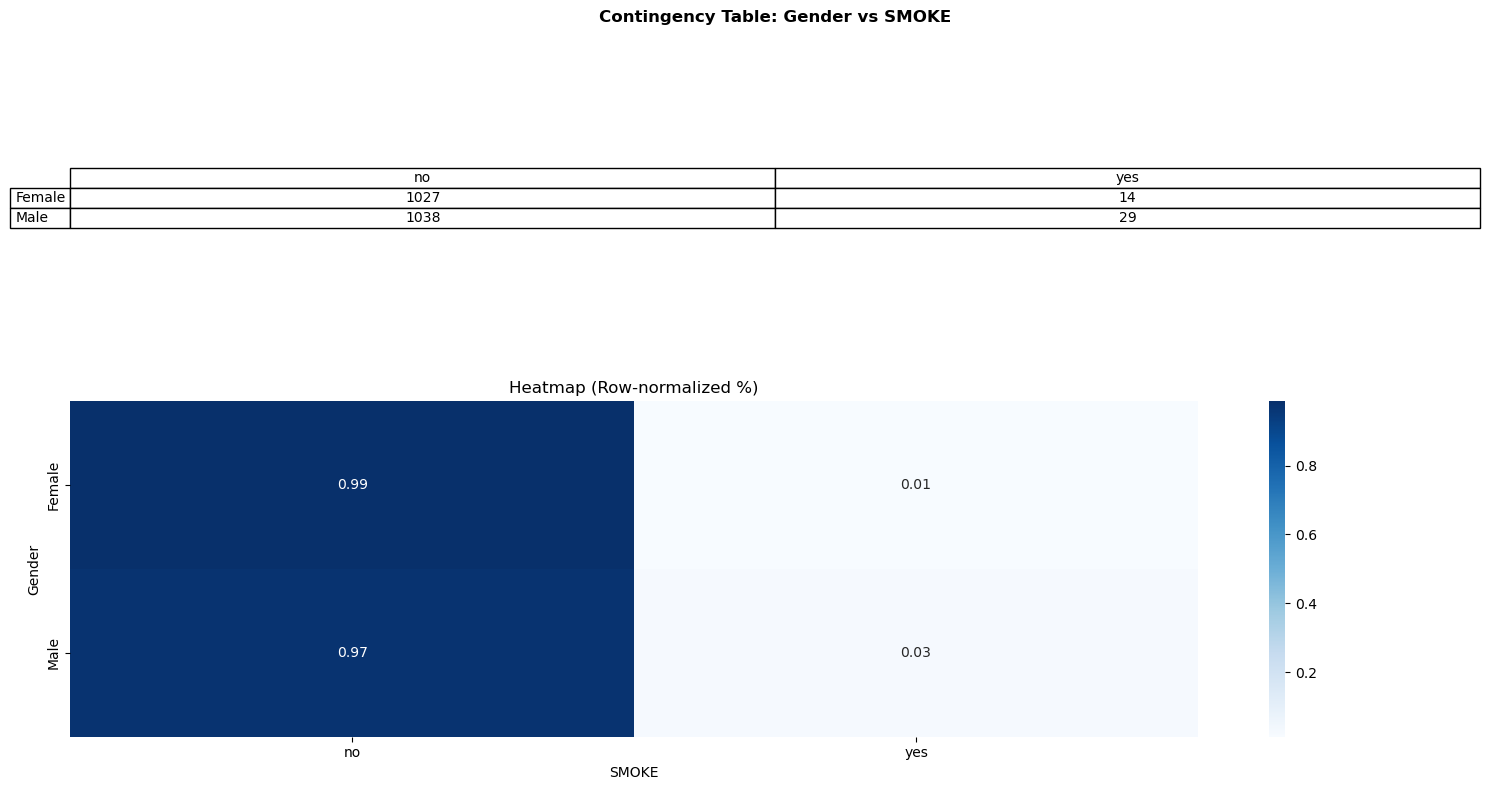

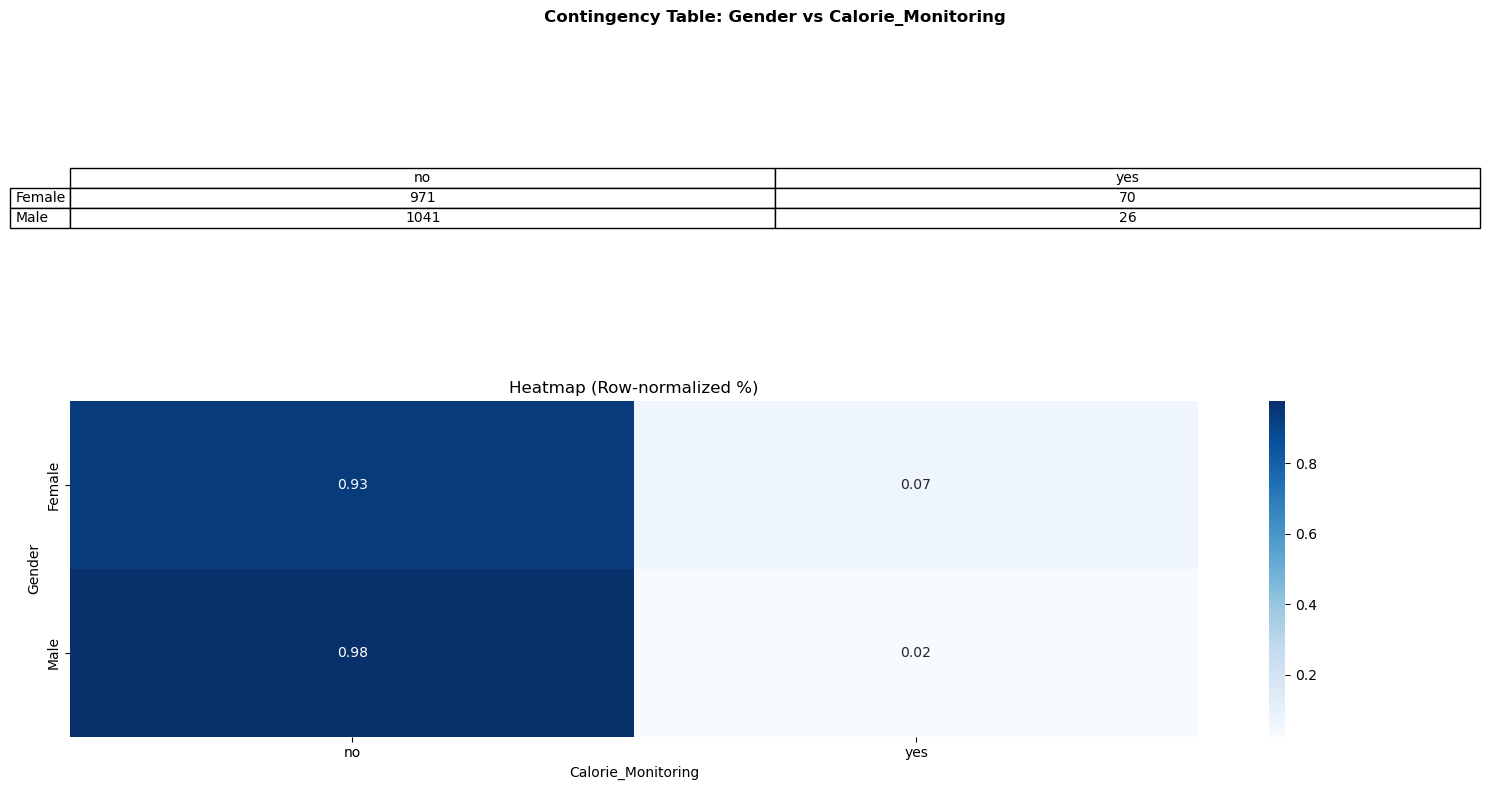

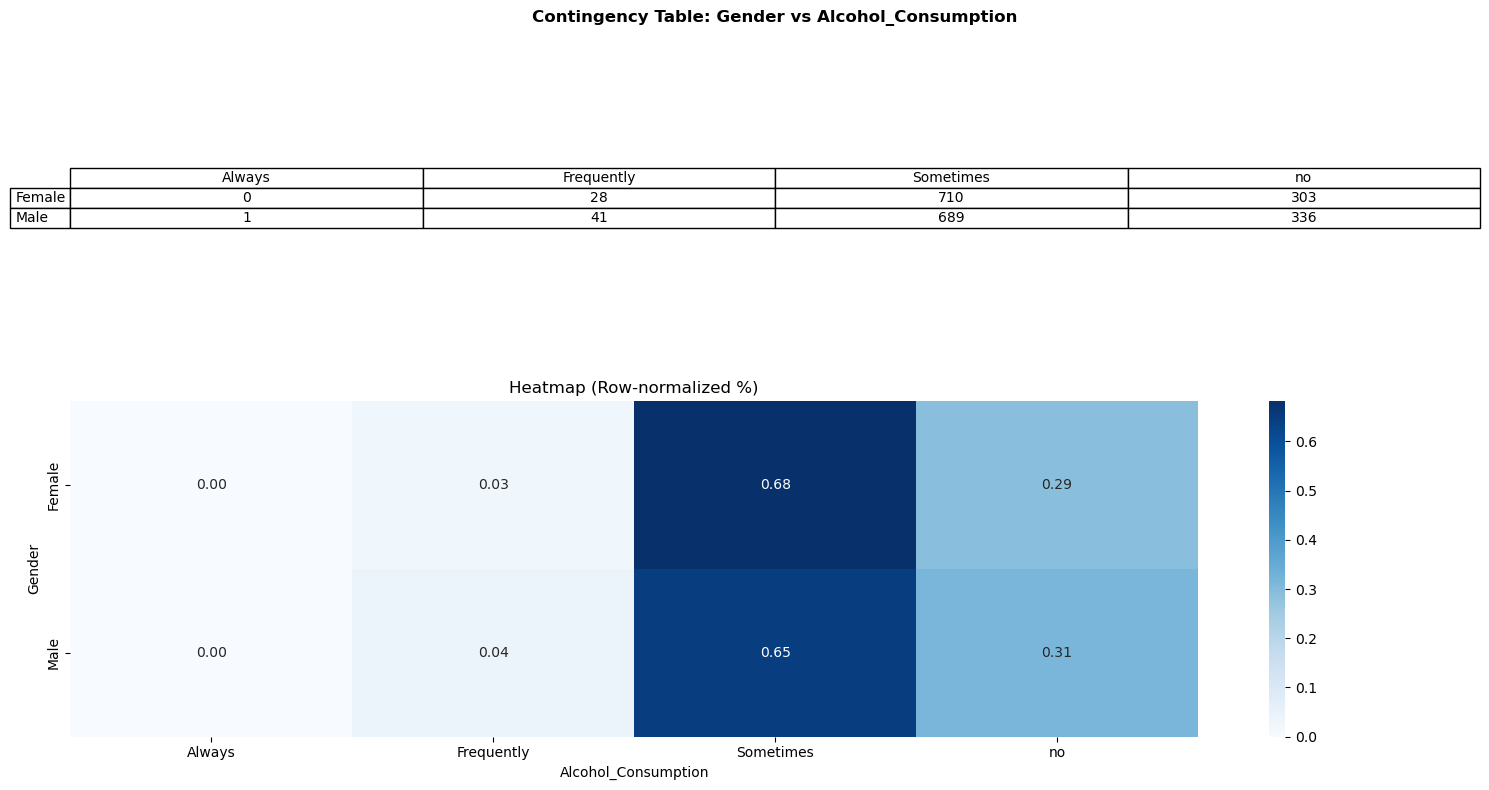

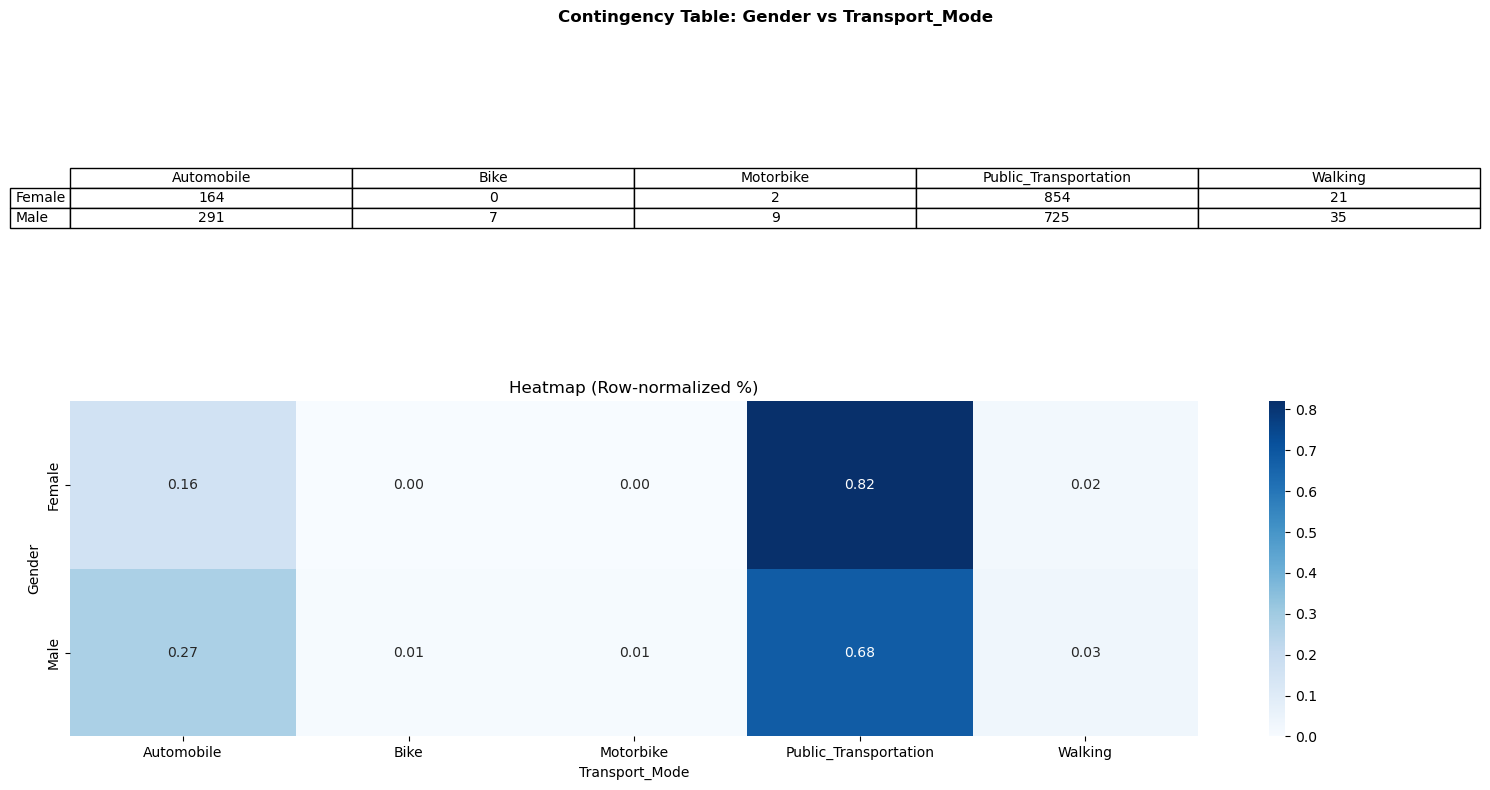

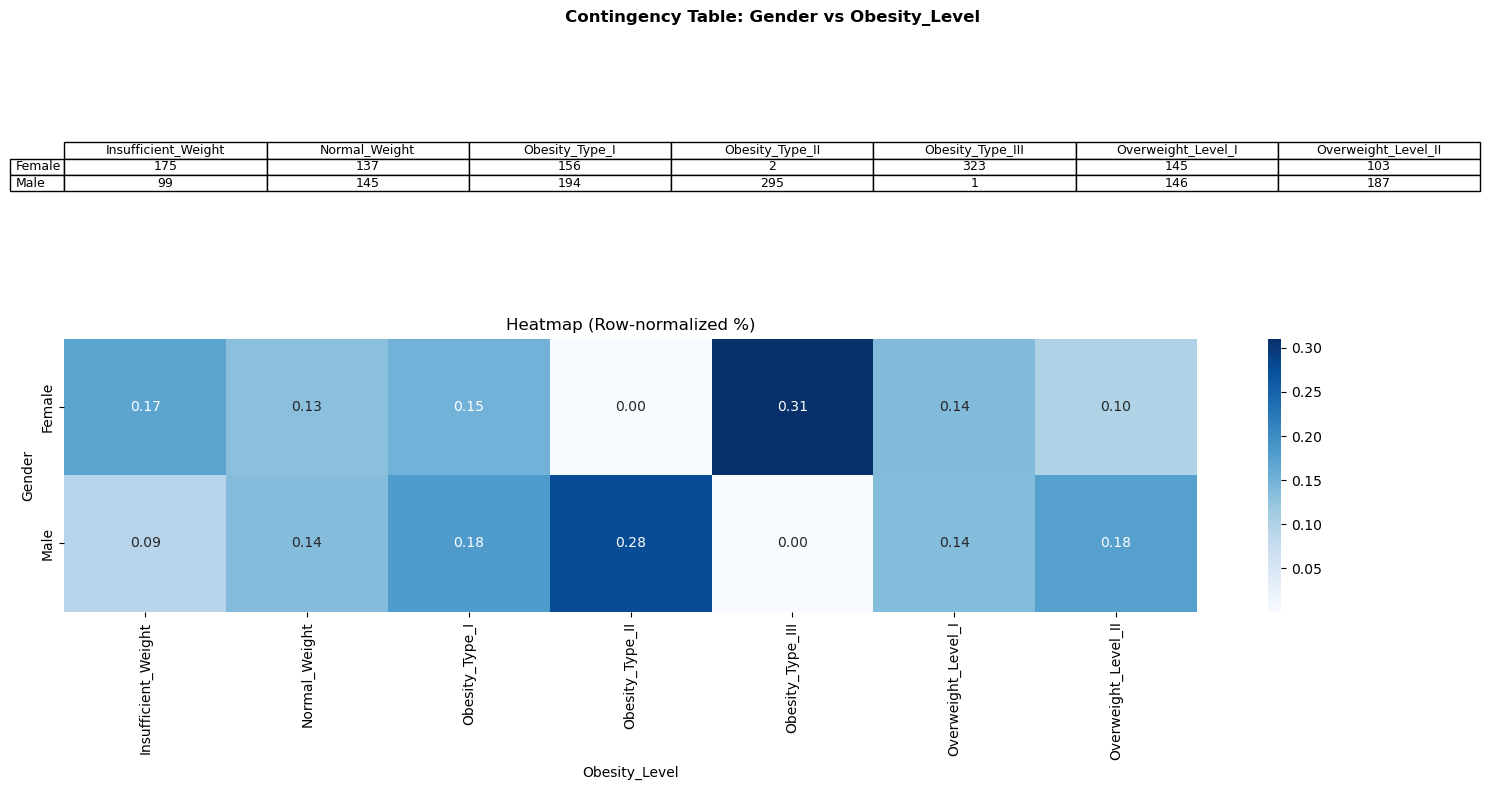

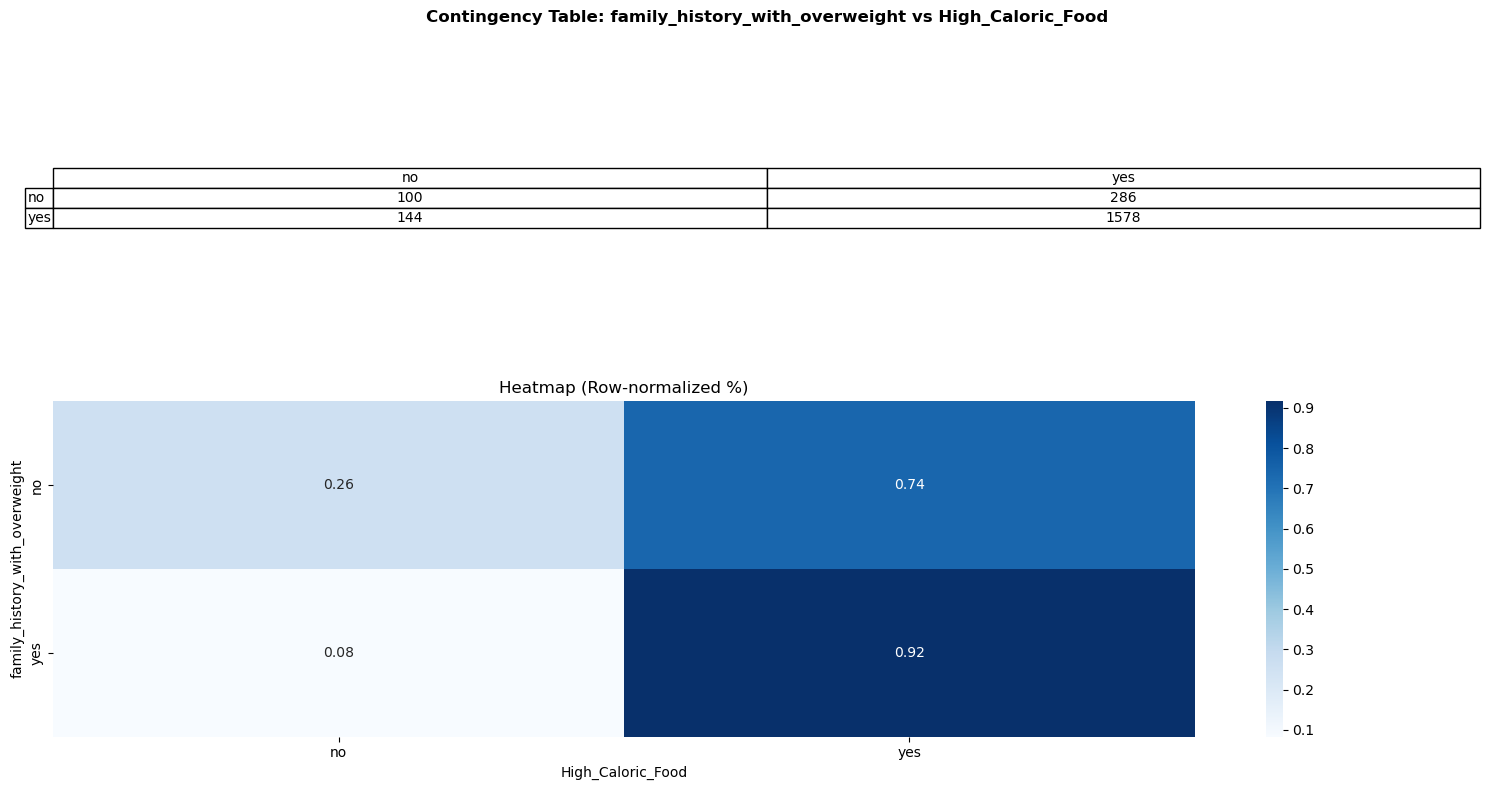

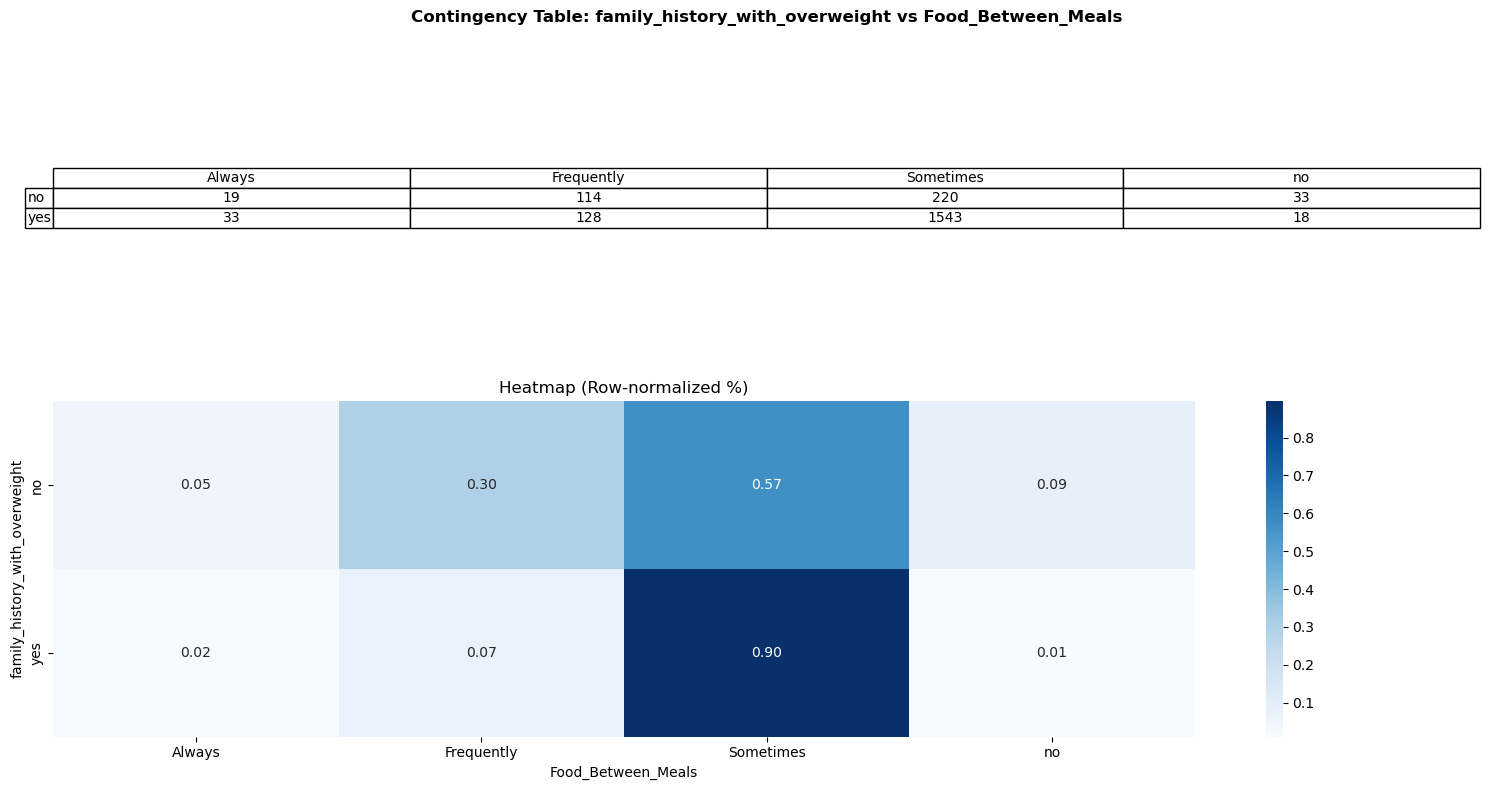

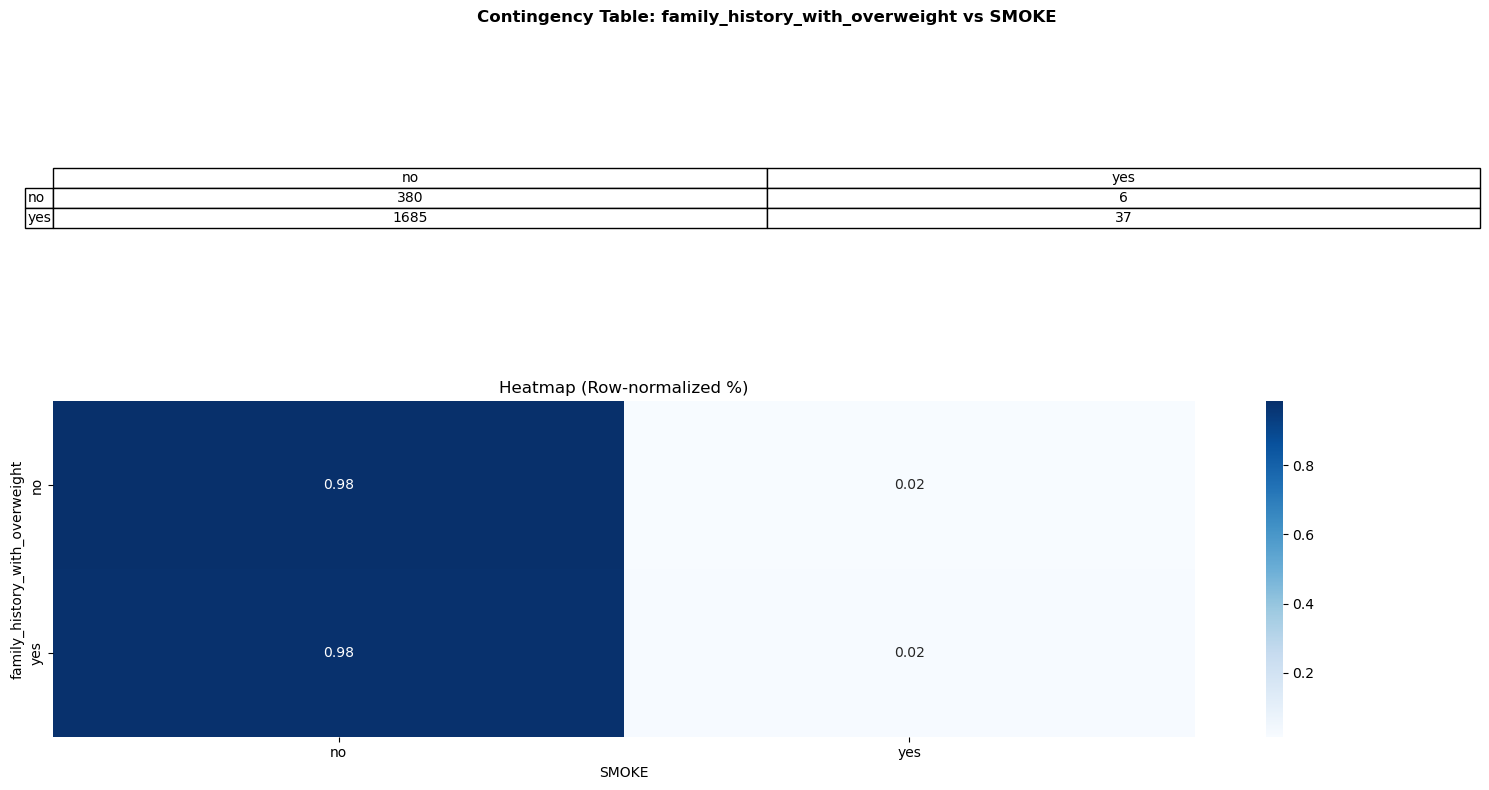

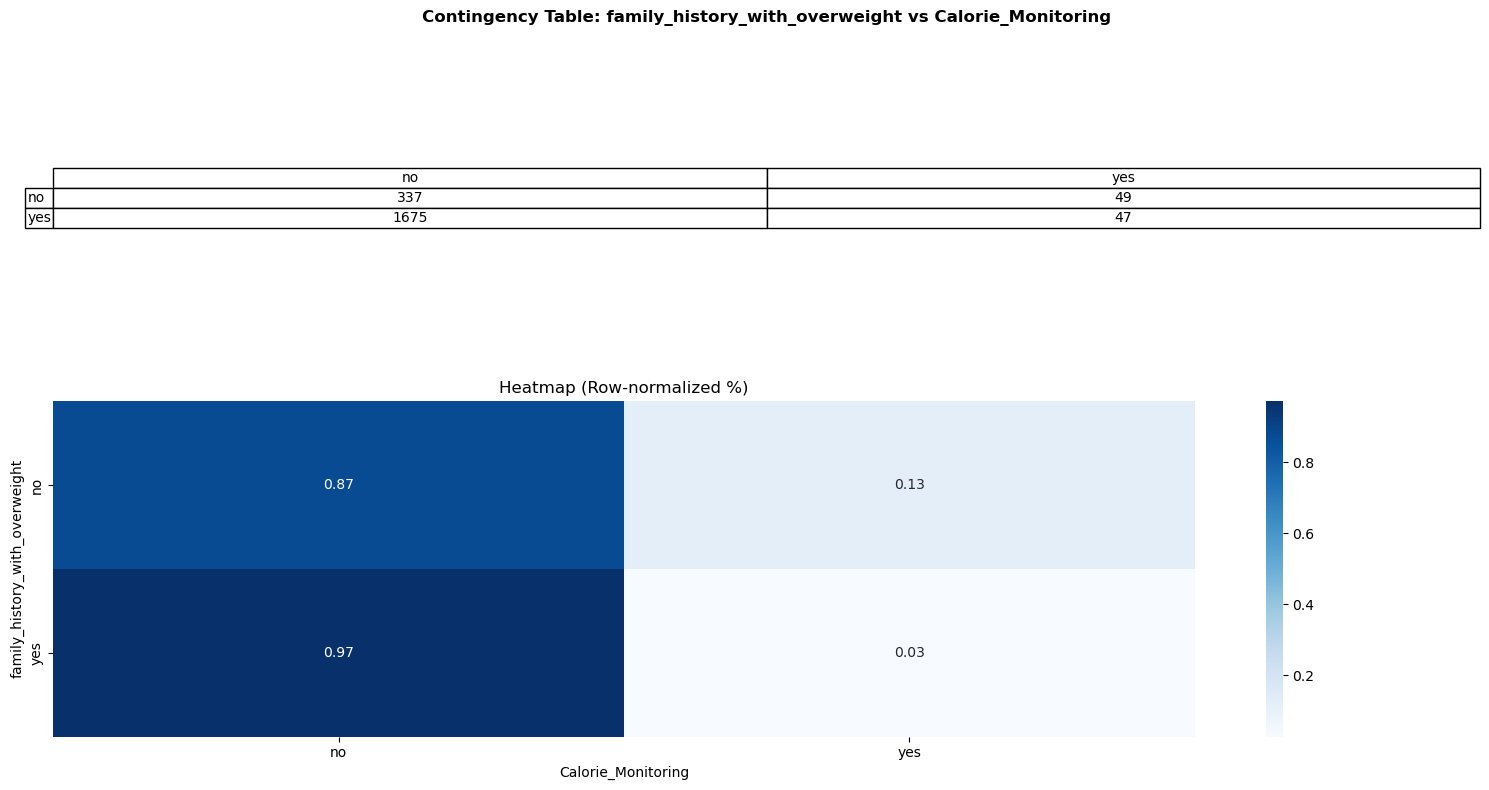

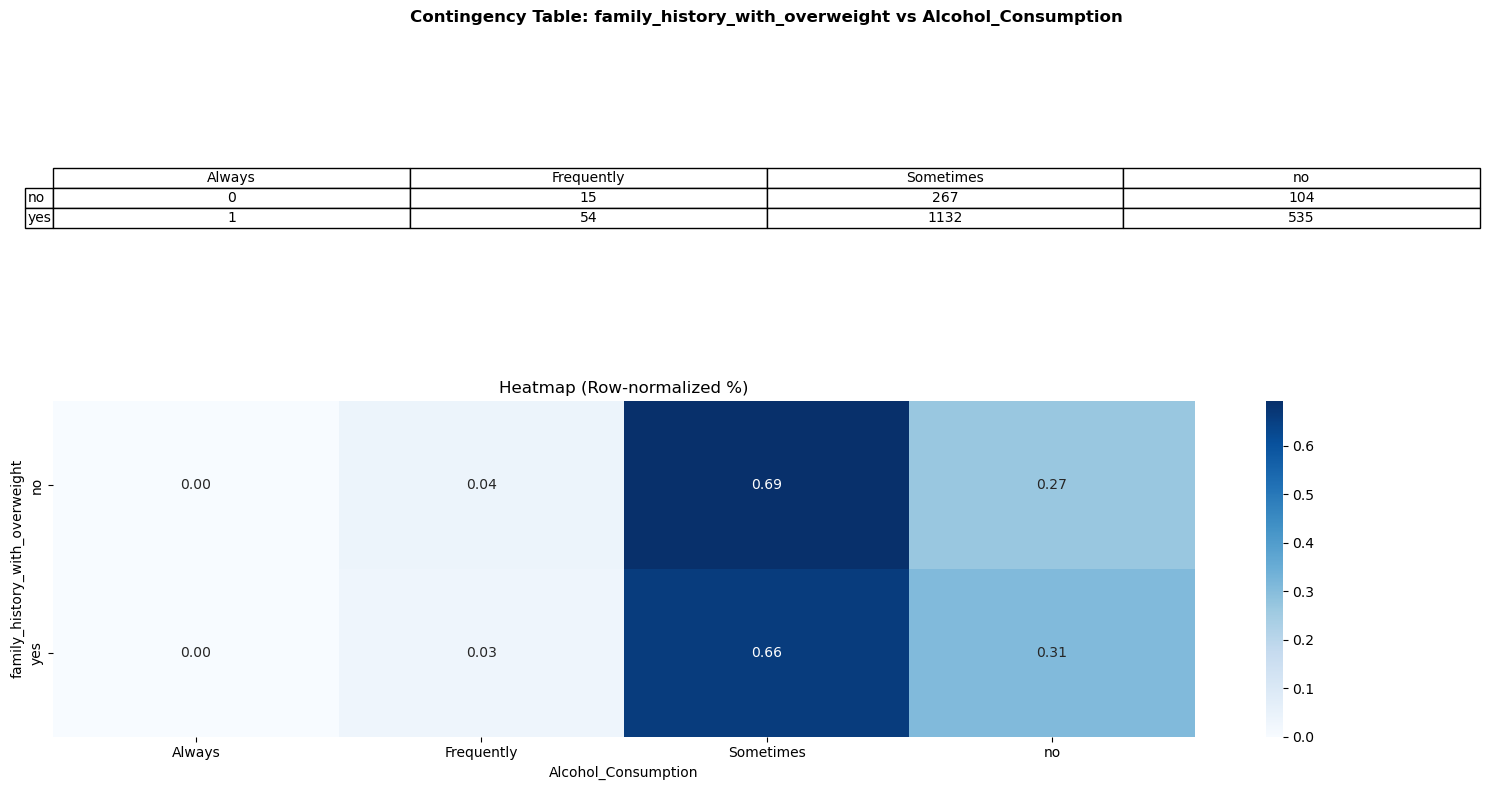

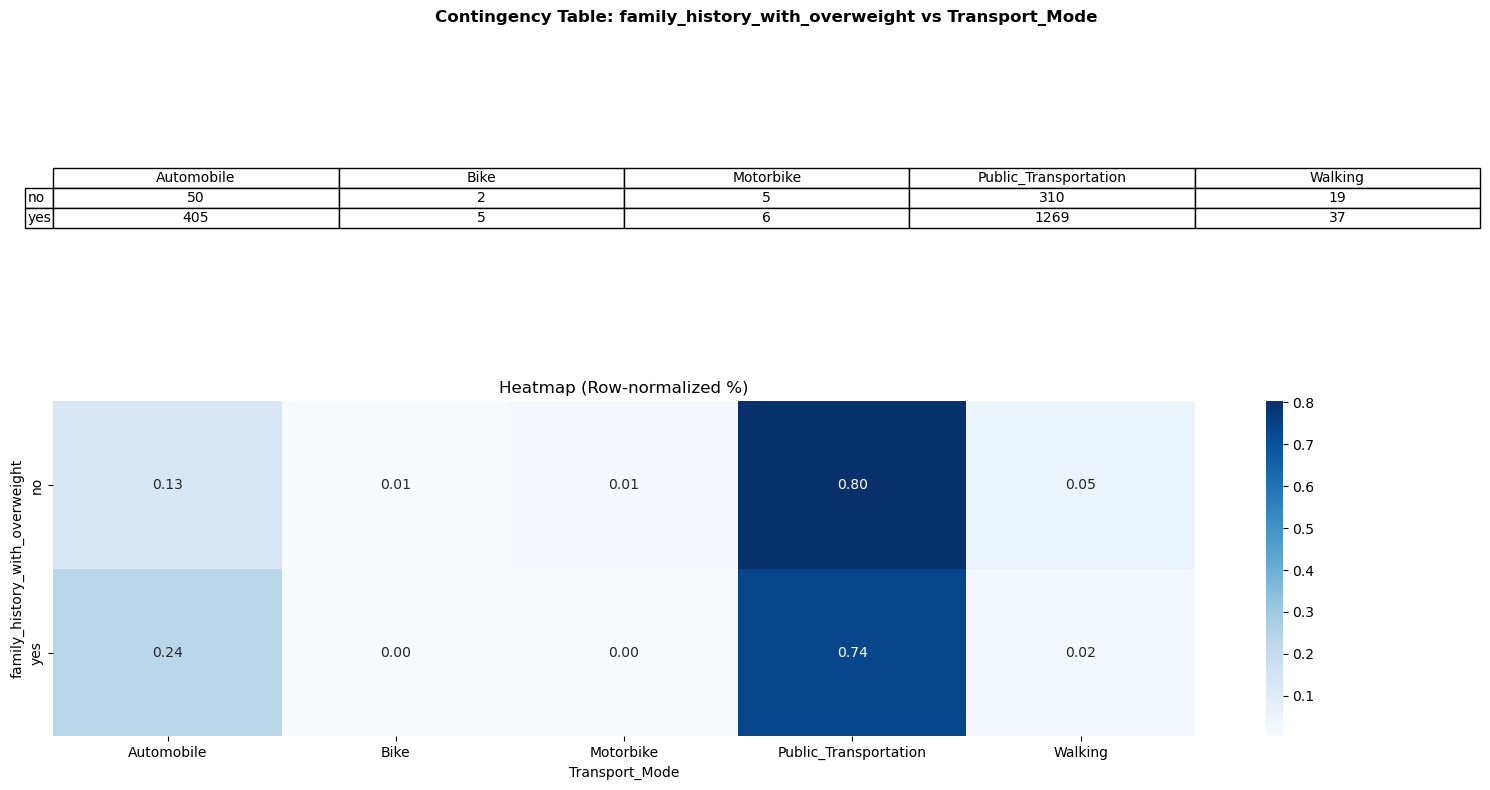

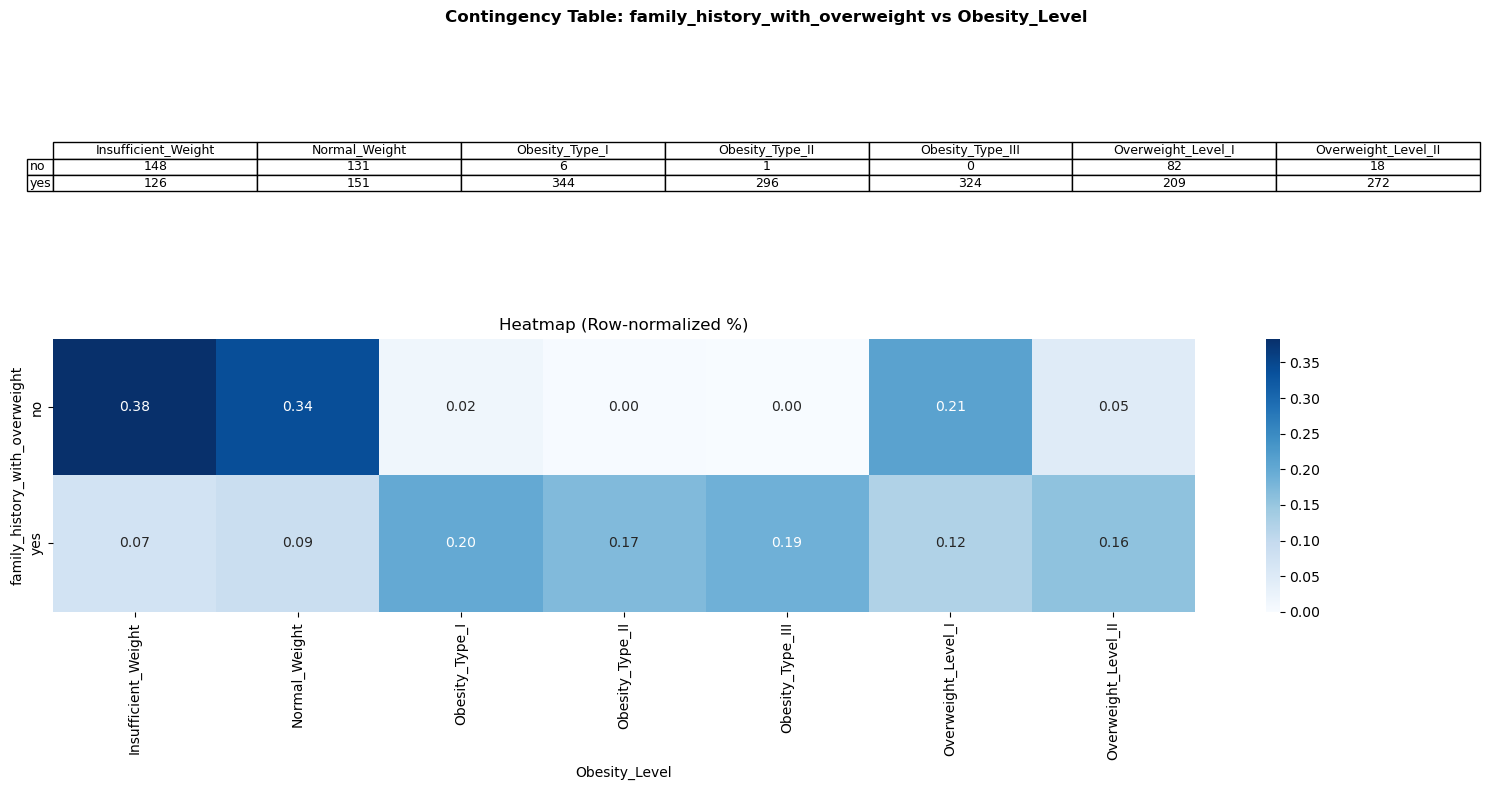

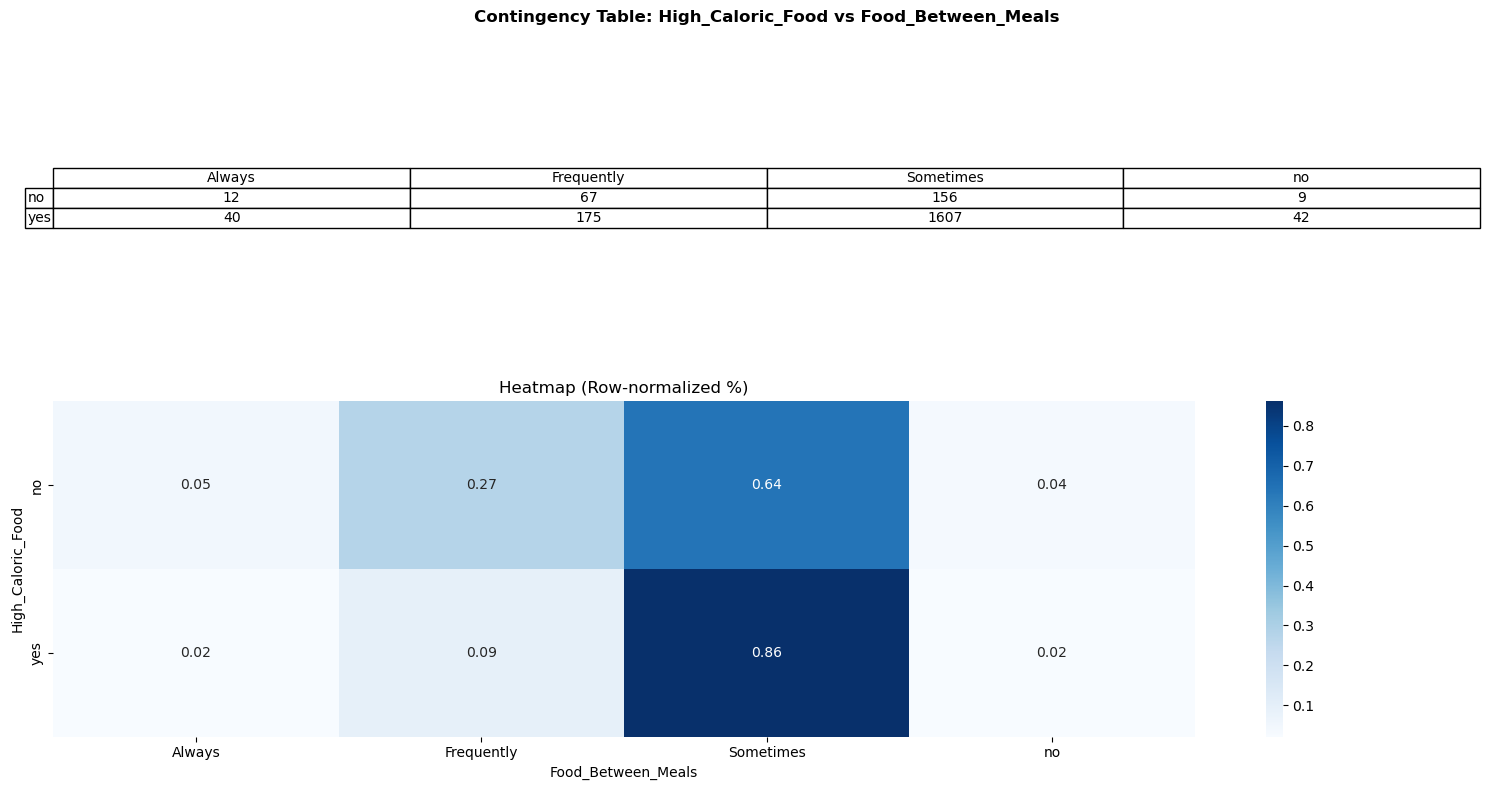

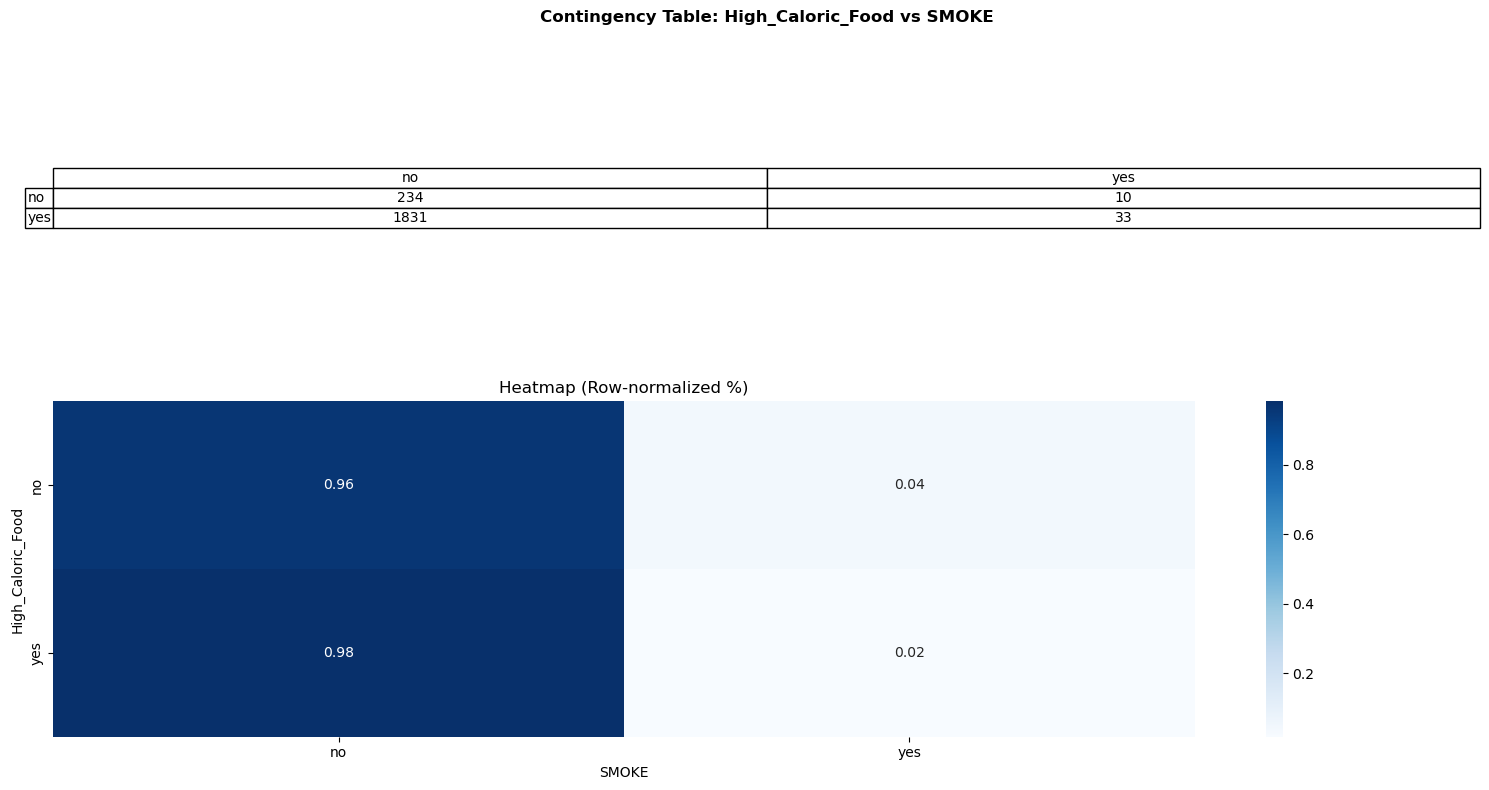

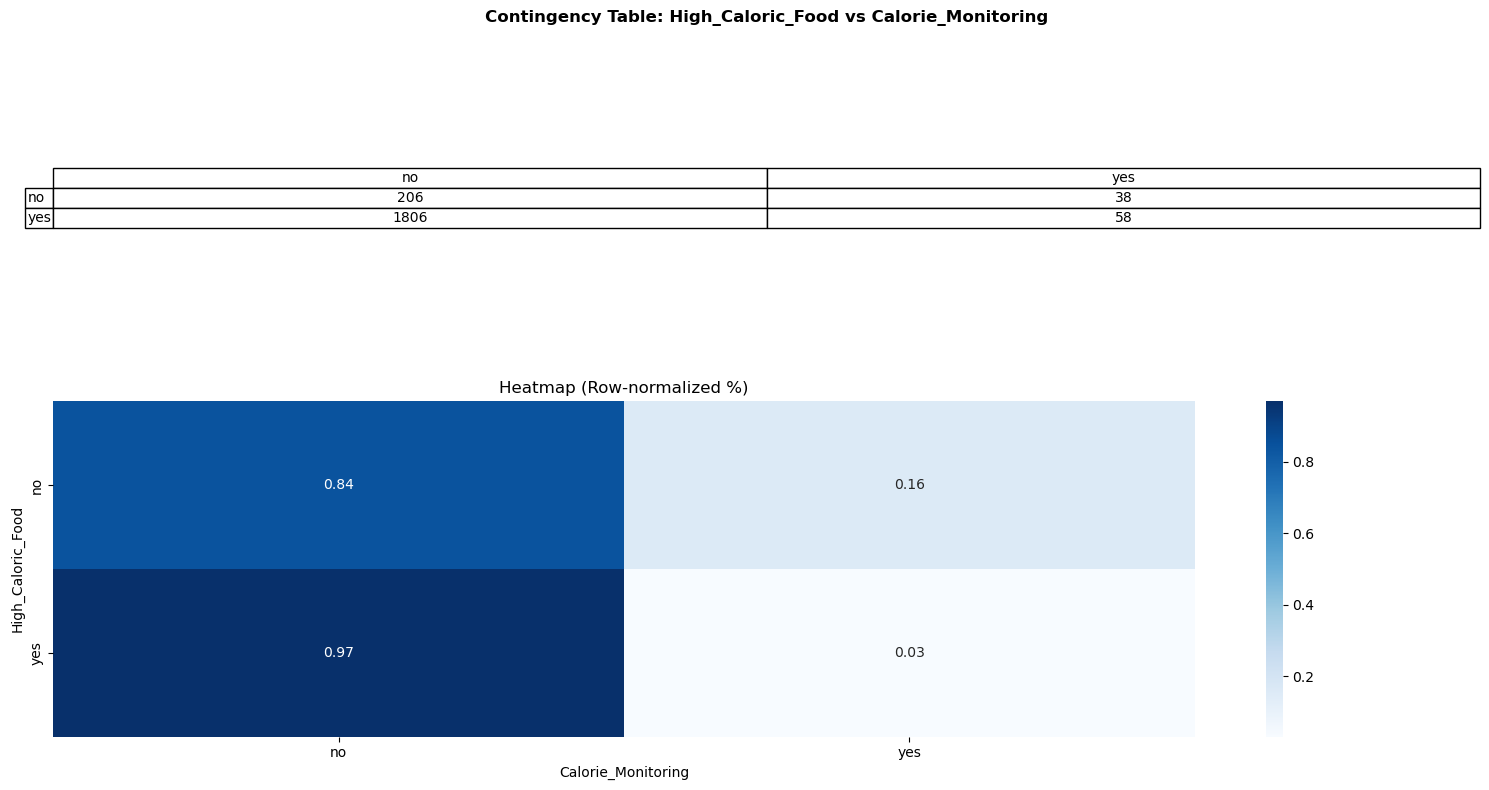

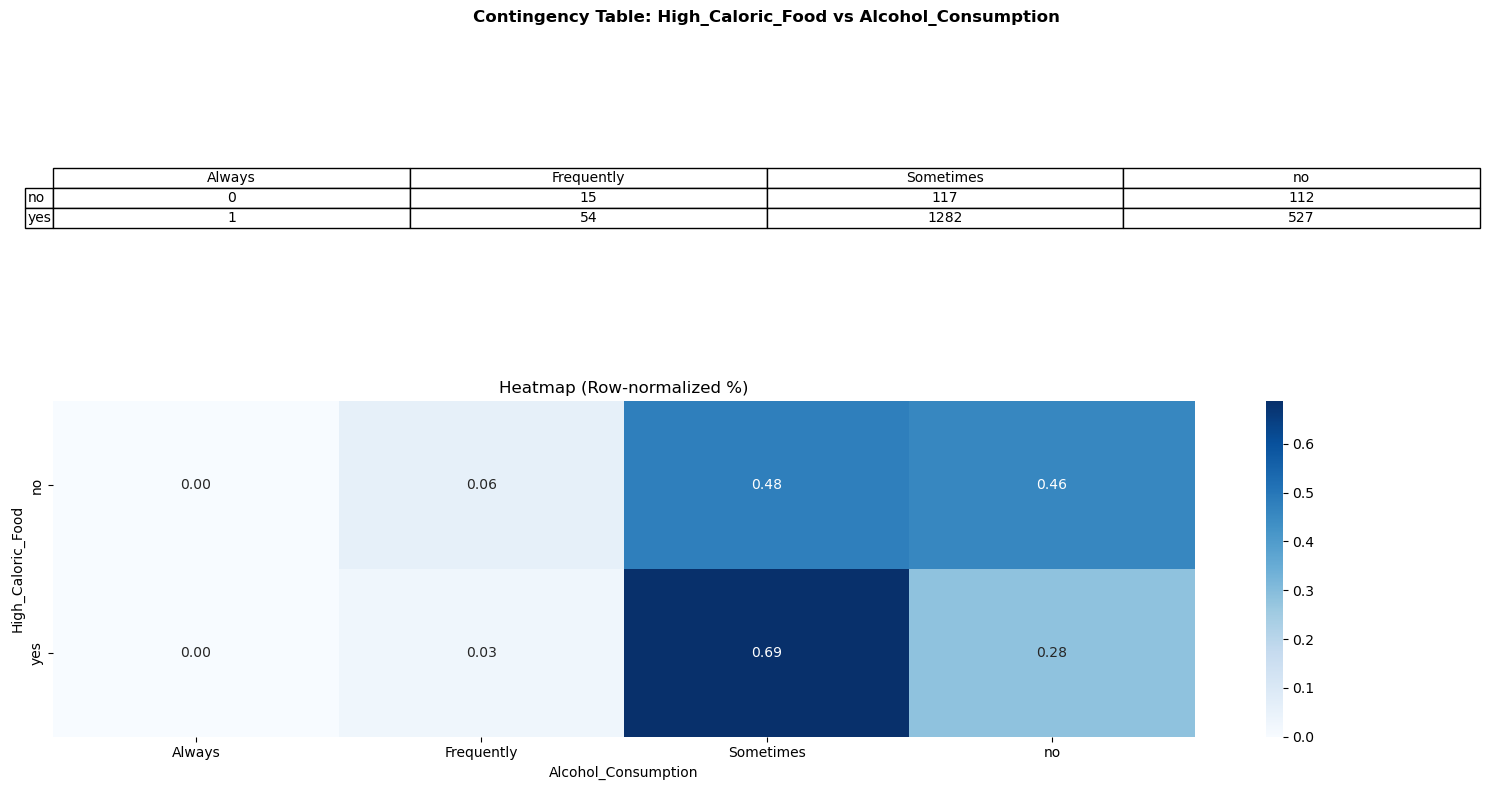

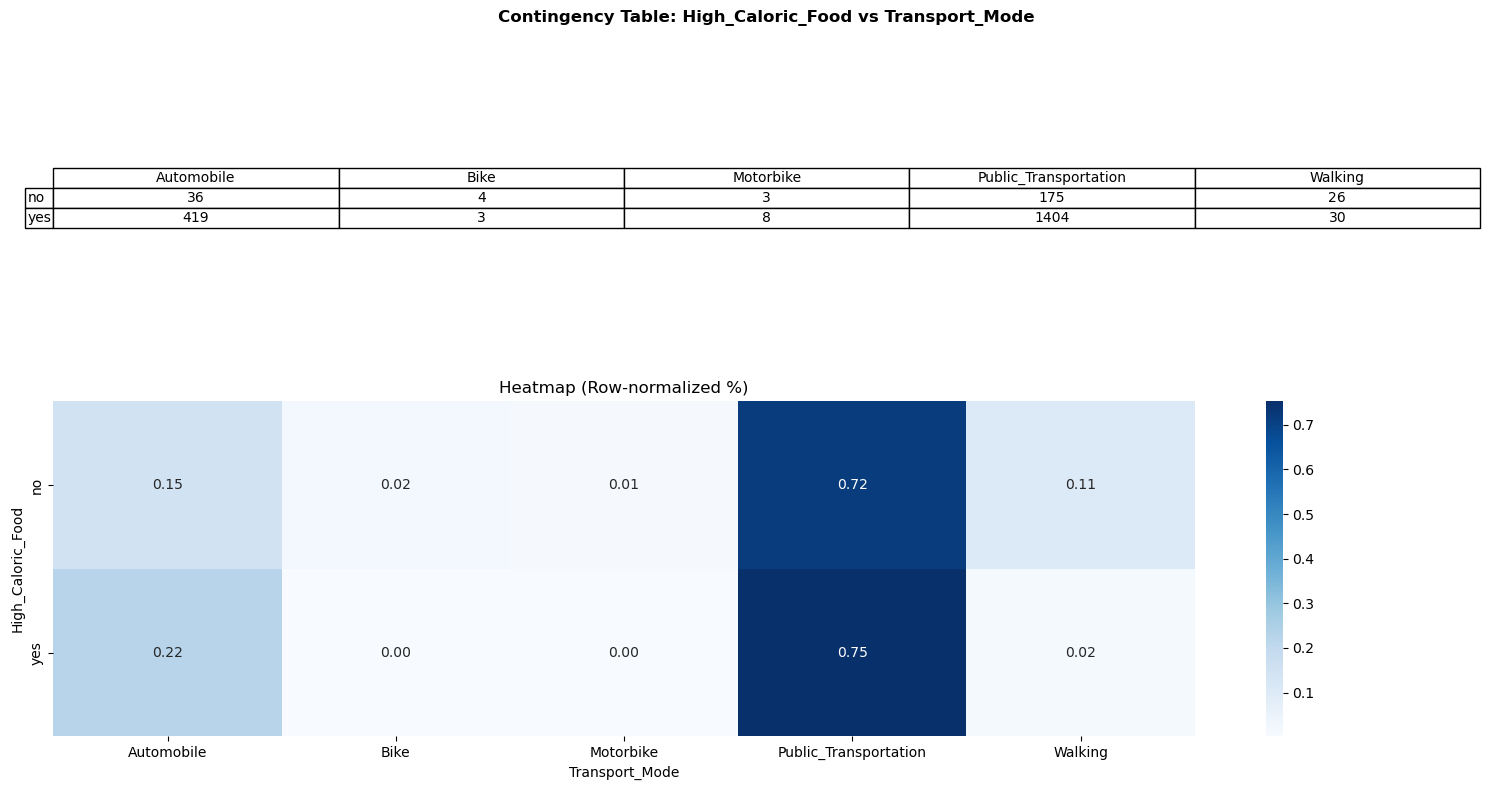

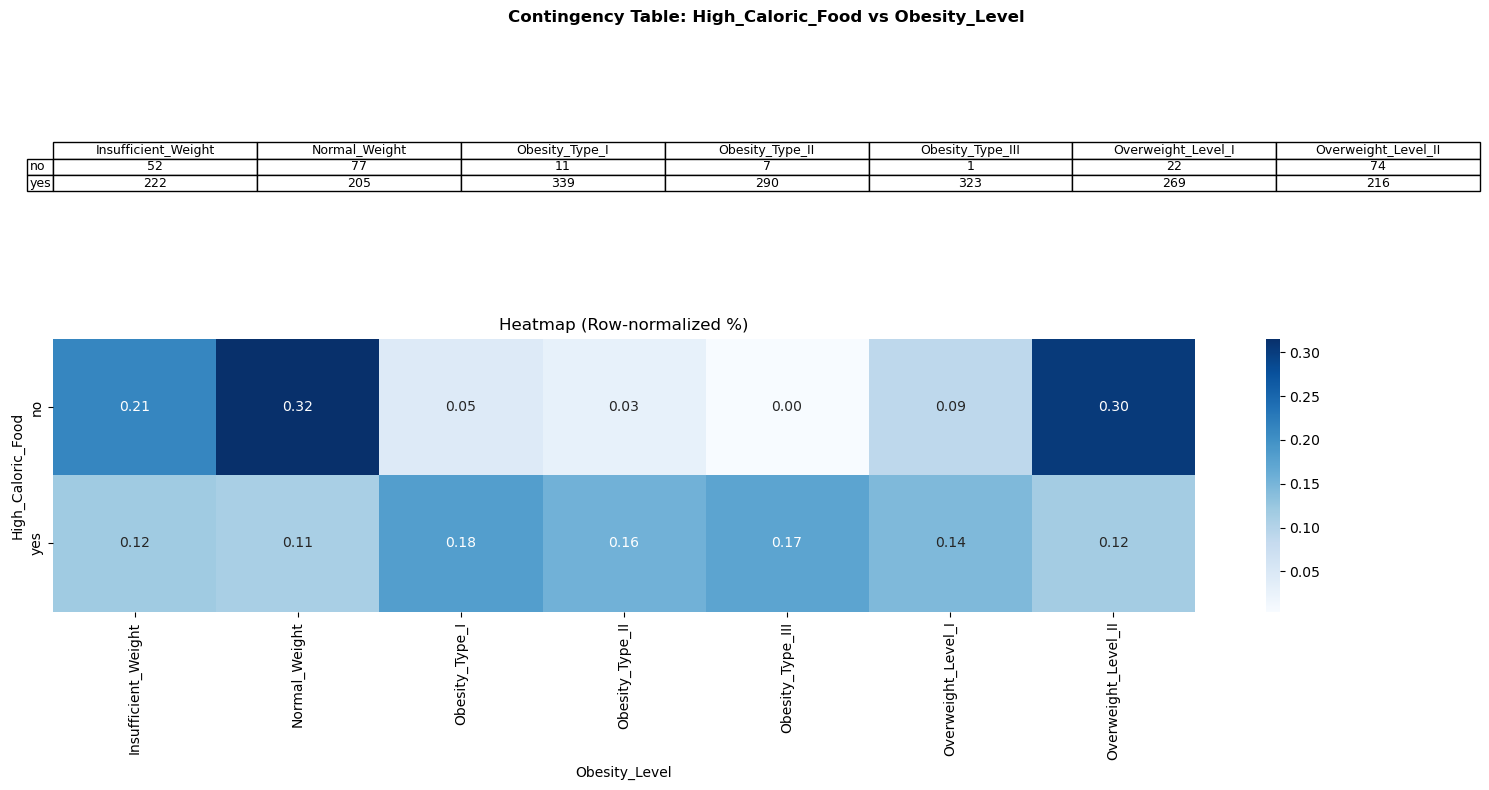

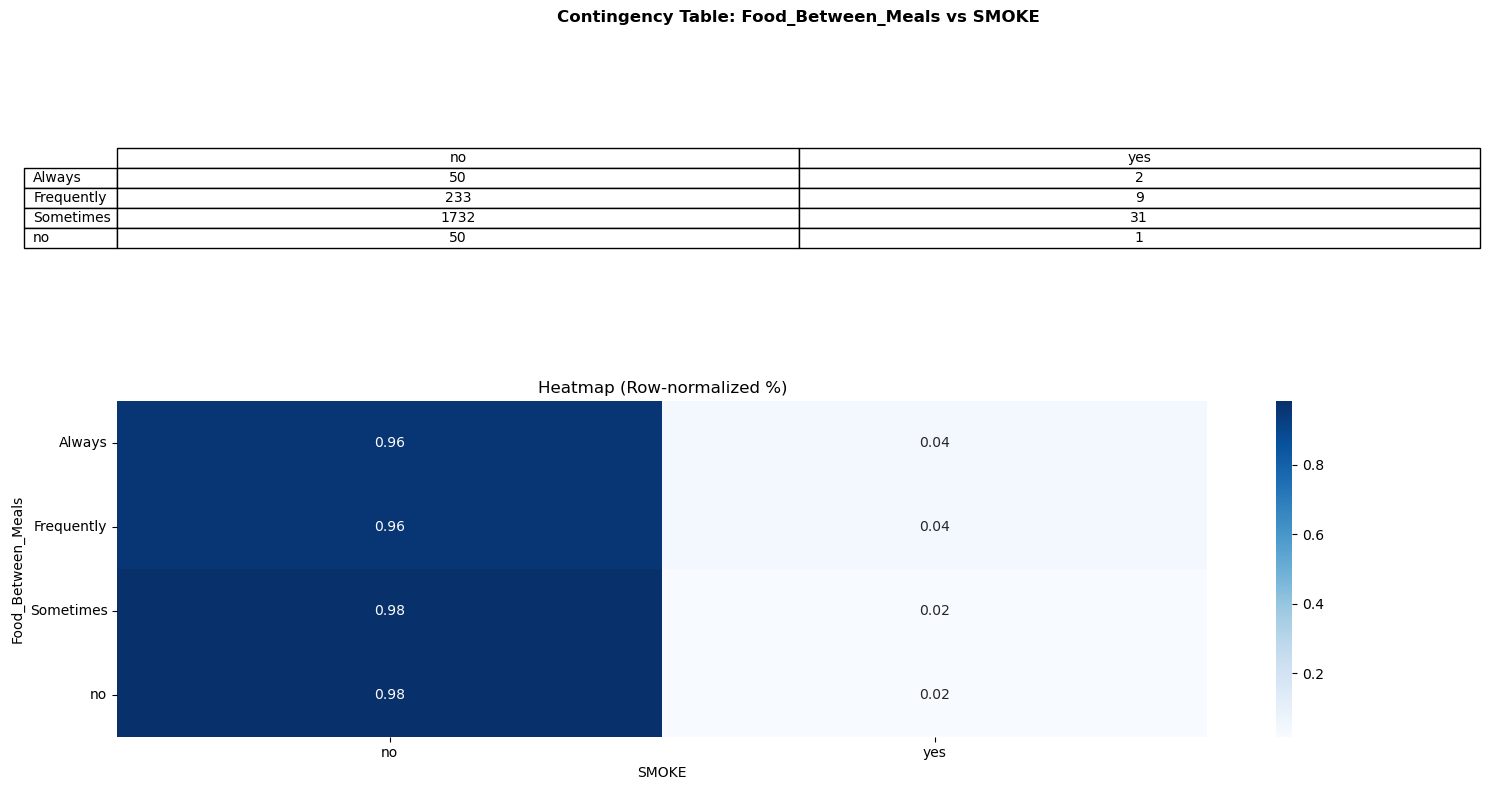

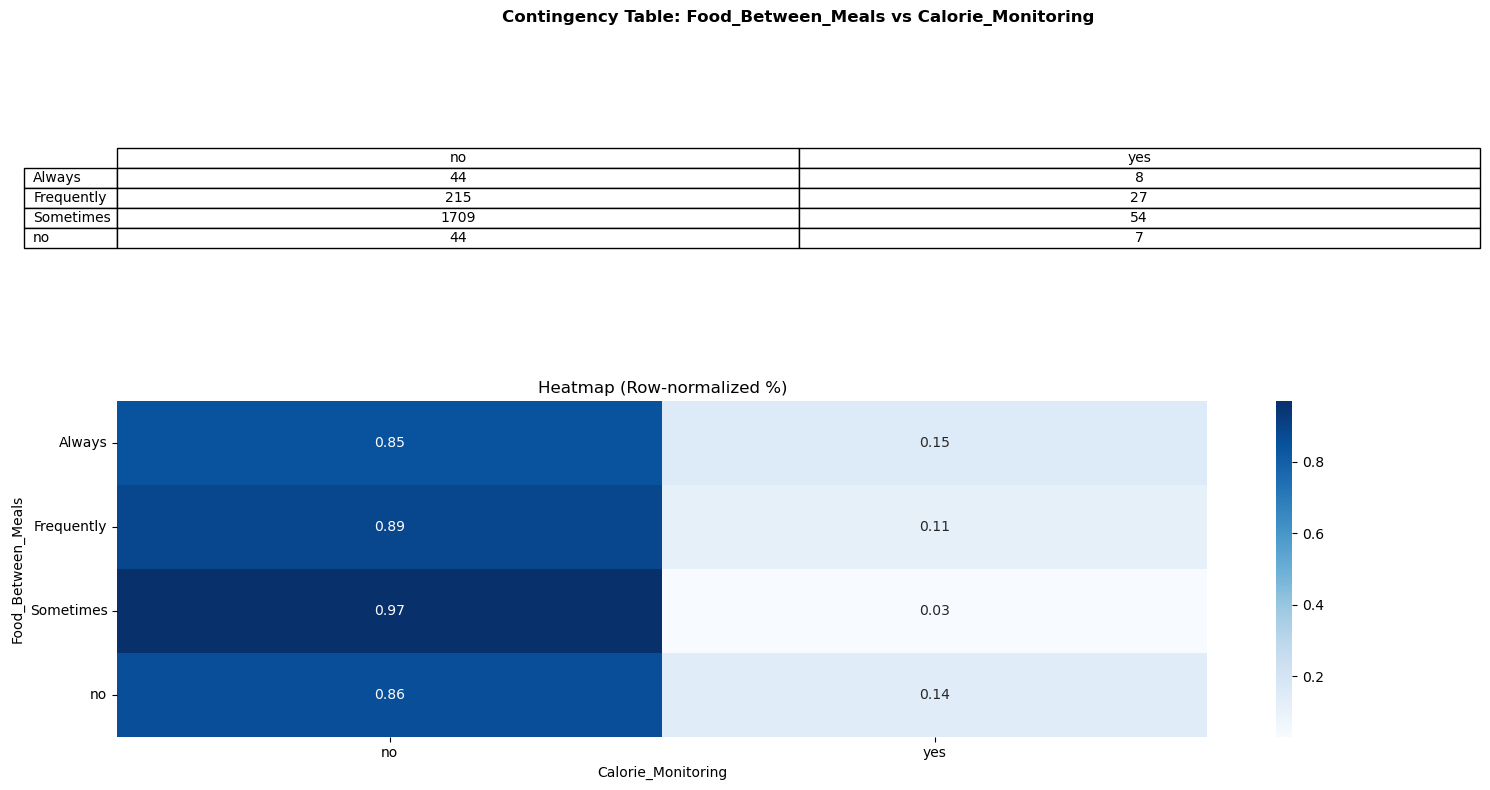

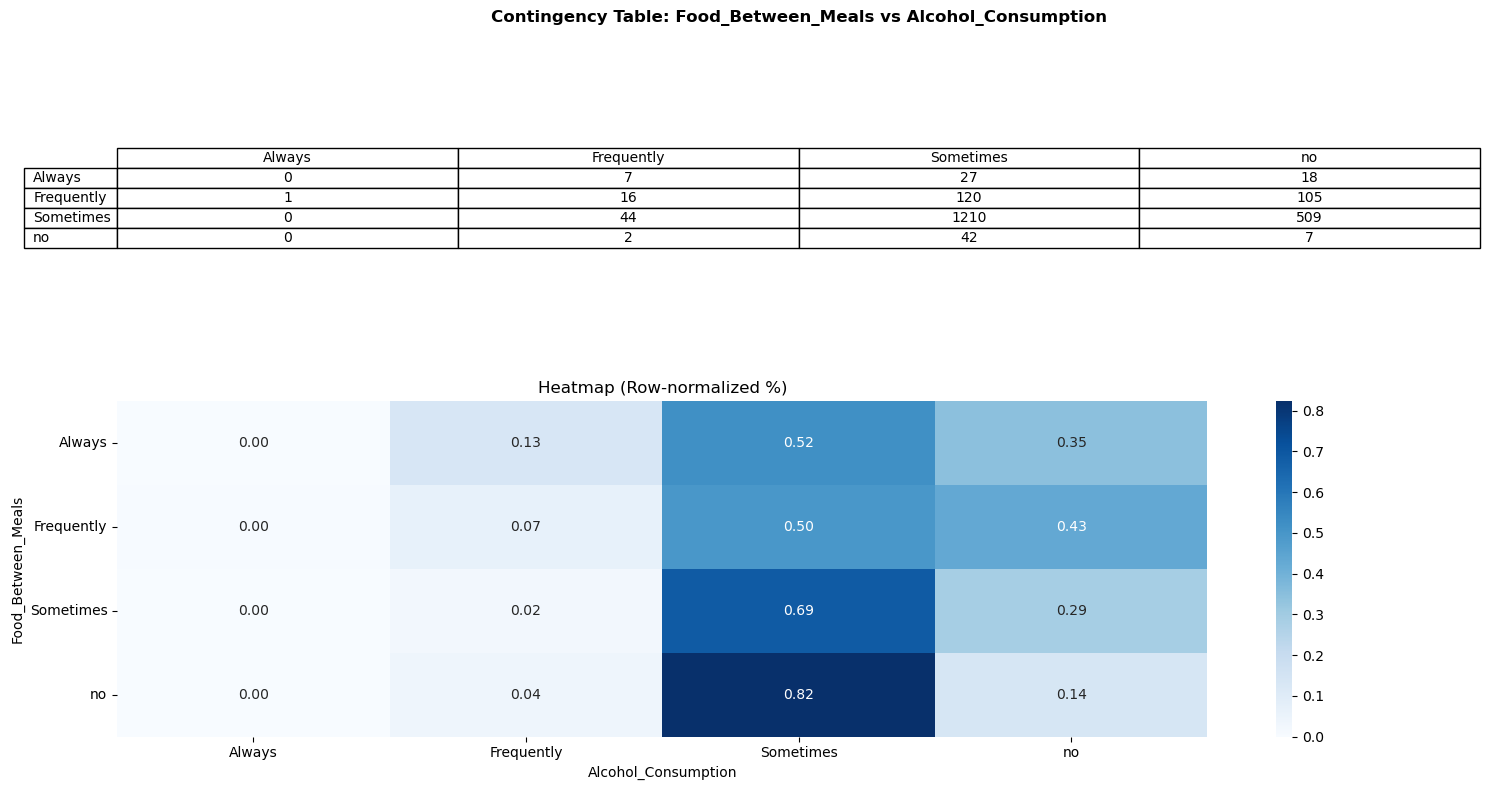

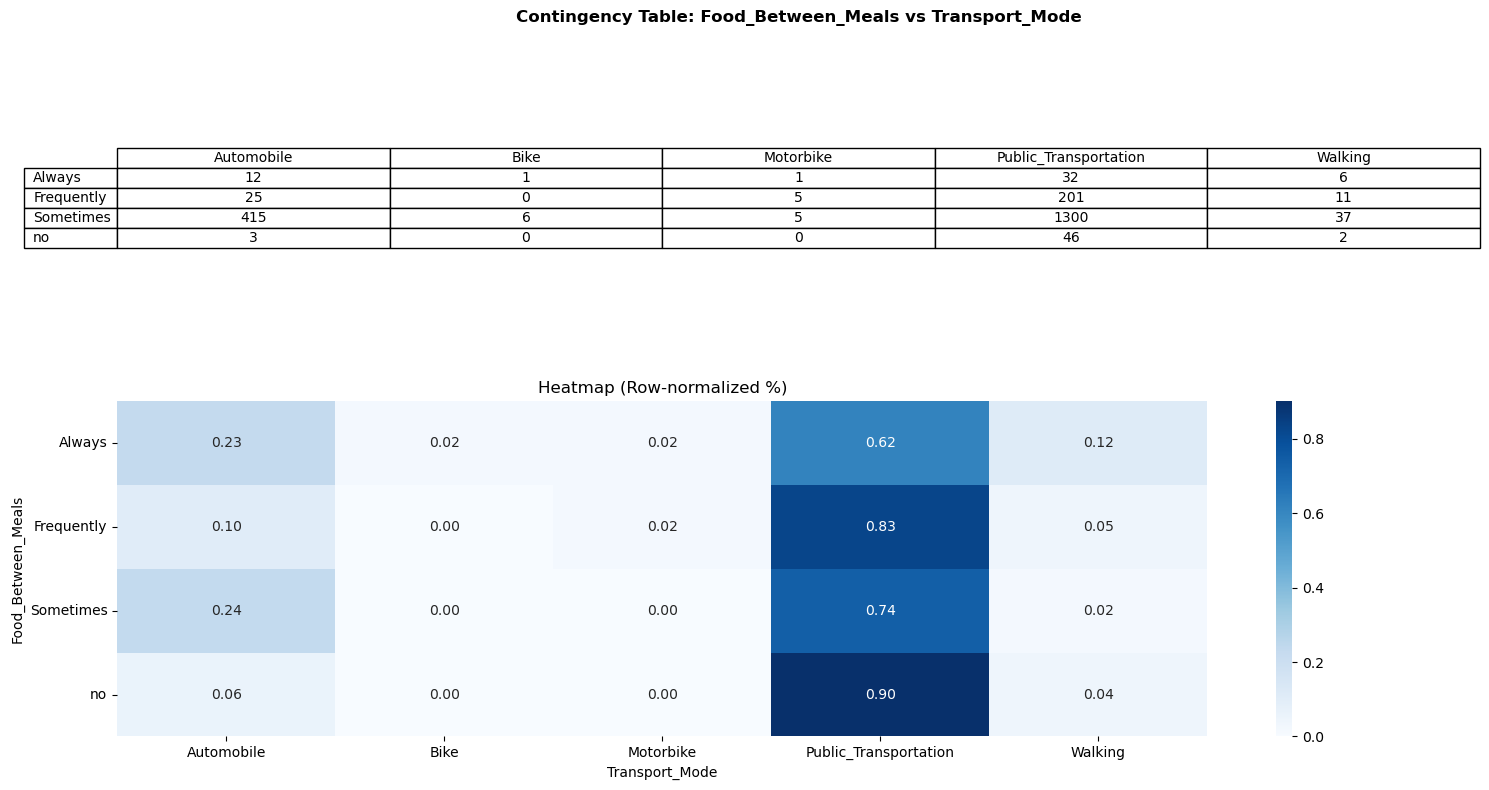

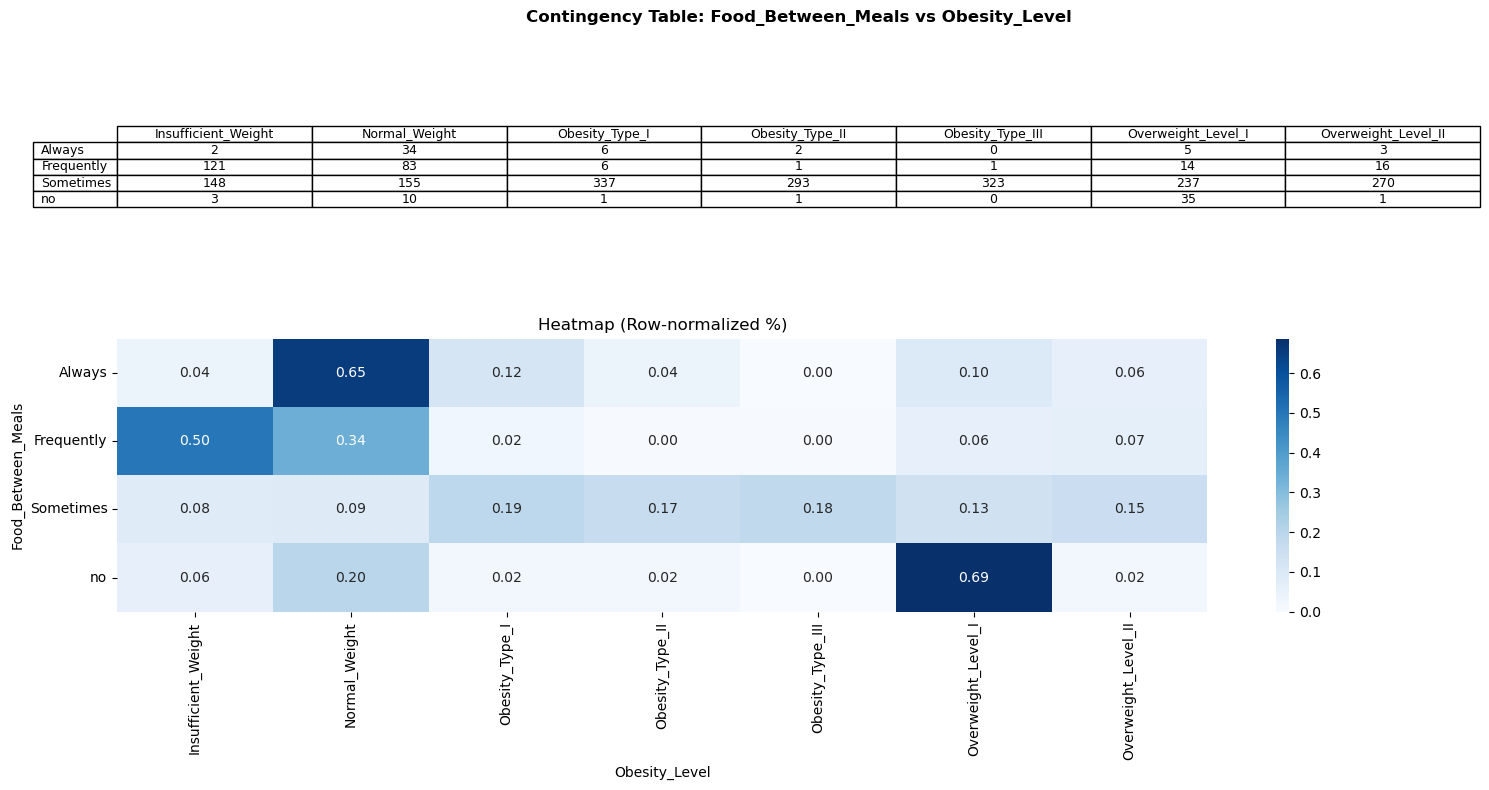

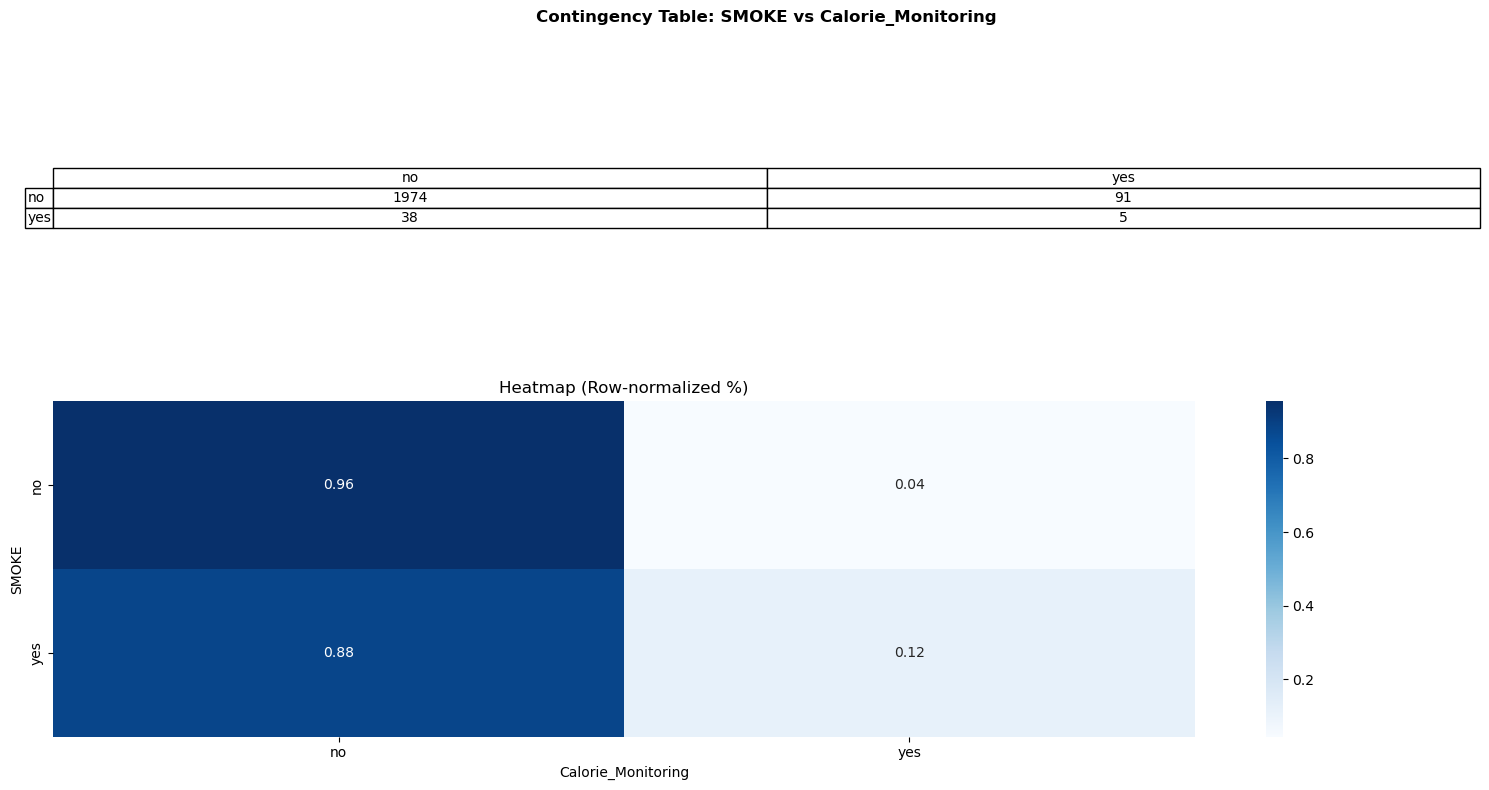

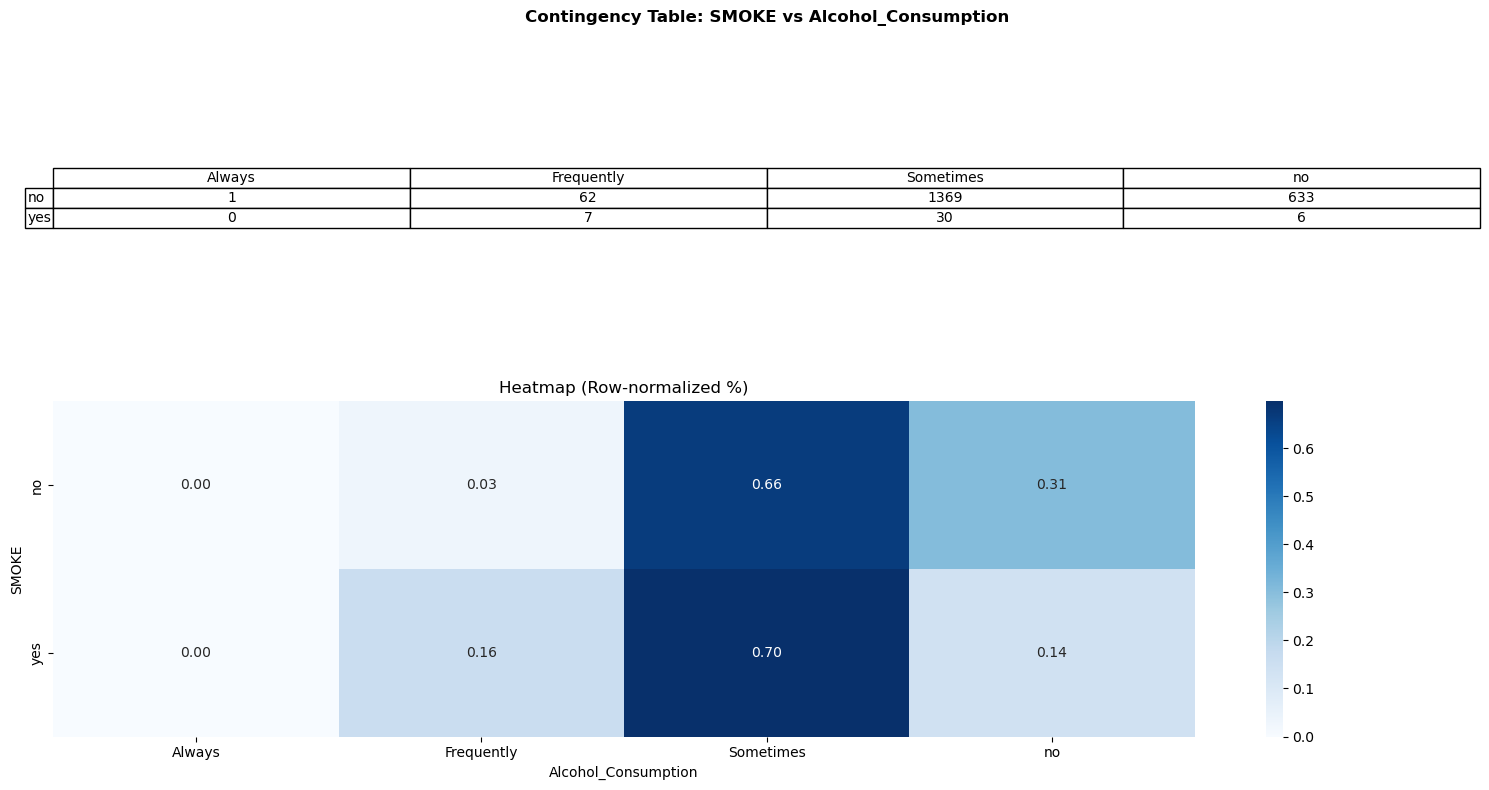

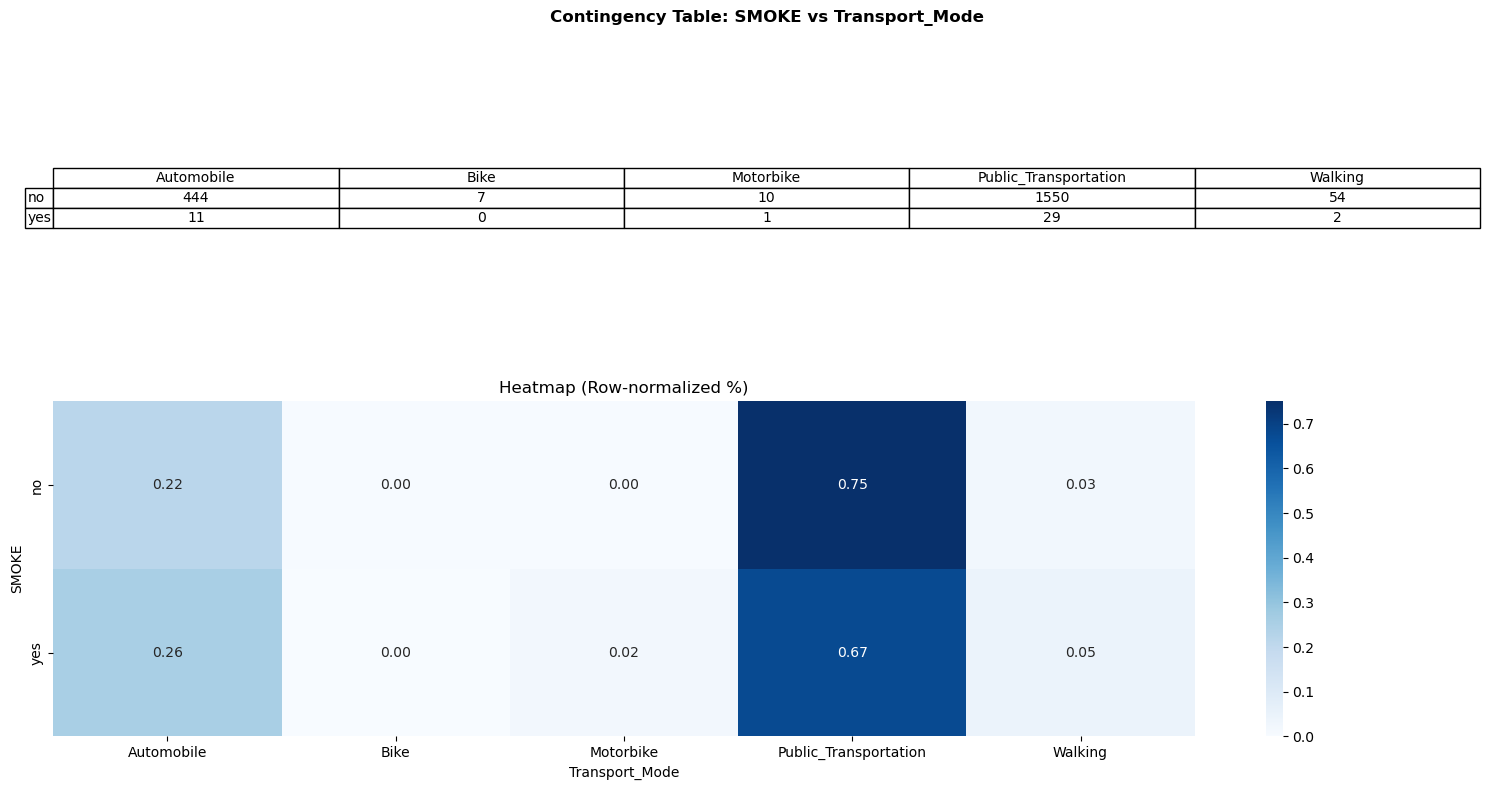

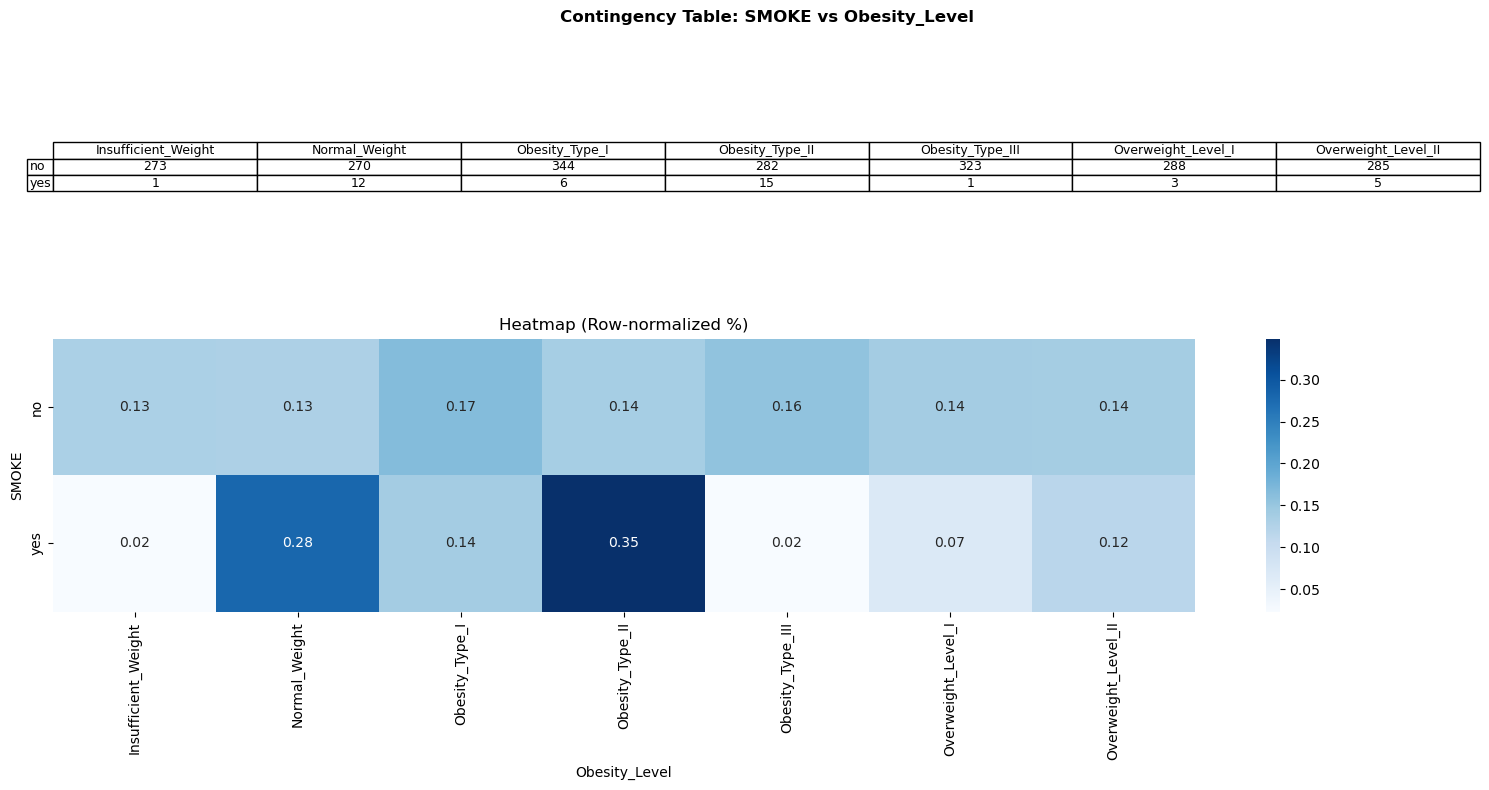

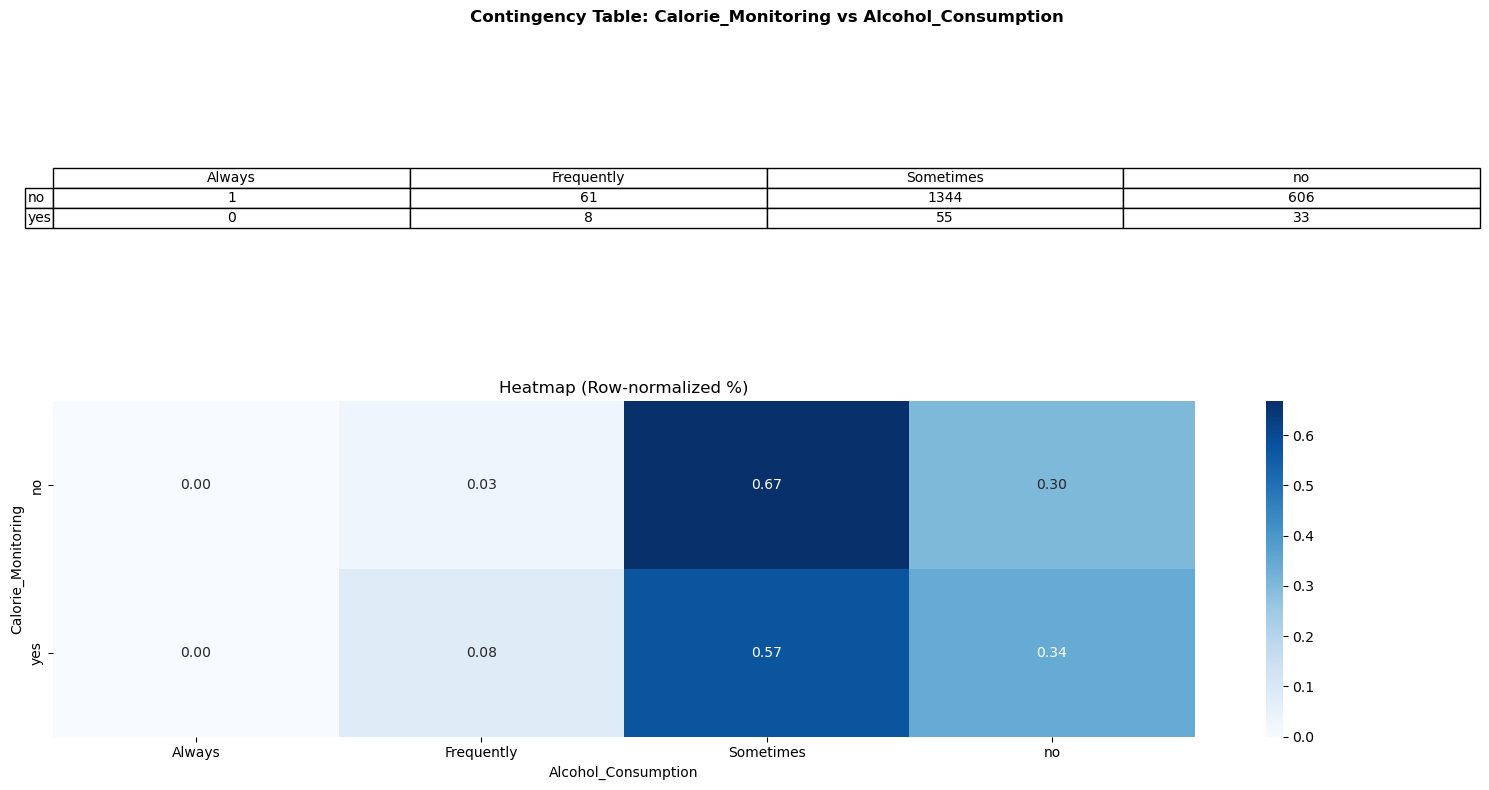

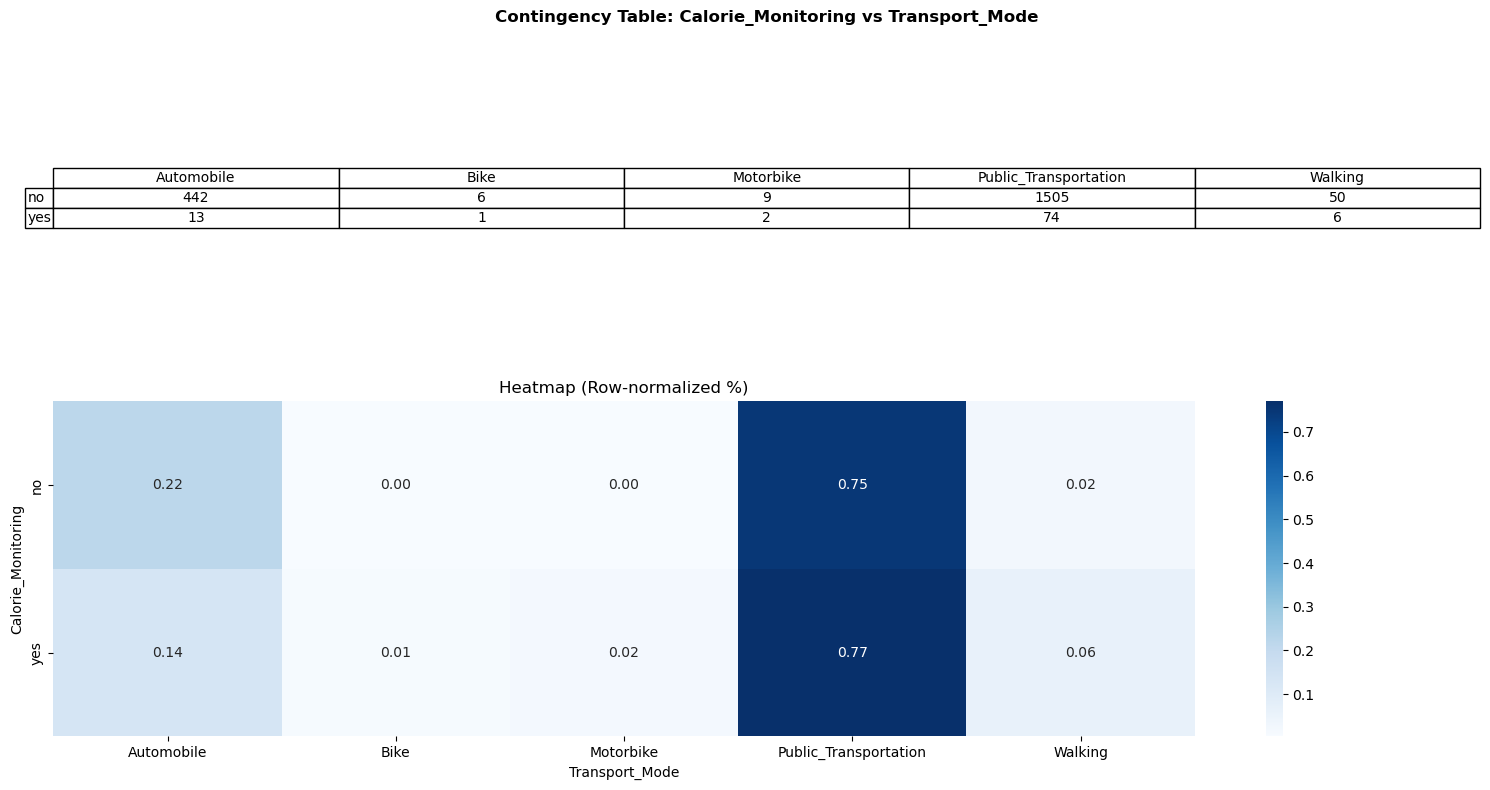

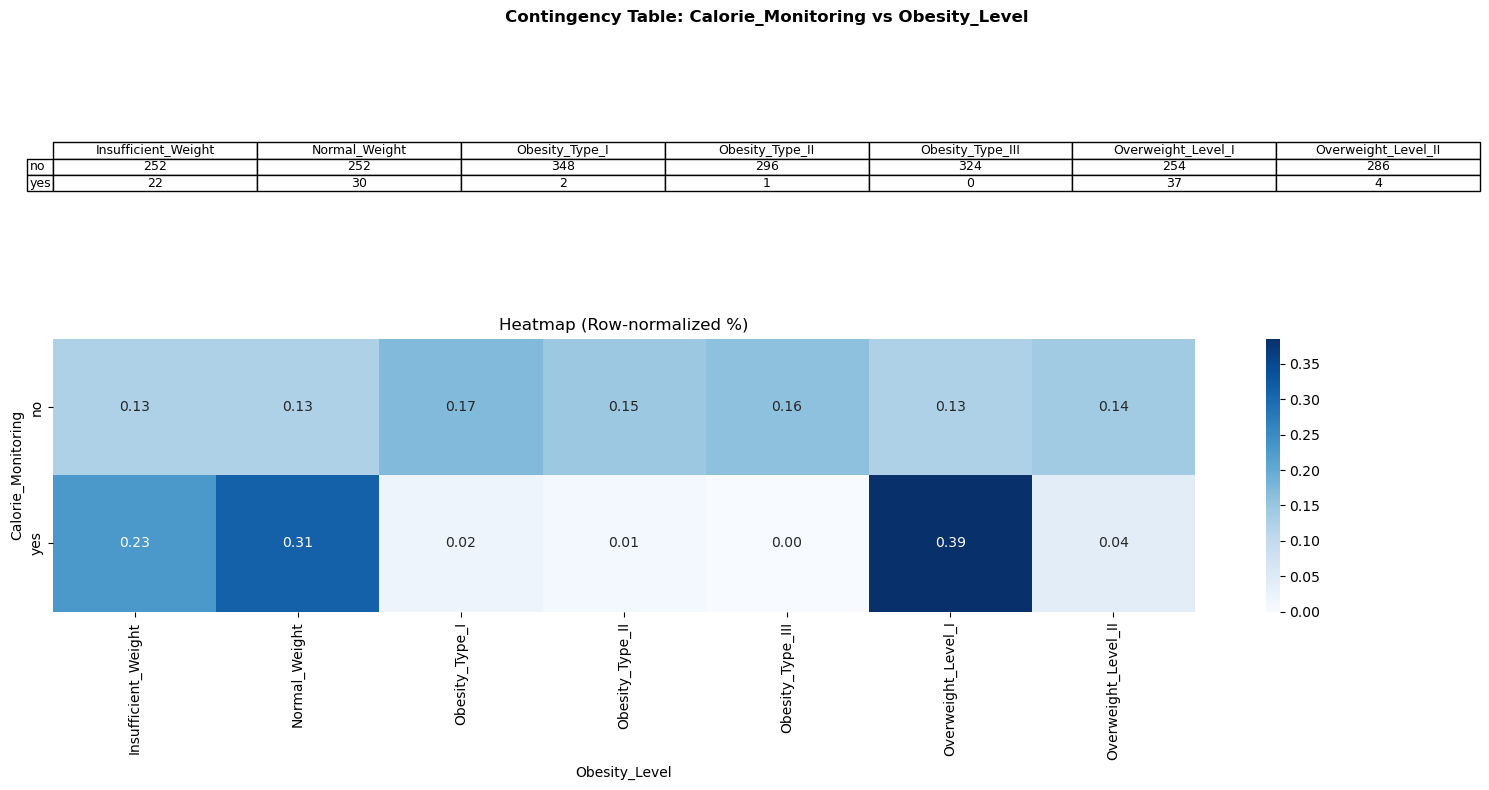

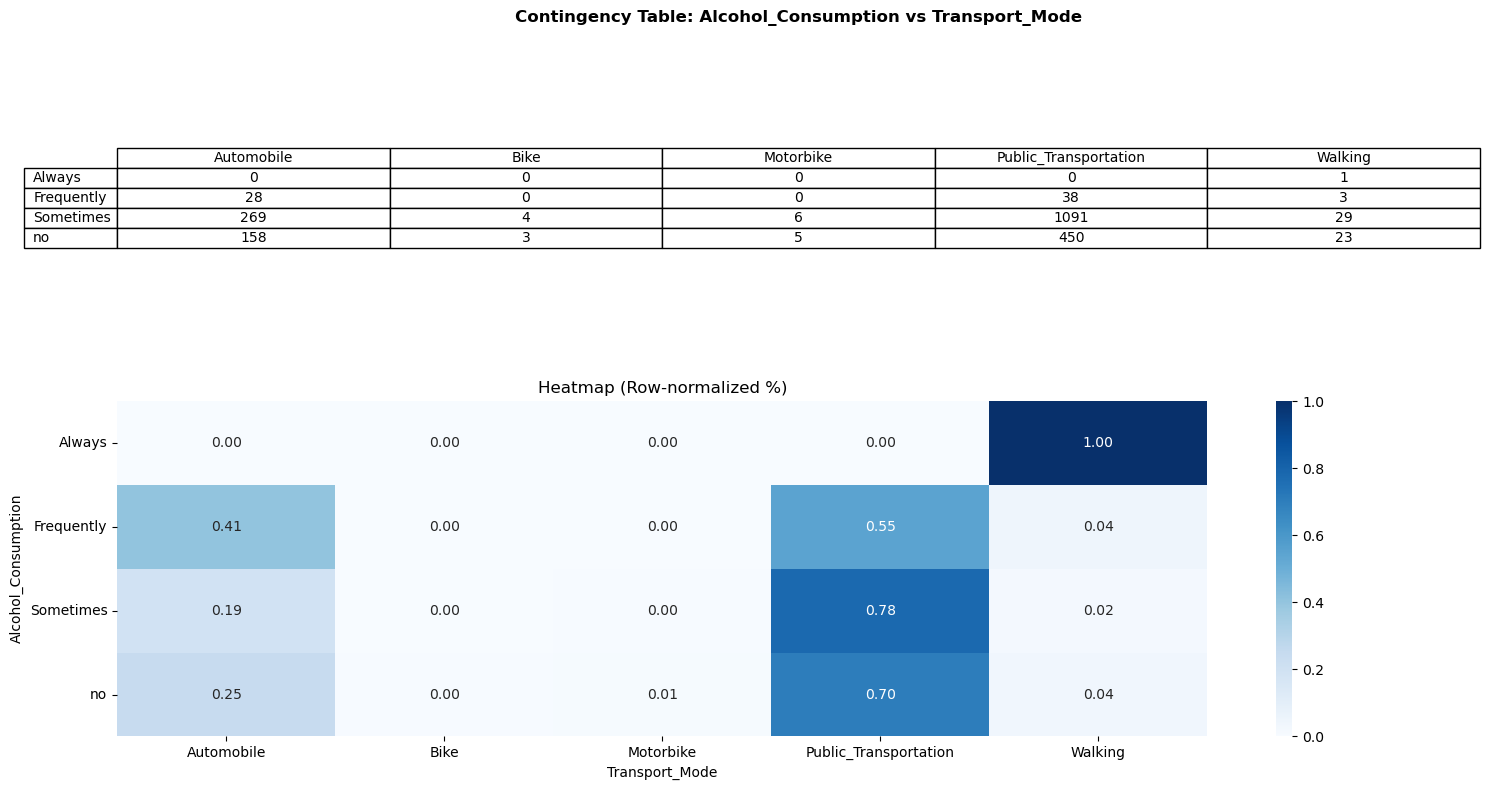

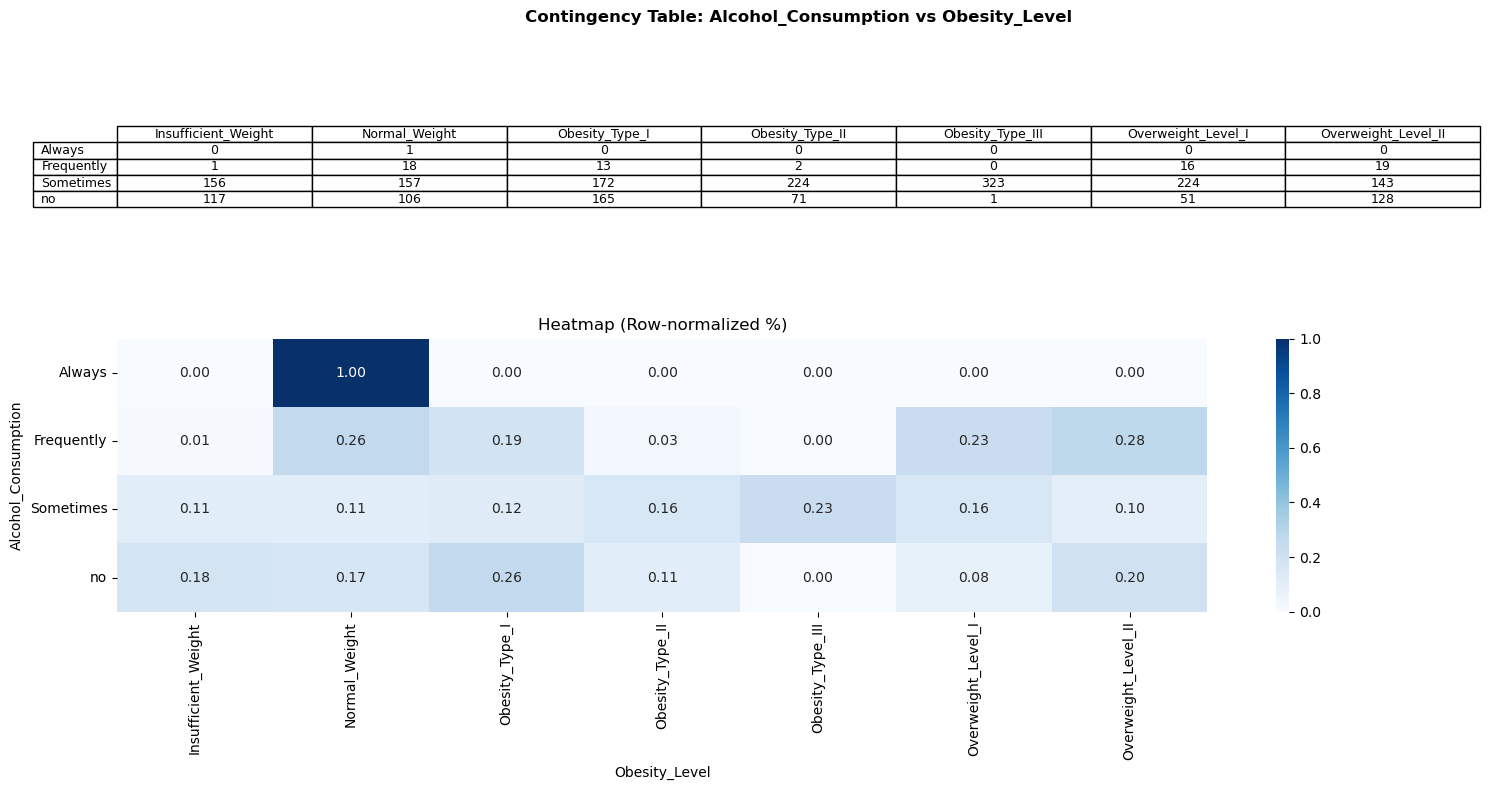

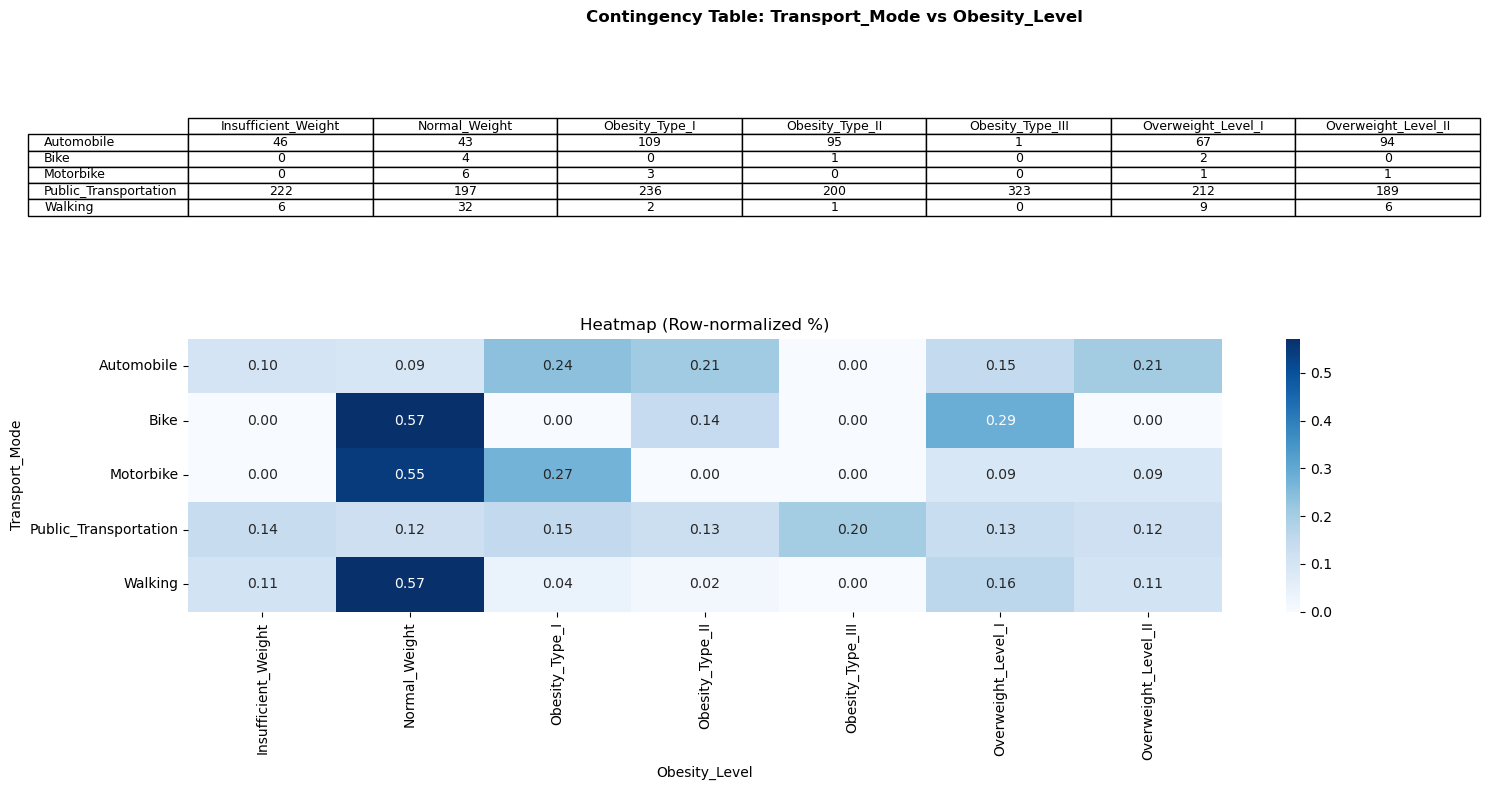

In [31]:
categorical_pairs = [(vars_to_analyze[i], vars_to_analyze[j]) for i in range(len(vars_to_analyze)) for j in range(i+1, len(vars_to_analyze))]

for var1, var2 in categorical_pairs:
    ct_counts = pd.crosstab(dataset_clean[var1], dataset_clean[var2]) #counts
    ct_perc = pd.crosstab(dataset_clean[var1], dataset_clean[var2], normalize='index') #percentages

    fig, (ax_table, ax_heat) = plt.subplots(nrows=2, ncols=1, figsize=(15, 8))
    
    # contingency table
    ax_table.axis('tight')
    ax_table.axis('off')
    the_table = ax_table.table(cellText=ct_counts.values, 
                               rowLabels=ct_counts.index, 
                               colLabels=ct_counts.columns, 
                               cellLoc='center', loc='center')
    the_table.set_fontsize(10) 
    print("\n\n\n\n")
    ax_table.set_title(f"Contingency Table: {var1} vs {var2}", weight='bold')

    # Heatmap of percentages 
    sns.heatmap(ct_perc, annot=True, cmap = "Blues", fmt='.2f', ax=ax_heat, cbar=True)
    ax_heat.set_title(f"Heatmap (Row-normalized %)")
    ax_heat.set_xlabel(var2)
    ax_heat.set_ylabel(var1)

    #  We add space between the two subplots to avoid overlaps between titles and axes
    plt.subplots_adjust(hspace=0.2)
    
    plt.tight_layout()
    plt.show()

To summarize everything in a single graph, we proceed to calculate a global matrix of associations, where each cell contains the value of Cramer's V between the pairs of variables.

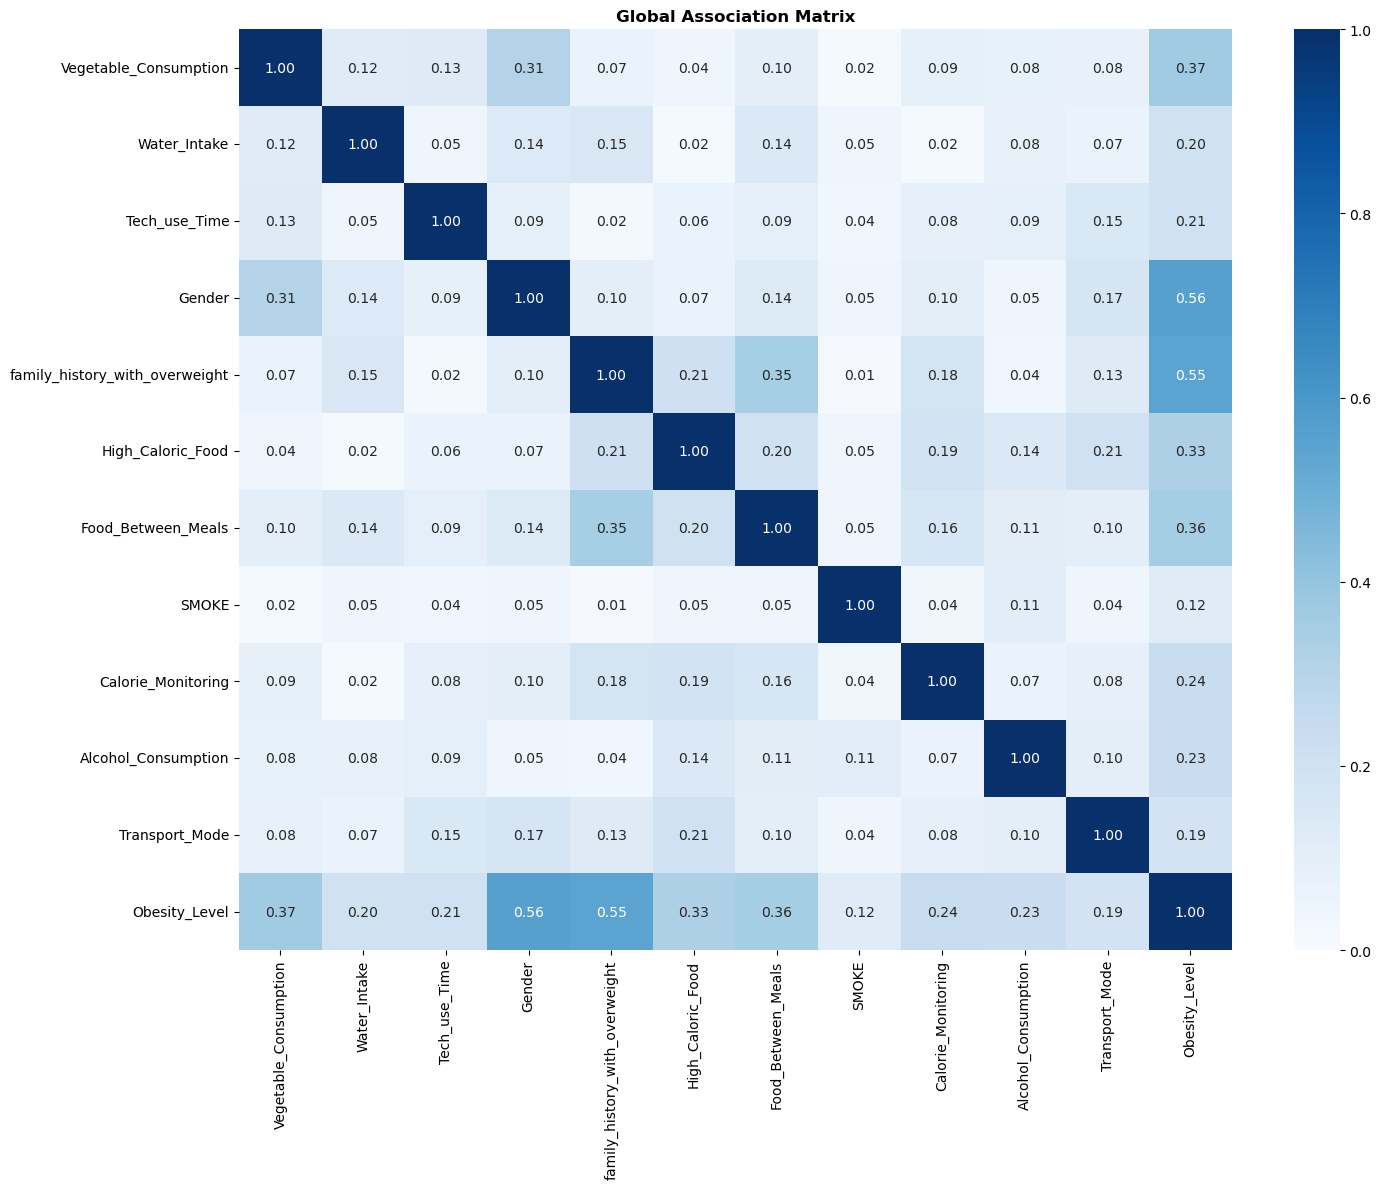

In [32]:
n_vars = len(vars_to_analyze)
empty_matrix = pd.DataFrame(np.zeros((n_vars, n_vars)), columns=vars_to_analyze, index=vars_to_analyze)

for i in range(n_vars):
    for j in range(n_vars):
        if i == j:
            empty_matrix.iloc[i, j] = 1.0
        else:
            ct = pd.crosstab(dataset_clean[vars_to_analyze[i]], dataset_clean[vars_to_analyze[j]])
            chi2 = chi2_contingency(ct)[0]
            n = ct.sum().sum()
            r, k = ct.shape
            empty_matrix.iloc[i, j] = np.sqrt(chi2 / (n * (min(r, k) - 1)))

#mask = np.triu(np.ones_like(empty_matrix, dtype=bool), k=0)

plt.figure(figsize=(15, 12))
sns.heatmap(empty_matrix, annot=True, cmap='Blues', fmt='.2f', vmin=0, vmax=1)
plt.title("Global Association Matrix", weight='bold')
plt.tight_layout()
plt.show()

The factors that appear to most influence the level of obesity concern gender and family history. <br>
These are the strongest predictors overall. On the other hand, the most significant habits concern the consumption of vegetables, snacks between meals and the consumption of high-calorie, caloric food, while we can note how smoking or the means of transport do not particularly influence the obesity rate. <br>
There is also a certain relationship between family history and food consumption between meals, probably indicating that this is a shared habit within families. <br>
To conclude, we can note the existence of a certain difference in vegetable consumption between men and women. 

## 4) PRINCIPAL COMPONENT ANALYSIS AND CLUSTERING
In this phase of the exploratory analysis, we focus on two fundamental aspects: dimensionality reduction and clustering within the dataset.
In order to apply the required statistical techniques, it is necessary to: 

1. Transform categorical variables into numeric format using encoding techniques, such as label encoding or one-hot encoding.

2. Standardize numeric variables so that they have a mean of 0 and a variance of 1, since PCA and clustering are sensitive to different scales of the variables.

In [33]:
# Binary variables - Label Encoding
df = dataset_clean.copy()

cat_bin = ["Gender", "family_history_with_overweight", "High_Caloric_Food", "SMOKE", "Calorie_Monitoring"]
label_encoders = {}

for var in cat_bin:
    le = LabelEncoder()
    df[var] = le.fit_transform(df[var])
    label_encoders[var] = le
    print(f"{var}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
family_history_with_overweight: {'no': np.int64(0), 'yes': np.int64(1)}
High_Caloric_Food: {'no': np.int64(0), 'yes': np.int64(1)}
SMOKE: {'no': np.int64(0), 'yes': np.int64(1)}
Calorie_Monitoring: {'no': np.int64(0), 'yes': np.int64(1)}


In [34]:
multi_cat = ["Transport_Mode"]
print(f"\nSize before one-hot encoding: {df.shape}")
df = pd.get_dummies(df, columns=multi_cat, prefix=multi_cat, dtype = int)
print(f"\nSize after one-hot encoding: {df.shape}")


Size before one-hot encoding: (2108, 17)

Size after one-hot encoding: (2108, 21)


In [35]:
# Ordinal variables Encoding
ordinal_var = {
    "Food_Between_Meals": ["no", "Sometimes", "Frequently", "Always"],
    "Alcohol_Consumption": ["no", "Sometimes", "Frequently", "Always"],
    "Obesity_Level": ["Insufficient_Weight", "Normal_Weight", "Overweight_Level_I", "Overweight_Level_II", "Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"]
}

for var, order in ordinal_var.items():
    df[var] = df[var].astype("category")
    df[var] = df[var].cat.set_categories(order, ordered=True)
    df[var] = df[var].cat.codes
    
display(df.head())

,Gender,Age,Height,Weight,family_history_with_overweight,High_Caloric_Food,Vegetable_Consumption,Main_Meals_Per_Day,Food_Between_Meals,SMOKE,...,Calorie_Monitoring,Physical_Activity_Frequency,Tech_use_Time,Alcohol_Consumption,Obesity_Level,Transport_Mode_Automobile,Transport_Mode_Bike,Transport_Mode_Motorbike,Transport_Mode_Public_Transportation,Transport_Mode_Walking
0,0,21,162,64,1,0,2,3,1,0,...,0,0,1,0,1,0,0,0,1,0
1,0,21,152,56,1,0,3,3,1,1,...,1,3,0,1,1,0,0,0,1,0
2,1,23,180,77,1,0,2,3,1,0,...,0,2,1,2,1,0,0,0,1,0
3,1,27,180,87,0,0,3,3,1,0,...,0,2,0,2,2,0,0,0,0,1
4,1,22,178,90,0,0,2,1,1,0,...,0,0,0,1,3,0,0,0,1,0


The inclusion of the target variable during the application of PCA would constitute a methodological error, since PCA is an unsupervised algorithm which, if it included the target, would treat it as any other independent feature. <br> This would mean that the data transformation would also seek to maximise the variance of the target variable itself, contaminating the dimensional reduction process.

In [36]:
# Separation between features and target var
print("\nDATA PREPARATION FOR PCA:")

var_target = "Obesity_Level"
features_pca = [var for var in df.columns if var != var_target]

X = df[features_pca].copy()
y = df[var_target].copy()

print("\nDATA PREPARATION FOR PCA:")
print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")


DATA PREPARATION FOR PCA:

DATA PREPARATION FOR PCA:
Shape X: (2108, 20)
Shape y: (2108,)


In [37]:
#Standardization of numerical variables
print("\nSCALING OF THE FEATURES:\n")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nStatistics before scaling:")
print(pd.DataFrame(X, columns=features_pca).describe().loc[["mean", "std"]].round(2))
print("\n\n\n\n")
print("\nStatistics after scaling:")
print(pd.DataFrame(X_scaled, columns=features_pca).describe().loc[["mean", "std"]].round(2))


SCALING OF THE FEATURES:


Statistics before scaling:
      Gender    Age  Height  Weight  family_history_with_overweight  \
mean    0.51  24.30  170.17   86.61                            0.82   
std     0.50   6.34    9.33   26.20                            0.39   

      High_Caloric_Food  Vegetable_Consumption  Main_Meals_Per_Day  \
mean               0.88                   2.42                2.69   
std                0.32                   0.59                0.81   

      Food_Between_Meals  SMOKE  Water_Intake  Calorie_Monitoring  \
mean                1.14   0.02          2.02                0.05   
std                 0.47   0.14          0.69                0.21   

      Physical_Activity_Frequency  Tech_use_Time  Alcohol_Consumption  \
mean                         1.01           0.67                 0.73   
std                          0.90           0.67                 0.52   

      Transport_Mode_Automobile  Transport_Mode_Bike  \
mean                       0.22     

To simplify the analysis, we applied Principal Component Analysis, which allows us to reduce the number of dimensions by projecting the data along the directions of maximum variance (the principal components).

In [38]:
print("\nPRINCIPAL COMPONENT ANALYSIS (PCA):")
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Analysis of explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Explained variance by component:")
for i, (var, cum_var) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f"PC{i+1}: {var:.4f} ({cum_var:.4f} cumulative)")


PRINCIPAL COMPONENT ANALYSIS (PCA):
Explained variance by component:
PC1: 0.1383 (0.1383 cumulative)
PC2: 0.1140 (0.2523 cumulative)
PC3: 0.0897 (0.3420 cumulative)
PC4: 0.0670 (0.4090 cumulative)
PC5: 0.0568 (0.4659 cumulative)
PC6: 0.0549 (0.5208 cumulative)
PC7: 0.0522 (0.5730 cumulative)
PC8: 0.0509 (0.6239 cumulative)
PC9: 0.0494 (0.6732 cumulative)
PC10: 0.0473 (0.7205 cumulative)
PC11: 0.0446 (0.7651 cumulative)
PC12: 0.0422 (0.8073 cumulative)
PC13: 0.0393 (0.8466 cumulative)
PC14: 0.0380 (0.8847 cumulative)
PC15: 0.0340 (0.9187 cumulative)
PC16: 0.0309 (0.9496 cumulative)
PC17: 0.0213 (0.9709 cumulative)
PC18: 0.0181 (0.9890 cumulative)
PC19: 0.0110 (1.0000 cumulative)
PC20: 0.0000 (1.0000 cumulative)


MAIN RESULT:
To explain at least 80% of the variance, we need 12 main components
Cumulative variance with 12 components: 80.73%


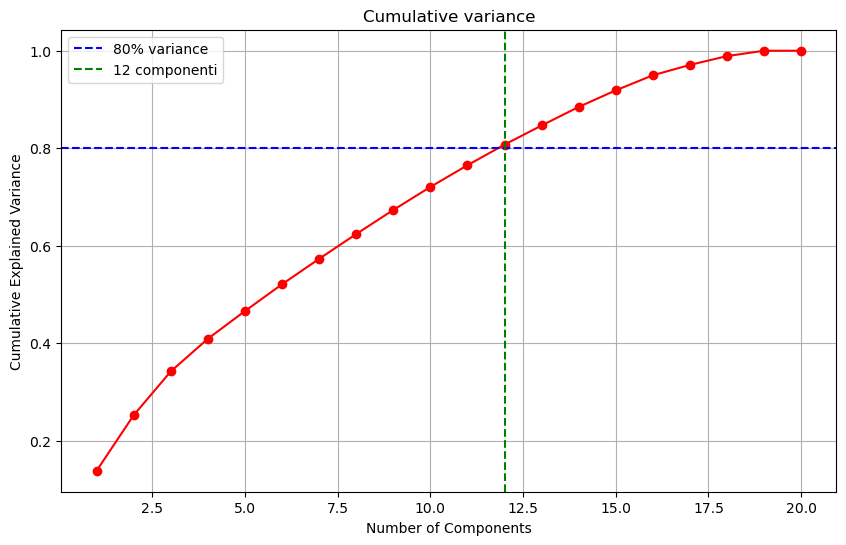

In [39]:
# Detailed analysis for 80%
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1

print(f"MAIN RESULT:")

print(f"To explain at least 80% of the variance, we need {n_components_80} main components")
print(f"Cumulative variance with {n_components_80} components: {cumulative_variance[n_components_80-1]:.2%}")

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
feature_names = X.columns.tolist()
obesity_categories = dataset_clean["Obesity_Level"]

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, "ro-")
plt.axhline(y=0.80, color="b", linestyle="--", label="80% variance")
plt.axvline(x=n_components_80, color="g", linestyle="--", label=f'{n_components_80} componenti')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative variance")
plt.legend()
plt.grid(True)
plt.show()

Effective reduction: **-40%** dimensions while maintaining **80%** information

The analysis shows that the data cannot be reduced to a few dimensions without a substantial loss of information.<br> 
The first two principal components capture only 25% of the total variability, while 12 components are needed to achieve 80% explained variance.
<br><br><br><br>
To interpret the principal components we construct a **Correlation Circle**. and a **Biplot**.<br>
The first shows how the original variables are correlated with the first two main components, while the second allows to interpret the distribution of individuals with respect to the variables.

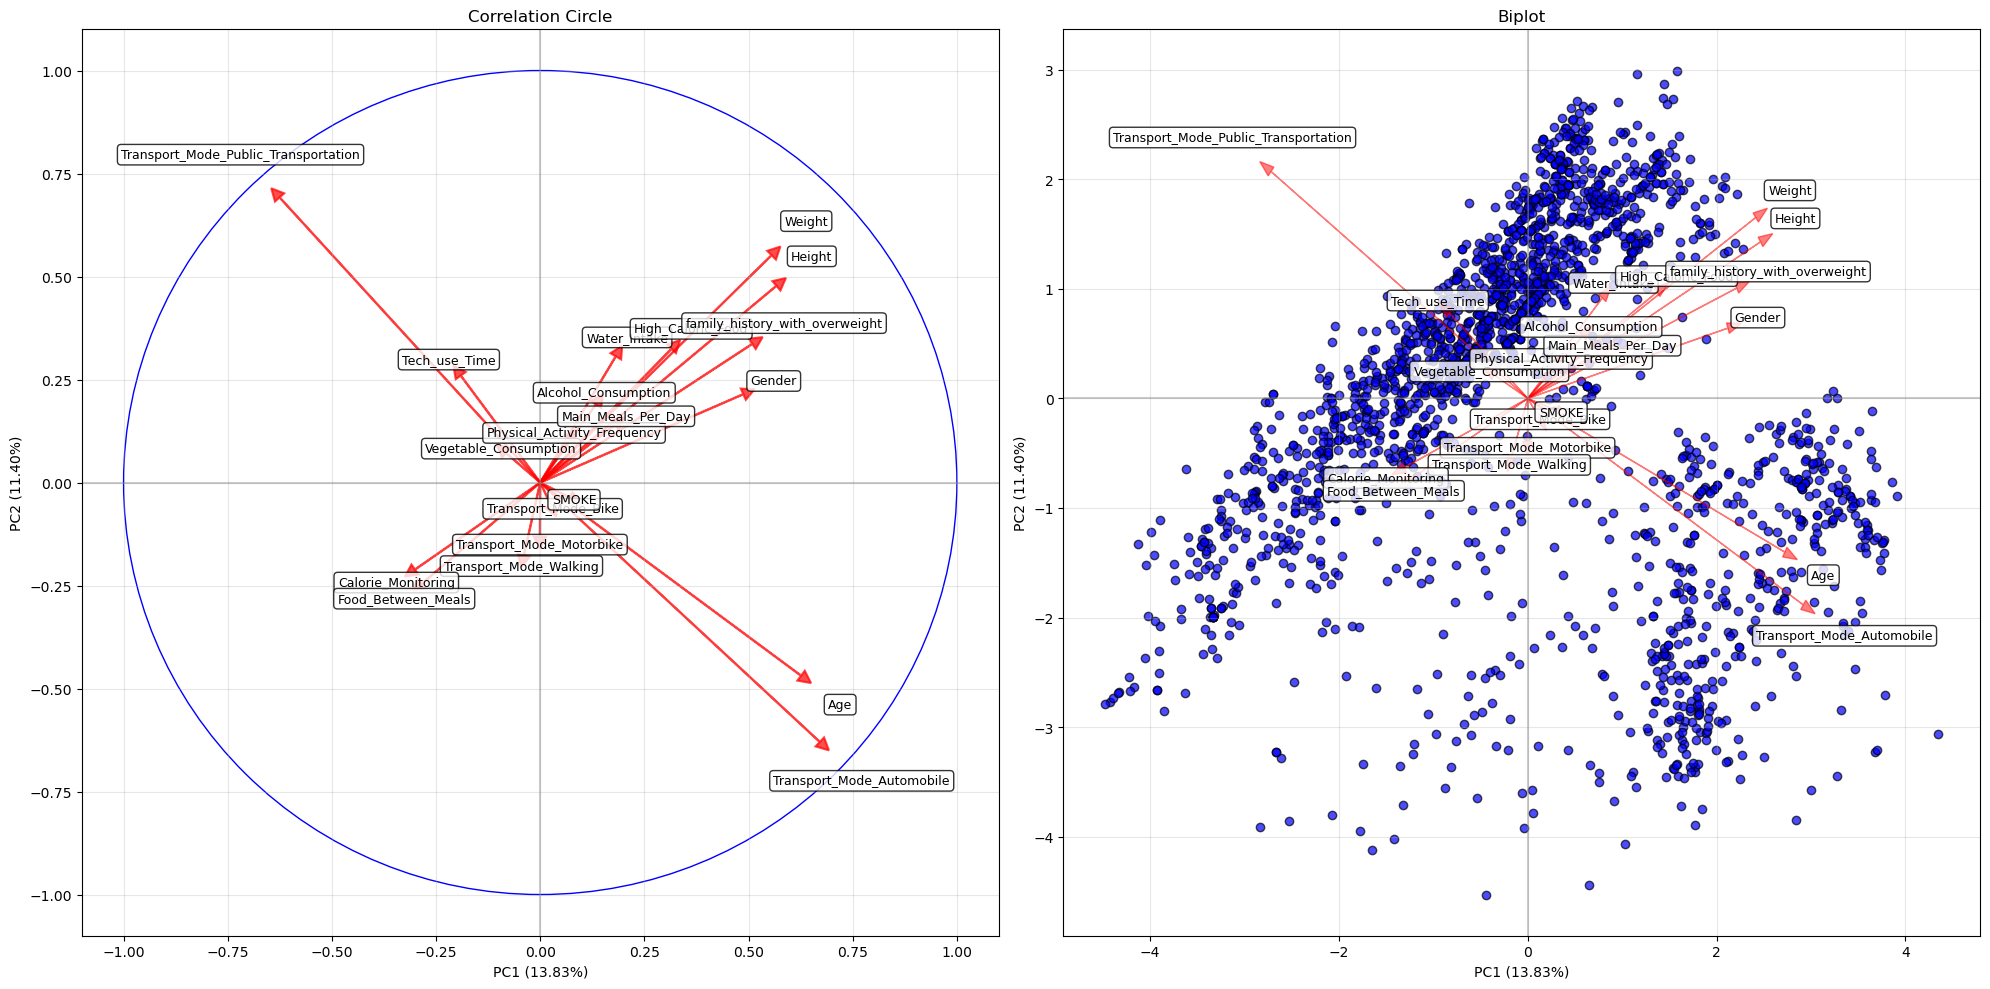

In [40]:
plt.figure(figsize=(20,10))
ax1 = plt.subplot(1, 2, 1)

# Draw the unit circle
circle = plt.Circle((0, 0), 1, color="blue", fill=False, linestyle="-", alpha=1)
ax1.add_artist(circle)

loading_magnitudes = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
top_indices = np.argsort(loading_magnitudes)

# Plot loading vectors
for i in top_indices:
    x, y = loadings[i, 0], loadings[i, 1]
    feature_name = feature_names[i]
    
    ax1.arrow(0, 0, x, y, color= "red", alpha=0.7, head_width=0.03, head_length=0.03, linewidth=1.5)
    ax1.text(x * 1.15, y * 1.15, feature_name, fontsize=9, ha="center", va="center", color="black", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# Ax settings
ax1.set_xlim(-1.1, 1.1)
ax1.set_ylim(-1.1, 1.1)
ax1.axhline(0, color="gray", alpha=0.4)
ax1.axvline(0, color="gray", alpha=0.4)
ax1.set_title("Correlation Circle")
ax1.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
ax1.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
ax1.grid(alpha=0.3)


ax2 = plt.subplot(1, 2, 2)

# Scatter plot of PCA scores (observations)
ax2.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, color="blue", edgecolor="black")

# Add variable loading vectors on the same plot
for i in top_indices:
    x, y = loadings[i, 0] * max(X_pca[:,0]), loadings[i, 1] * max(X_pca[:,1])  # rescale loadings
    feature_name = feature_names[i]
   
    ax2.arrow(0, 0, x, y, color = "red", alpha=0.5, head_width=0.1)
    ax2.text(x * 1.15, y * 1.15, feature_name, fontsize=9, ha="center", va="center", color= "black",bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

ax2.set_title("Biplot")
ax2.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
ax2.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
ax2.axhline(0, color="gray", alpha=0.4)
ax2.axvline(0, color="gray", alpha=0.4)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

PC1 is dominated by physical and biological variables while PC2 mainly discriminates between lifestyle and mobility. 
<br><br>
There is a strong positive correlation between Weight, Height, family_history_with_overweight, and High_Caloric_Food. These variables move together, suggesting that family predisposition and handed down habits are closely linked to current physical structure.
<br><br>
An almost perfect negative correlation is observed between car use and public transport use. Age is strongly associated with car use, indicating that younger subjects in the dataset tend to prefer public transportation or other means.
<br><br>
Variables such as Weight, Height, Age, Transport_Mode_Automobile, and Transport_Mode_Public_Transportation are well represented by the first two principal components, unlike the others which have much shorter arrows. 
<br><br>
The Biplot shows two fairly clear groupings, one containing most individuals, while the second containing mostly older people who use the car to get around.
<br><br><br><br>
Since the variance explained by the first two principal components is only about 25%, we thought we'd look at the third and fourth, so we could recover some information that would otherwise be lost.

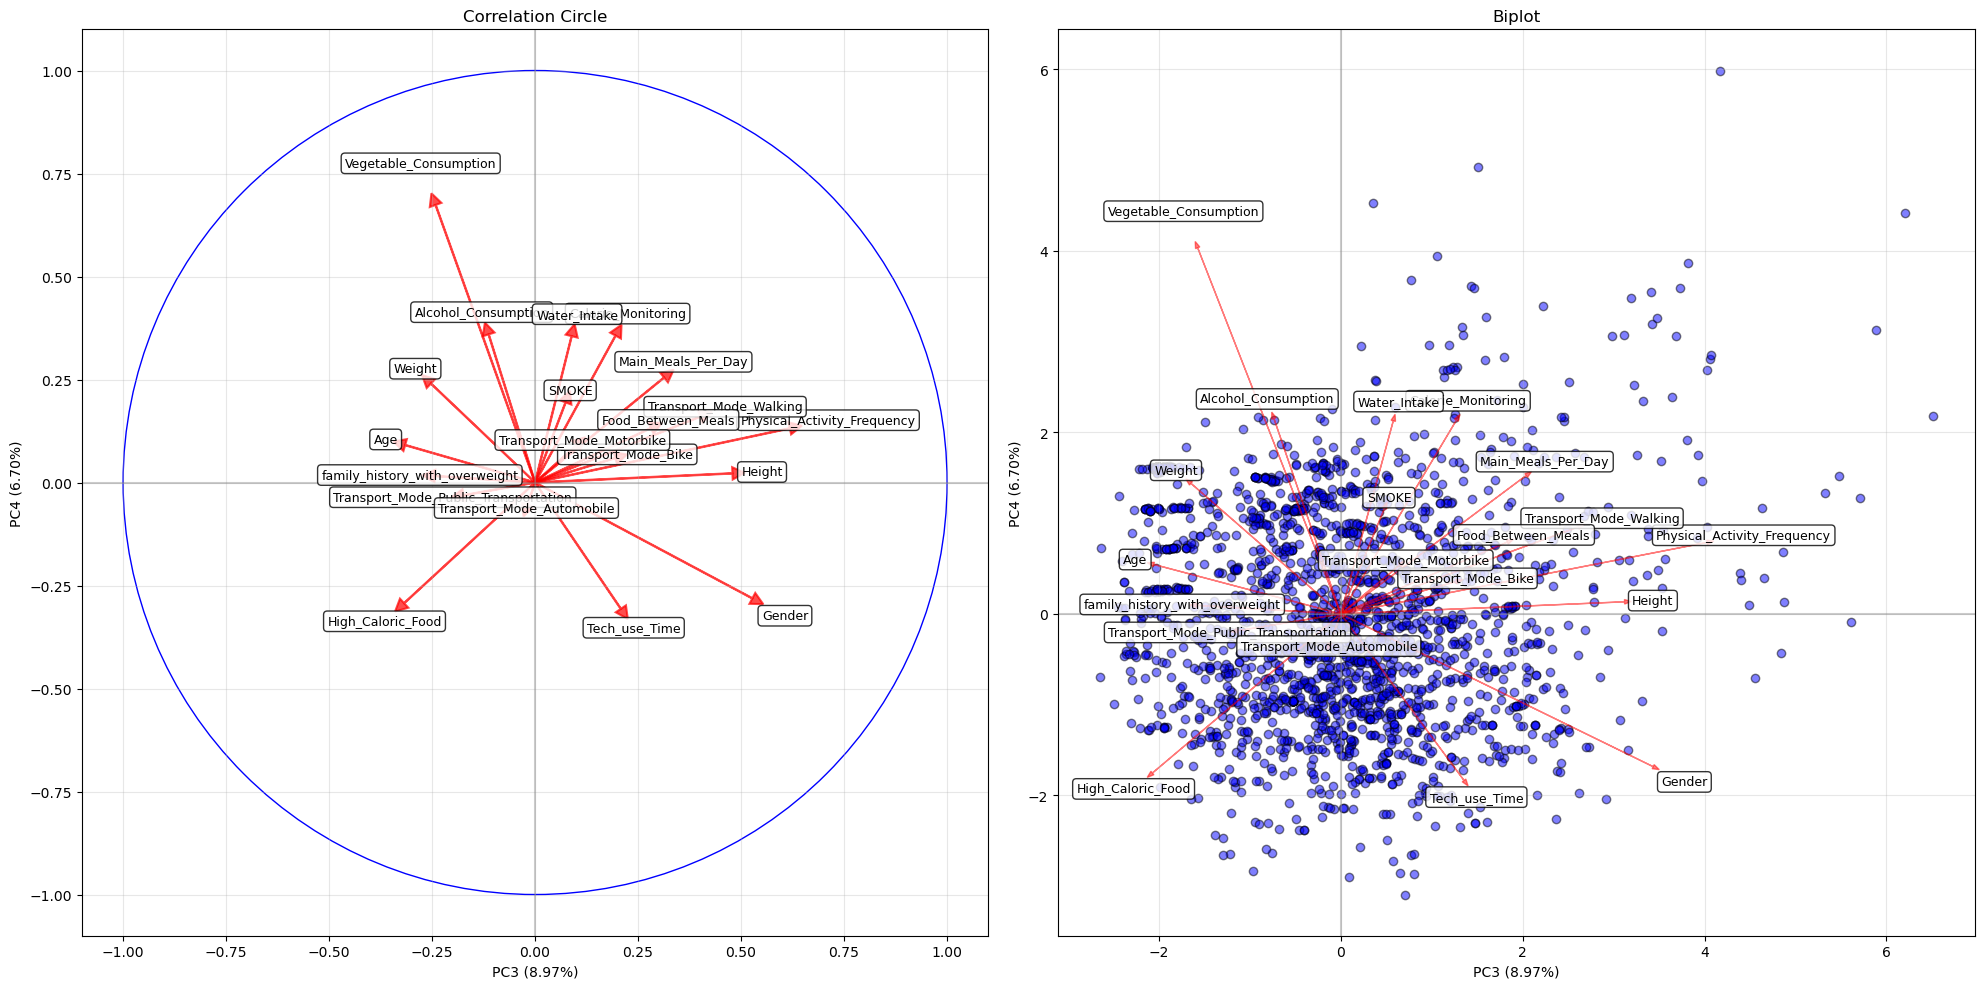

In [41]:
plt.figure(figsize=(20, 10))

ax1 = plt.subplot(1, 2, 1)
circle = plt.Circle((0, 0), 1, color="blue", fill=False, linestyle="-", alpha=1)
ax1.add_artist(circle)

loading_magnitudes = np.sqrt(loadings[:, 2]**2 + loadings[:, 3]**2)
top_indices = np.argsort(loading_magnitudes)[::-1]

for i in top_indices:
    x, y = loadings[i, 2], loadings[i, 3] 
    ax1.arrow(0, 0, x, y, color="red", alpha=0.7, head_width=0.03, head_length=0.03, linewidth=1.5)
    ax1.text(x * 1.15, y * 1.15, feature_names[i], fontsize=9, ha="center", va="center", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

ax1.set_xlim(-1.1, 1.1)
ax1.set_ylim(-1.1, 1.1)
ax1.set_aspect('equal') 
ax1.axhline(0, color="gray", alpha=0.4)
ax1.axvline(0, color="gray", alpha=0.4)
ax1.set_title("Correlation Circle")
ax1.set_xlabel(f"PC3 ({pca.explained_variance_ratio_[2]:.2%})")
ax1.set_ylabel(f"PC4 ({pca.explained_variance_ratio_[3]:.2%})")
ax1.grid(alpha=0.3)

ax2 = plt.subplot(1, 2, 2)
ax2.scatter(X_pca[:, 2], X_pca[:, 3], alpha=0.5, color="blue", edgecolor="black")

for i in top_indices:
    x, y = loadings[i, 2] * max(X_pca[:,2]), loadings[i, 3]* max(X_pca[:,3])
    ax2.arrow(0, 0, x, y, color="red", alpha=0.5, head_width=0.05)
    ax2.text(x * 1.1, y * 1.1, feature_names[i], fontsize=9, ha="center", va="center", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

ax2.set_title("Biplot")
ax2.set_xlabel(f"PC3 ({pca.explained_variance_ratio_[2]:.2%})") 
ax2.set_ylabel(f"PC4 ({pca.explained_variance_ratio_[3]:.2%})") 
ax2.axhline(0, color="gray", alpha=0.4)
ax2.axvline(0, color="gray", alpha=0.4)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Principal component analysis of PC3 and PC4 highlights secondary, less dominant patterns in the data.<br>
PC3 appears to be mainly linked to some physical and behavioral aspects of the subjects.<br>
PC4 is strongly characterized by eating habits and some lifestyle habits. <br>
Vegetable_Consumption is very PC4 related, pointing strongly upward, unlike High_Caloric_Food. <br>
This suggests a split between a healthy diet and a high-caloric one.<br>
However, unlike the first principal components, these do not produce a clear separation between subjects, indicating that these factors influence the overall variability of the dataset in a more nuanced way.
<br><br><br>

### CLUSTERING:



### K-Means
Although achieving 80% variance requires the inclusion of 12 principal components, the first 4 were chosen for the K-means clustering phase. <br>
The inclusion of additional components, while increasing the retained information, introduced a level of noise that degraded the quality of the clusters, making the boundaries between the groups less defined.

In [42]:
df_pca = pd.DataFrame(X_pca[:, :4], columns=["PC1", "PC2", "PC3", "PC4"])
display(df_pca.head())

,PC1,PC2,PC3,PC4
0,-1.943402,-0.641929,-0.193908,-0.474387
1,-2.434553,-1.337080,1.511201,4.923748
2,-0.008624,0.977320,1.819580,0.664771
3,0.372038,-1.611621,3.690247,3.066815
4,-1.112858,-0.317927,0.481050,-0.290942


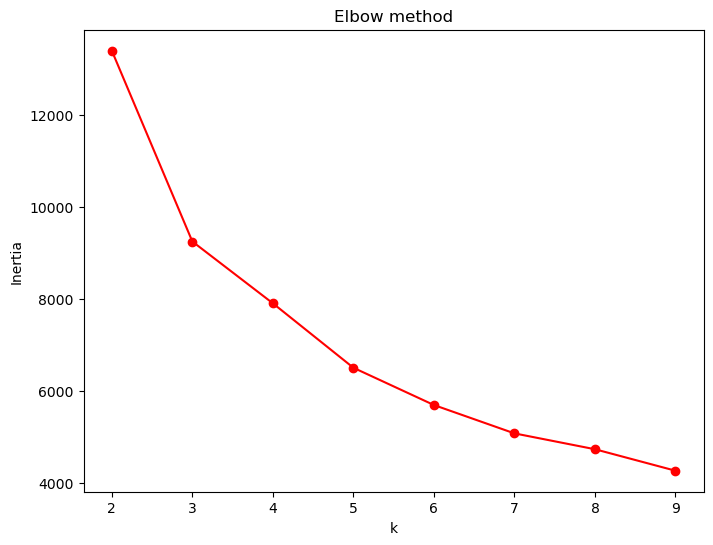

In [43]:
#ELBOW METHOD
inertia = []
K = range(2,10)

for k in K:
    km = KMeans(n_clusters=k, init = "k-means++", random_state=42)
    km.fit(df_pca)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,6))
plt.plot(K, inertia, "ro-")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.show()

In [44]:
for k in K:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42)
    clusters = kmeans.fit_predict(df_pca)
    silhouette_avg = silhouette_score(df_pca, clusters)
    print(f"For {k} clusters, the average silhouette_score is : {silhouette_avg:.4f}")

For 2 clusters, the average silhouette_score is : 0.2538
For 3 clusters, the average silhouette_score is : 0.3390
For 4 clusters, the average silhouette_score is : 0.2787
For 5 clusters, the average silhouette_score is : 0.3137
For 6 clusters, the average silhouette_score is : 0.3185
For 7 clusters, the average silhouette_score is : 0.3052
For 8 clusters, the average silhouette_score is : 0.2957
For 9 clusters, the average silhouette_score is : 0.3143


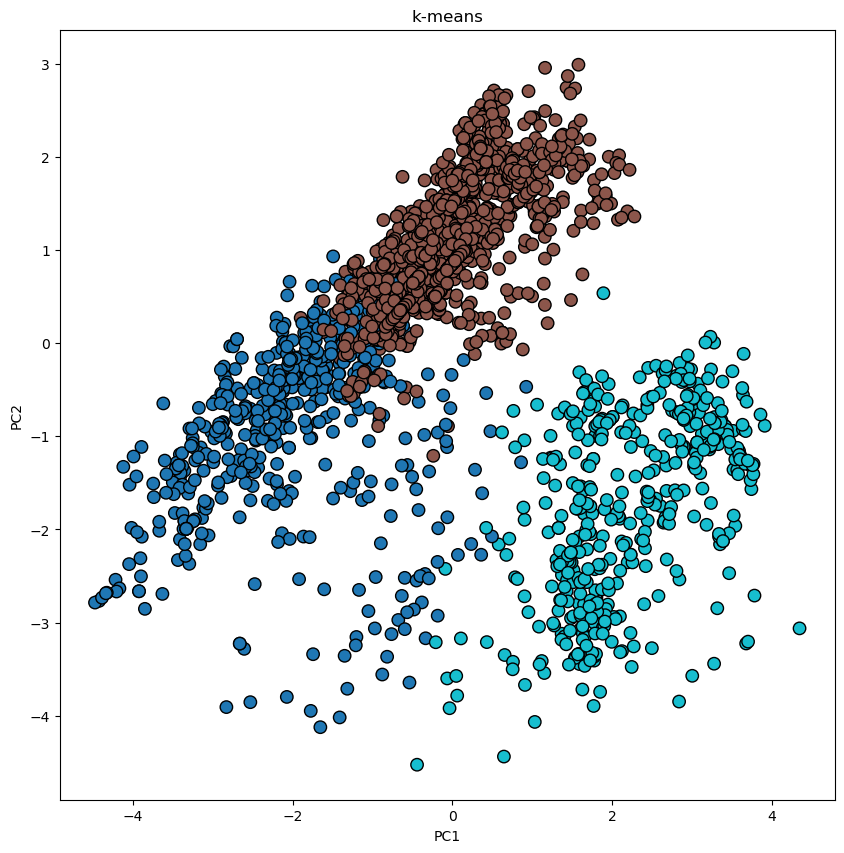

In [45]:
k = 3
kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42)
clusters = kmeans.fit_predict(df_pca) 

plt.figure(figsize=(10,10))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, s=80, cmap = "tab10", edgecolor="black", linewidth=1)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("k-means")
plt.show()

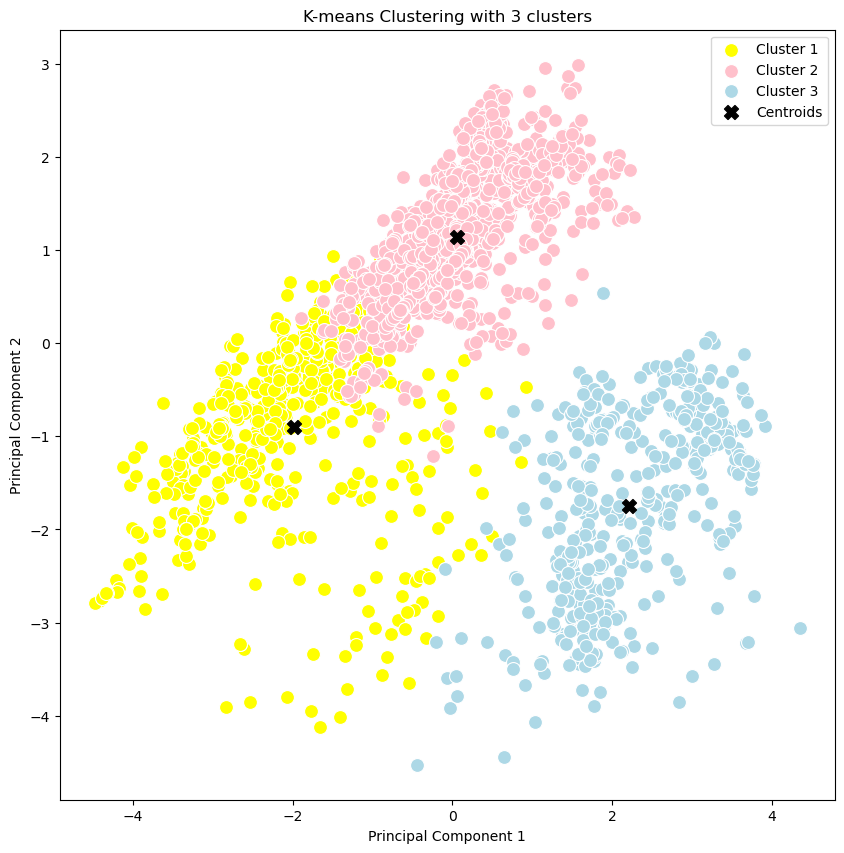

In [46]:
df_pca["clusters"] = clusters

centroids = kmeans.cluster_centers_.T 

colors = ["yellow", "pink", "lightblue"]

fig, ax = plt.subplots(figsize=(10, 10))

for k in range(0, 3):
    sns.scatterplot(x=df_pca["PC1"][df_pca.clusters == k], y=df_pca["PC2"][df_pca.clusters == k], color=colors[k], label="Cluster {}".format(k+1), s=100)

ax.scatter(centroids[0][:], centroids[1][:], marker="X", s=100, color="black", label="Centroids")
ax.set_title("K-means Clustering with 3 clusters")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
plt.legend()
plt.show()

Due to the mixed nature of the dataset and the limited variance explained by the first components of the PCA, we believed that a linear dimensionality reduction might not faithfully represent the true structure of the data.<br><br>

To overcome these limitations, we adopted a Gower distance-based approach, capable of simultaneously handling different data types.

In [47]:
# Calculating the distance matrix
dist_matrix = gower.gower_matrix(dataset_clean.drop(columns=['Obesity_Level']))

# Scipy linkage requires the matrix in condensed form (vector) or the raw data
dist_condensed = squareform(dist_matrix)

#### Hierarchical Clustering
Since the Gower distance produces a similarity/dissimilarity matrix that takes into account Boolean, categorical, and numeric variables, hierarchical clustering can process it directly.

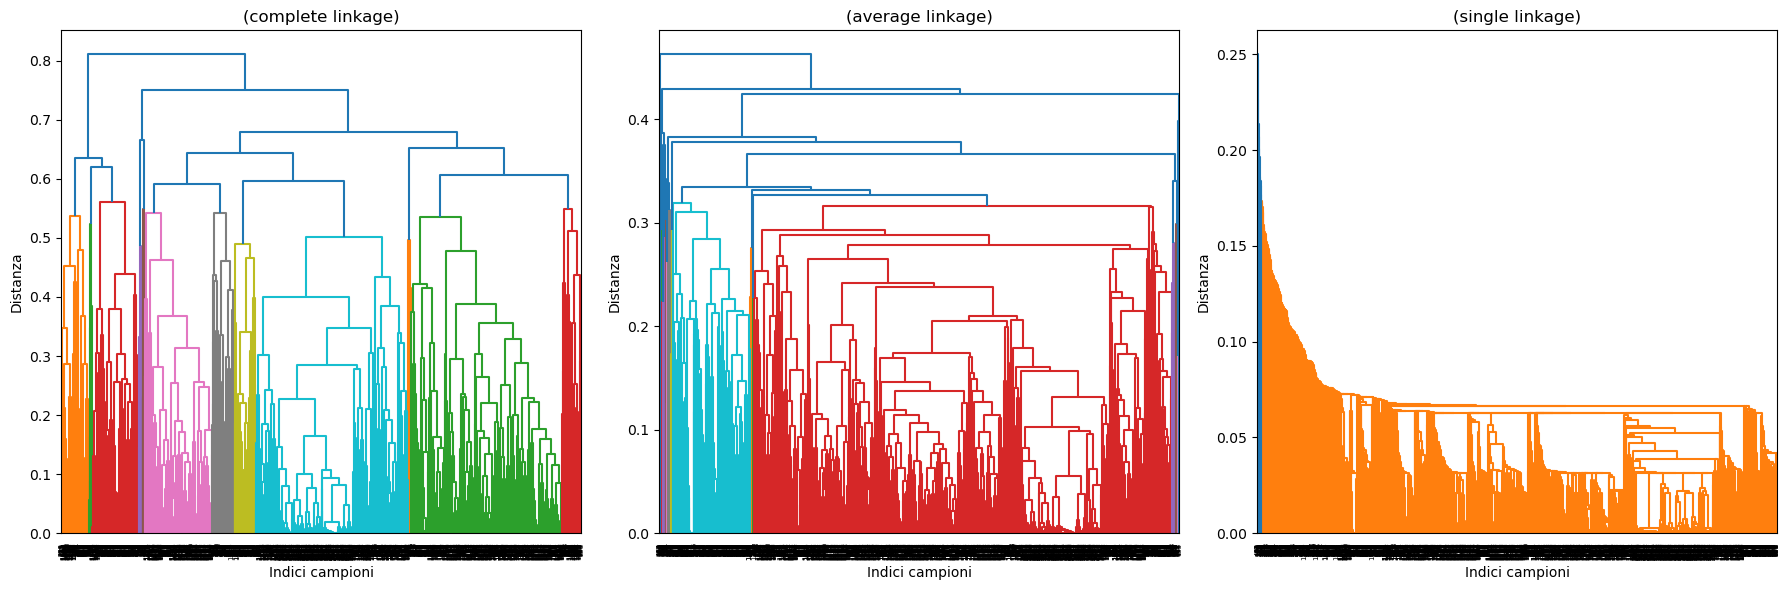

In [48]:
linkage_single = linkage(dist_condensed, method='single')
linkage_average = linkage(dist_condensed, method='average')
linkage_complete = linkage(dist_condensed, method='complete')

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
for i, (method, linkage_matrix) in enumerate([('complete', linkage_complete), ('average', linkage_average), ('single', linkage_single)]):
    dendrogram(linkage_matrix, ax=ax[i])
    ax[i].set_title(f'({method} linkage)')
    ax[i].set_xlabel('Indici campioni')
    ax[i].set_ylabel('Distanza')

plt.tight_layout()
plt.show()

In [49]:
# Calculation of the cophenetic correlation for each method
c_complete, _ = cophenet(linkage_complete, dist_condensed)
c_average, _ = cophenet(linkage_average, dist_condensed)
c_single, _ = cophenet(linkage_single, dist_condensed)

print(f"Cophenitic coefficient (Complete): {c_complete:.4f}")
print(f"Cophenitic coefficient (Average):  {c_average:.4f}")
print(f"Cophenitic coefficient (Single):   {c_single:.4f}")

results = {
    'Complete': c_complete,
    'Average': c_average,
    'Single': c_single
}
best_method = max(results, key=results.get)
print(f"\nThe best method according to cophenetic correlation is: {best_method}")

Cophenitic coefficient (Complete): 0.5778
Cophenitic coefficient (Average):  0.7156
Cophenitic coefficient (Single):   0.5931

The best method according to cophenetic correlation is: Average



Height 1: 0.450
    Number of clusters: 2
    Silhouette score: 0.3961

Height 2: 0.400
    Number of clusters: 5
    Silhouette score: 0.2864

Height 3: 0.350
    Number of clusters: 12
    Silhouette score: 0.1456


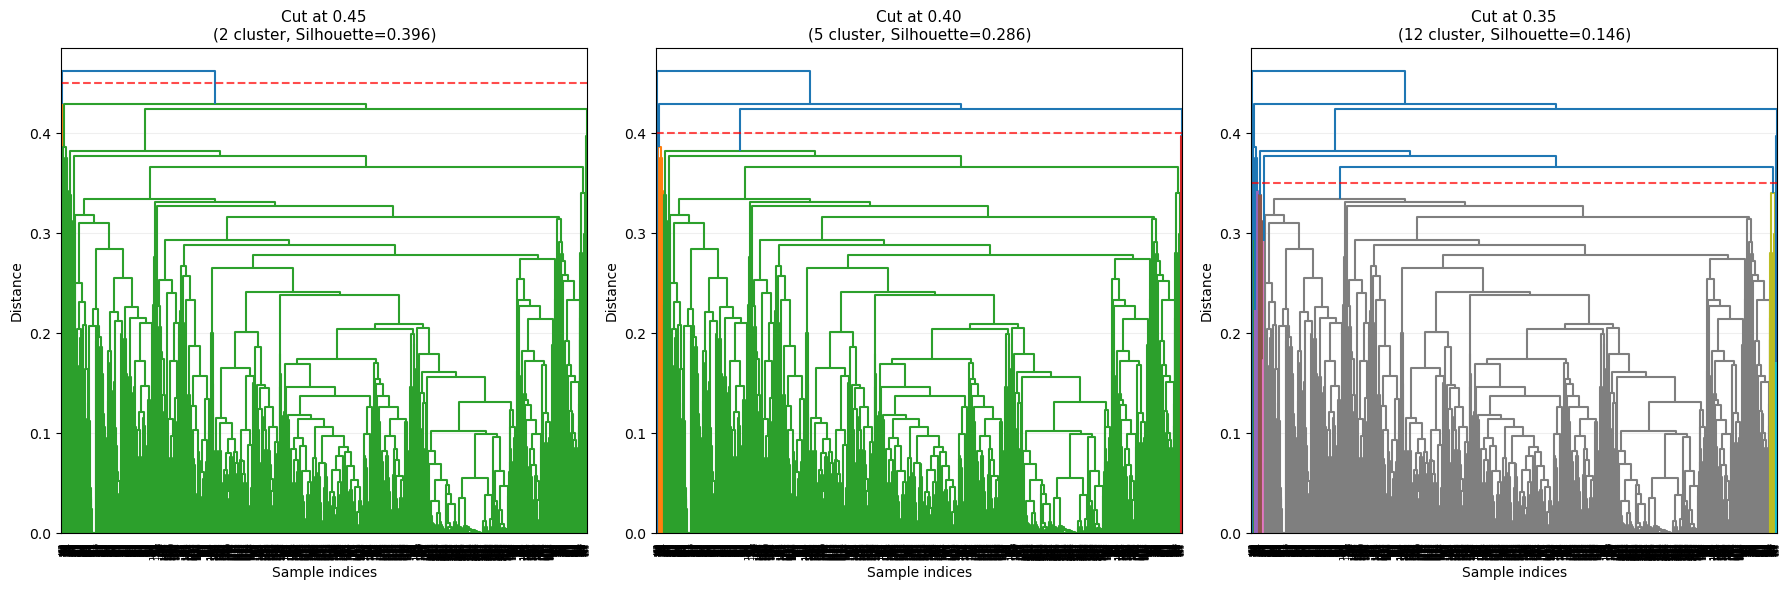

In [50]:
thresholds_to_test = [0.45, 0.40, 0.35]
silhouette_results = []

for i, threshold in enumerate(thresholds_to_test, 1):
    # Cut the dendrogram
    clusters = fcluster(linkage_average, t=threshold, criterion='distance')
    n_clusters = len(np.unique(clusters))
    
    # silhouette score
    if 2 <= n_clusters < dist_matrix.shape[0]:
        sil_score = silhouette_score(dist_matrix, clusters, metric='precomputed')
        silhouette_results.append({
            'threshold': threshold,
            'n_clusters': n_clusters,
            'silhouette_score': sil_score
        })
        
        print(f"\nHeight {i}: {threshold:.3f}")
        print(f"    Number of clusters: {n_clusters}")
        print(f"    Silhouette score: {sil_score:.4f}")
    else:
        print(f"\nHeight {i}: {threshold:.3f}")
        print(f"    Numero cluster: {n_clusters}")
        print(f"    Silhouette score: Not Computable (too many/few clusters)")

print("="*60)

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

for i, threshold in enumerate(thresholds_to_test):
    _ = dendrogram(linkage_average, ax=ax[i], color_threshold=threshold)
    
    result = next((r for r in silhouette_results if r['threshold'] == threshold), None)
    if result:
        title = f'Cut at {threshold:.2f}\n({result["n_clusters"]} cluster, Silhouette={result["silhouette_score"]:.3f})'
    else:
        title = f'Cut at {threshold:.2f}'
    
    ax[i].set_title(title, fontsize=11)
    ax[i].axhline(y=threshold, color='r', linestyle='--', linewidth=1.5, alpha=0.7)
    ax[i].set_xlabel('Sample indices', fontsize=10)
    ax[i].set_ylabel('Distance', fontsize=10)
    ax[i].grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.show()

These dendrograms are extremely revealing and confirm that the dataset has a highly unbalanced structure.<br>
Despite a discrete Silhouette score for $k=2$, the visualization reveals that the algorithm identifies a single predominant macro-cluster and a series of micro-clusters composed of outliers. <br><br>
This indicates that the variability of the dataset is not organized into clearly distinct categories, but is distributed around a common modal profile, necessitating a more robust partitioning technique such as K-medoids
<br><br><br>
#### K-Medoids

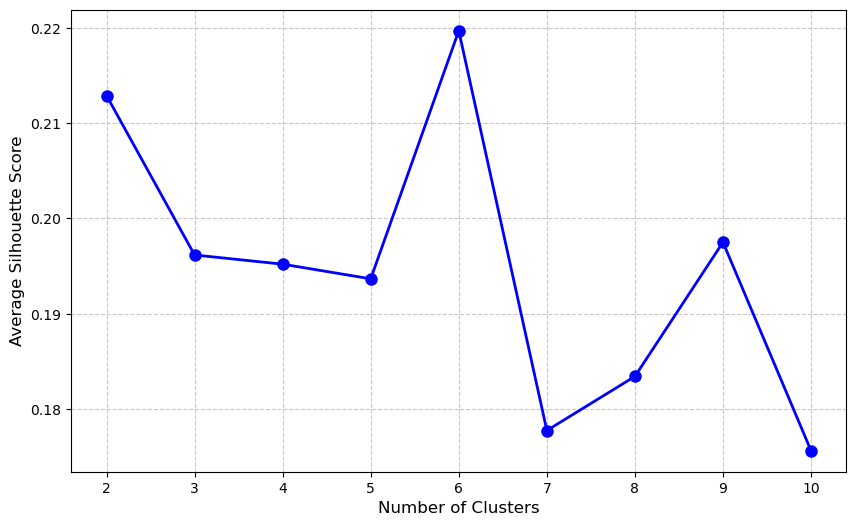

In [51]:
n_samples = dist_matrix.shape[0]
range_n_clusters = range(2, 11)
silhouette_avg_list = []

for n_clusters in range_n_clusters:
    
    np.random.seed(42)
    initial_medoids = np.random.choice(n_samples, n_clusters, replace=False).tolist()
    kmed = kmedoids(dist_matrix, initial_medoids, data_type='distance_matrix')
    kmed.process()
    
    clusters = kmed.get_clusters()
    labels = np.zeros(n_samples)
    for cluster_id, indices in enumerate(clusters):
        for idx in indices:
            labels[idx] = cluster_id
            
    score = silhouette_score(dist_matrix, labels, metric="precomputed")
    silhouette_avg_list.append(score)

plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, silhouette_avg_list, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)
best_k = range_n_clusters[np.argmax(silhouette_avg_list)]
max_score = max(silhouette_avg_list)
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('Average Silhouette Score', fontsize=12)
plt.xticks(range_n_clusters)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

Silhouette score analysis for K-medoids shows a global peak at $k=6$. <br><br>

Unlike hierarchical clustering, which tended to group almost all observations into a single macro-cluster, K-medoids allowed us to identify population segments with specific and differentiated habits.

In [52]:
k = 6
np.random.seed(42) 
n_samples = dist_matrix.shape[0]
initial_medoids = np.random.choice(n_samples, k, replace=False).tolist()

kmed = kmedoids(dist_matrix, initial_medoids, data_type='distance_matrix')
kmed.process()

clusters = kmed.get_clusters()  
medoids = kmed.get_medoids()    

labels = np.zeros(n_samples, dtype=int)
for cluster_id, indices in enumerate(clusters):
    for idx in indices:
        labels[idx] = cluster_id

print(f"Clustering completed with k={k}")
print(f"Medoid indices: {medoids}")

Clustering completed with k=6
Medoid indices: [1187, 1942, 224, 1291, 1120, 1227]


In [76]:
df_medoids = dataset_clean.iloc[medoids].copy()
df_medoids['Cluster_ID'] = range(k)
print("Medoids:\n")
display(df_medoids)

Medoids:



,Gender,Age,Height,Weight,family_history_with_overweight,High_Caloric_Food,Vegetable_Consumption,Main_Meals_Per_Day,Food_Between_Meals,SMOKE,Water_Intake,Calorie_Monitoring,Physical_Activity_Frequency,Tech_use_Time,Alcohol_Consumption,Transport_Mode,Obesity_Level,Cluster_ID
1193,Male,32,183,91,yes,yes,2,3,Sometimes,no,2,no,1,0,Sometimes,Automobile,Overweight_Level_II,0
1948,Female,23,168,114,yes,yes,3,3,Sometimes,no,2,no,0,1,Sometimes,Public_Transportation,Obesity_Type_III,1
227,Female,24,162,58,no,yes,3,3,Sometimes,no,2,no,1,1,Sometimes,Public_Transportation,Normal_Weight,2
1297,Female,23,163,84,yes,yes,2,3,Sometimes,no,2,no,1,1,no,Public_Transportation,Obesity_Type_I,3
1126,Male,23,176,90,yes,yes,2,3,Sometimes,no,2,no,1,0,Sometimes,Public_Transportation,Overweight_Level_II,4
1233,Male,23,171,91,yes,yes,2,3,Sometimes,no,2,no,1,1,no,Public_Transportation,Obesity_Type_I,5


In [54]:
print("\nCLUSTER ANALYSIS ")
for i in range(k):
    cluster_size = np.sum(labels == i)
    percentage = (cluster_size / len(labels)) * 100
    print(f"\nCluster {i}:")
    print(f"  - Dimension: {cluster_size} observations ({percentage:.1f}%)")


CLUSTER ANALYSIS 

Cluster 0:
  - Dimension: 321 observations (15.2%)

Cluster 1:
  - Dimension: 449 observations (21.3%)

Cluster 2:
  - Dimension: 243 observations (11.5%)

Cluster 3:
  - Dimension: 294 observations (13.9%)

Cluster 4:
  - Dimension: 511 observations (24.2%)

Cluster 5:
  - Dimension: 290 observations (13.8%)


In [55]:
df = dataset_clean.copy()
df["Clusters"] = labels

In [56]:
# Numeric vars profiling
numeric_profile = df.groupby('Clusters')[num_vars].mean()
display(numeric_profile)

,Age,Height,Weight,Main_Meals_Per_Day,Physical_Activity_Frequency
Clusters,,,,,
0,32.118380,173.059190,92.180685,2.750779,1.052960
1,23.610245,167.645880,107.790646,2.835189,0.654788
2,20.814815,162.041152,52.395062,2.609053,1.053498
3,24.023810,163.248299,68.925170,2.391156,0.908163
4,22.804305,176.835616,91.718200,2.743640,1.113503
5,22.555172,172.993103,85.248276,2.658621,1.362069


In [57]:
cat_mode_profile = df.groupby('Clusters')[vars_to_analyze].agg(lambda x: x.mode()[0])

print("Mode for each cluster:")
display(cat_mode_profile)

Mode for each cluster:


,Vegetable_Consumption,Water_Intake,Tech_use_Time,Gender,family_history_with_overweight,High_Caloric_Food,Food_Between_Meals,SMOKE,Calorie_Monitoring,Alcohol_Consumption,Transport_Mode,Obesity_Level
Clusters,,,,,,,,,,,,
0,2,2,0,Male,yes,yes,Sometimes,no,no,Sometimes,Automobile,Obesity_Type_II
1,3,2,1,Female,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_III
2,3,2,1,Female,no,yes,Sometimes,no,no,Sometimes,Public_Transportation,Insufficient_Weight
3,2,2,1,Female,yes,yes,Sometimes,no,no,no,Public_Transportation,Obesity_Type_I
4,2,2,0,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_II
5,2,2,1,Male,yes,yes,Sometimes,no,no,no,Public_Transportation,Obesity_Type_I


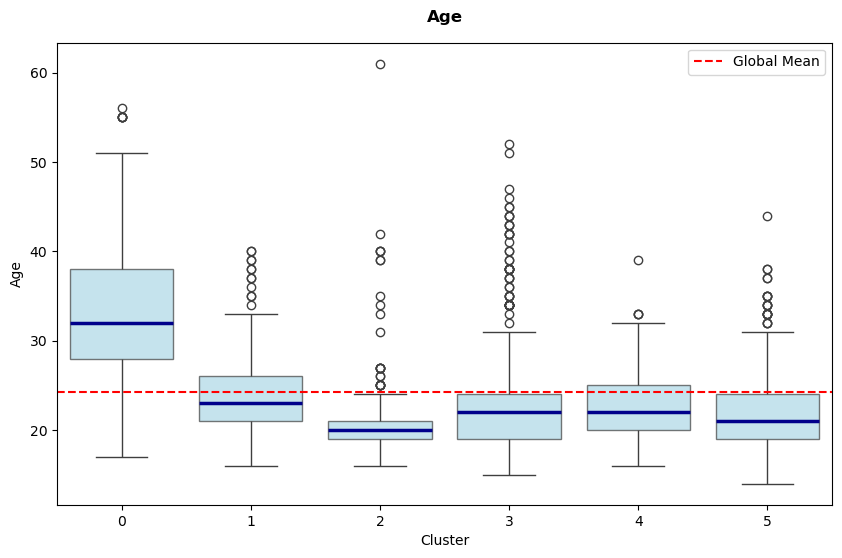

In [58]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='Clusters', y="Age", data=df, boxprops=dict(facecolor="lightblue", alpha=0.7), medianprops=dict(color="darkblue", linewidth=2.5))

plt.title("Age", fontweight='bold', pad=15)
plt.xlabel('Cluster')

plt.axhline(df["Age"].mean(), color='red', linestyle='--', label='Global Mean')
plt.legend()

plt.show()

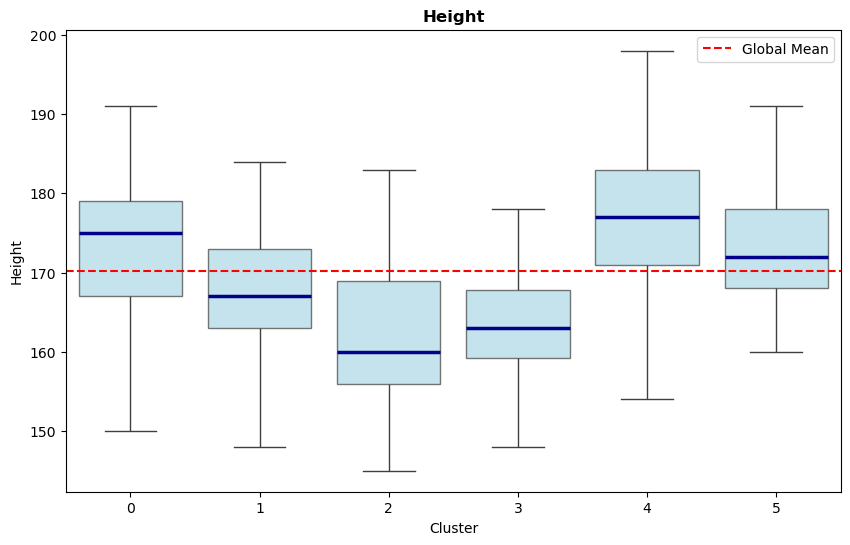

In [59]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='Clusters', y='Height', data=df, boxprops=dict(facecolor="lightblue", alpha=0.7), medianprops=dict(color="darkblue", linewidth=2.5))

plt.title("Height", fontweight='bold')
plt.xlabel('Cluster')

plt.axhline(df['Height'].mean(), color='red', linestyle='--', label='Global Mean')
plt.legend()

plt.show()

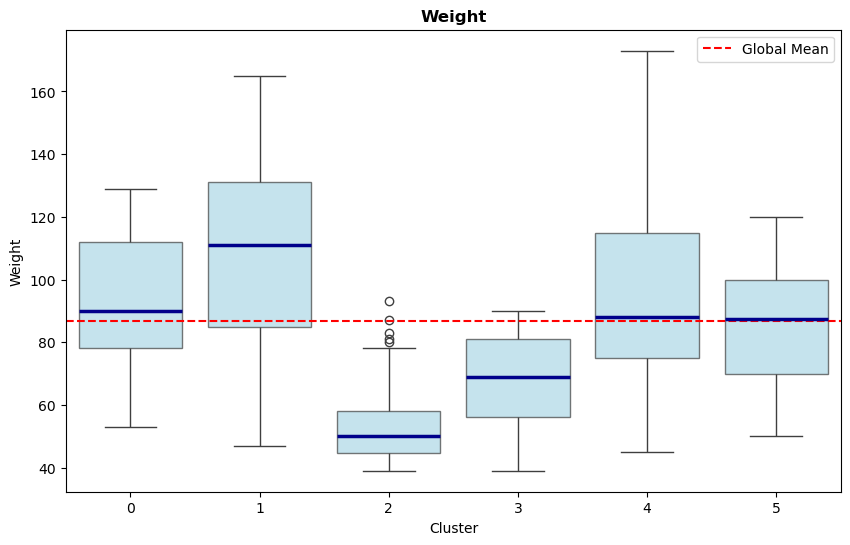

In [60]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='Clusters', y='Weight', data=df, boxprops=dict(facecolor="lightblue", alpha=0.7), medianprops=dict(color="darkblue", linewidth=2.5))

plt.title('Weight', fontweight='bold')
plt.xlabel('Cluster')

plt.axhline(df['Weight'].mean(), color='red', linestyle='--', label='Global Mean')
plt.legend()

plt.show()

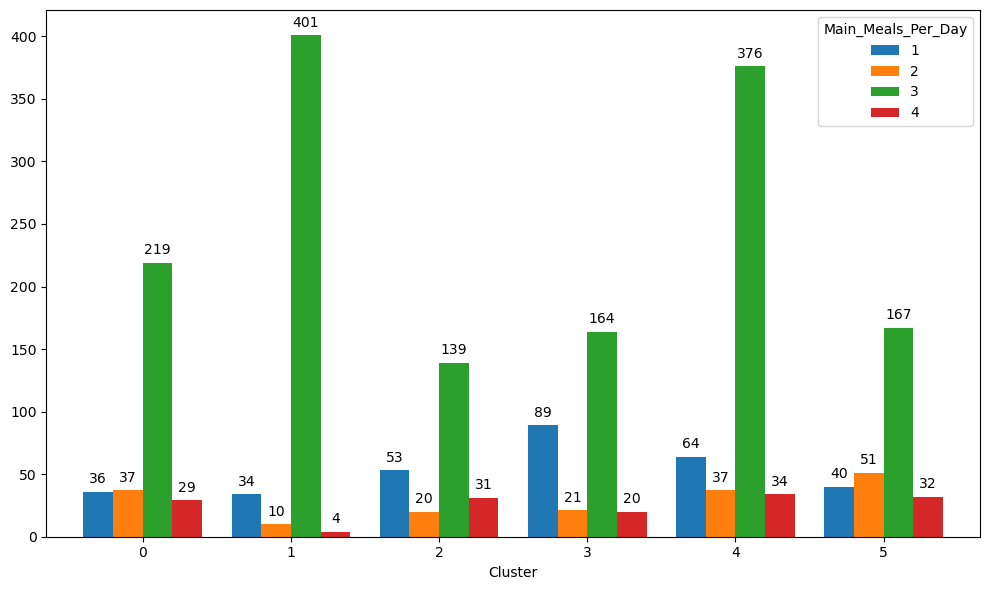

In [61]:
ax = df.groupby(['Clusters', 'Main_Meals_Per_Day']).size().unstack(fill_value=0).plot(kind='bar', figsize=(10, 6), width=0.8)

plt.xlabel('Cluster')
plt.xticks(rotation=0) 
plt.legend(title='Main_Meals_Per_Day')


for p in ax.patches:
    ax.annotate(str(int(p.get_height())), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

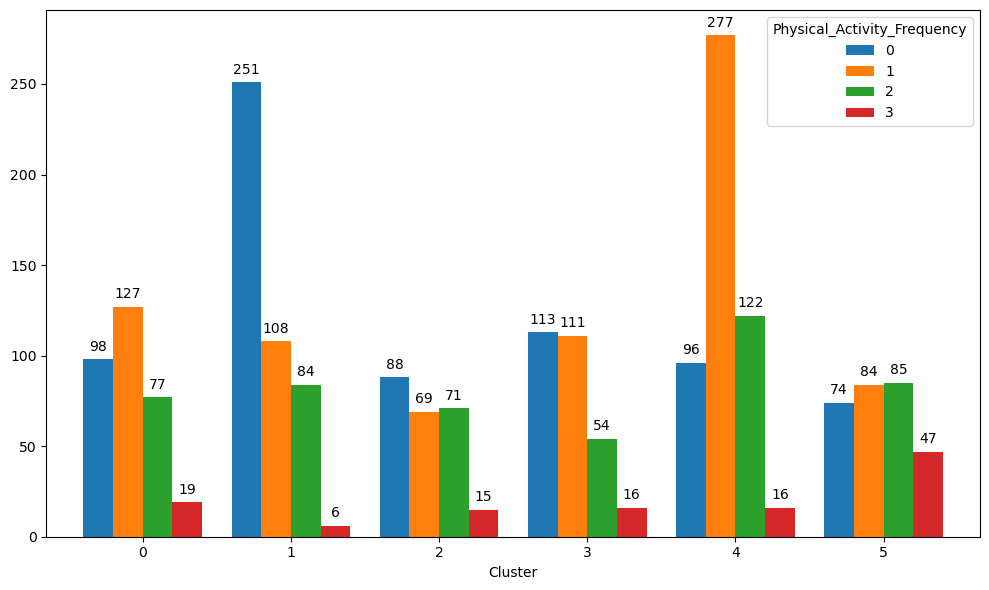

In [62]:
ax = df.groupby(['Clusters', 'Physical_Activity_Frequency']).size().unstack(fill_value=0).plot(kind='bar', figsize=(10, 6), width=0.8)
plt.xlabel('Cluster')
plt.xticks(rotation=0) 
plt.legend(title='Physical_Activity_Frequency')


for p in ax.patches:
    ax.annotate(str(int(p.get_height())), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

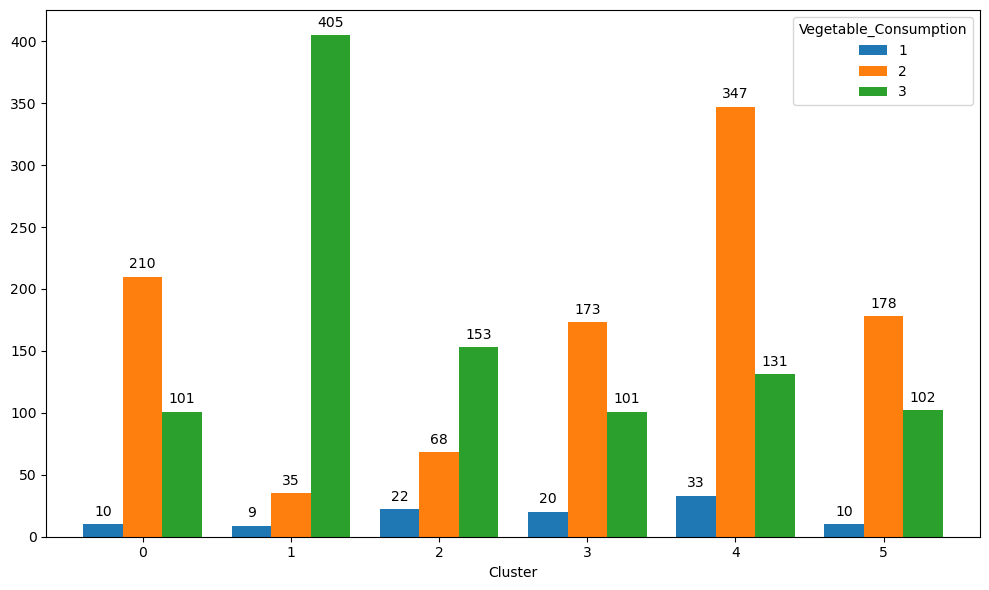

In [63]:
ax = df.groupby(['Clusters', 'Vegetable_Consumption']).size().unstack(fill_value=0).plot(kind='bar', figsize=(10, 6), width=0.8)

plt.xlabel('Cluster')
plt.xticks(rotation=0) 
plt.legend(title='Vegetable_Consumption')


for p in ax.patches:
    ax.annotate(str(int(p.get_height())), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

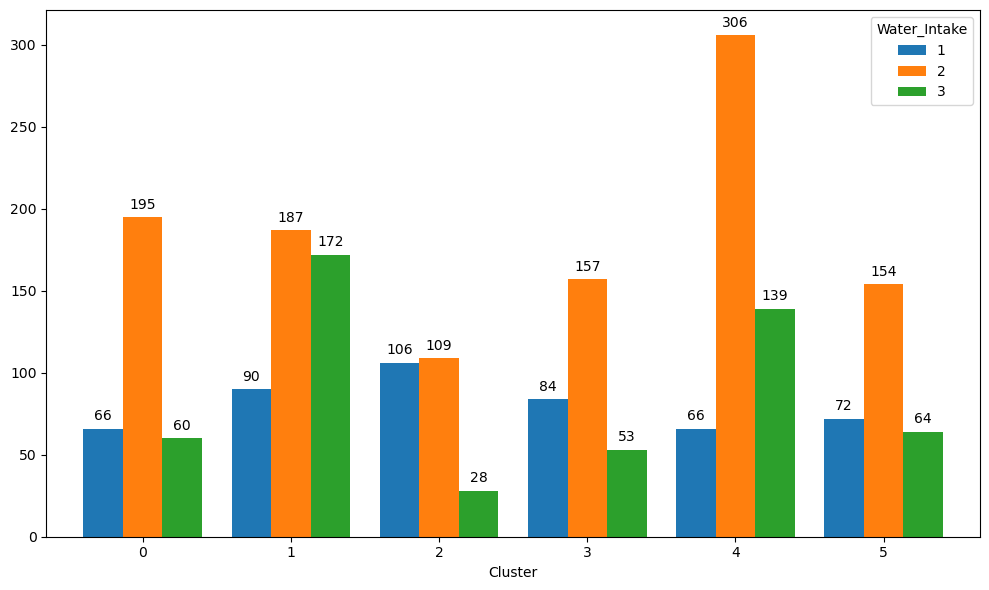

In [64]:
ax = df.groupby(['Clusters', 'Water_Intake']).size().unstack(fill_value=0).plot(kind='bar', figsize=(10, 6), width=0.8)

plt.xlabel('Cluster')
plt.xticks(rotation=0) 
plt.legend(title='Water_Intake')


for p in ax.patches:
    ax.annotate(str(int(p.get_height())), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

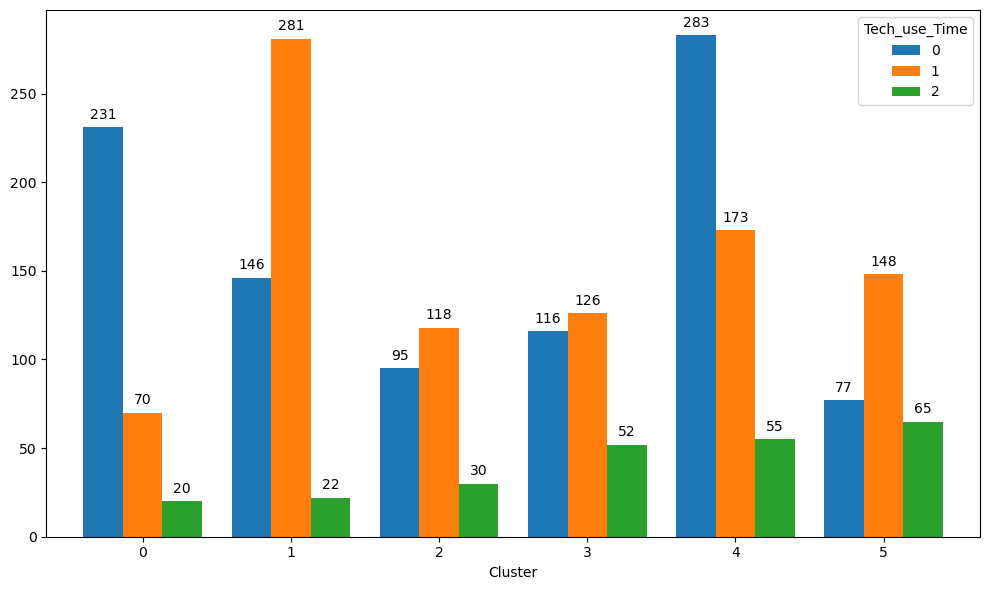

In [65]:
ax = df.groupby(['Clusters', 'Tech_use_Time']).size().unstack(fill_value=0).plot(kind='bar', figsize=(10, 6), width=0.8)

plt.xlabel('Cluster')
plt.xticks(rotation=0) 
plt.legend(title='Tech_use_Time')


for p in ax.patches:
    ax.annotate(str(int(p.get_height())), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

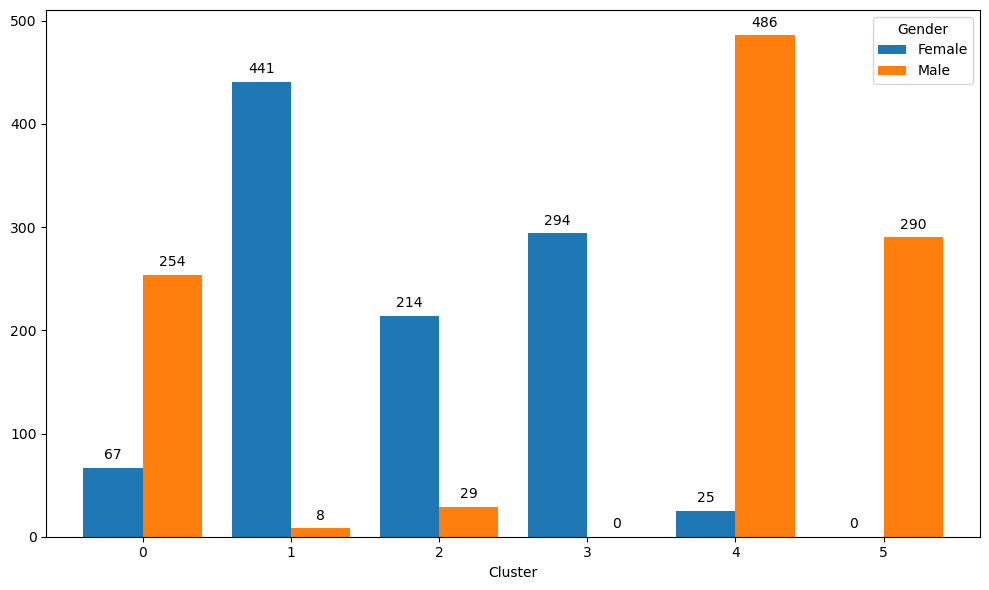

In [66]:
ax = df.groupby(['Clusters', 'Gender']).size().unstack(fill_value=0).plot(kind='bar', figsize=(10, 6), width=0.8)

plt.xlabel('Cluster')
plt.xticks(rotation=0) 
plt.legend(title='Gender')


for p in ax.patches:
    ax.annotate(str(int(p.get_height())), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

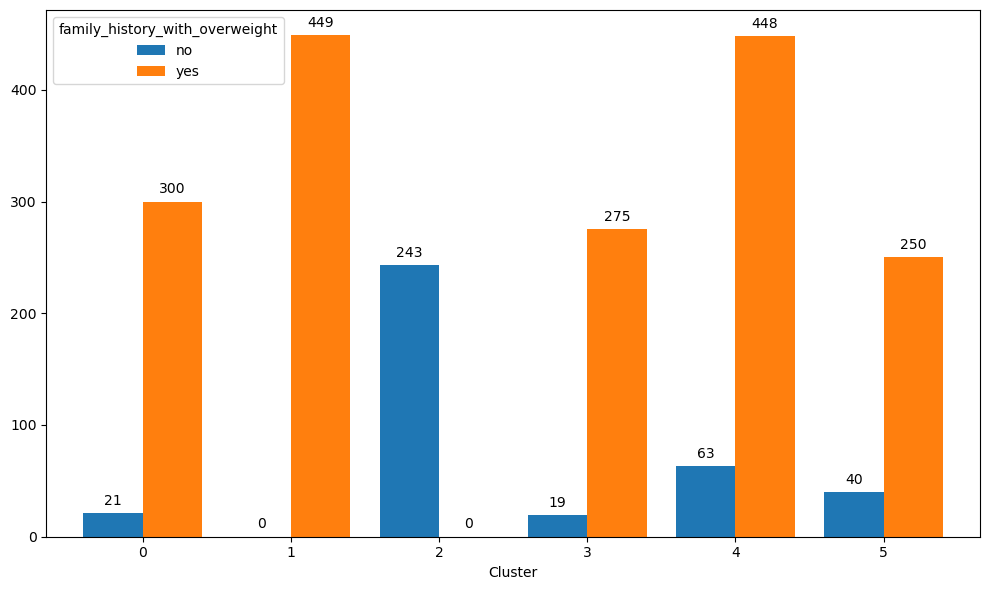

In [67]:
ax = df.groupby(['Clusters', 'family_history_with_overweight']).size().unstack(fill_value=0).plot(kind='bar', figsize=(10, 6), width=0.8)

plt.xlabel('Cluster')
plt.xticks(rotation=0) 
plt.legend(title='family_history_with_overweight')


for p in ax.patches:
    ax.annotate(str(int(p.get_height())), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

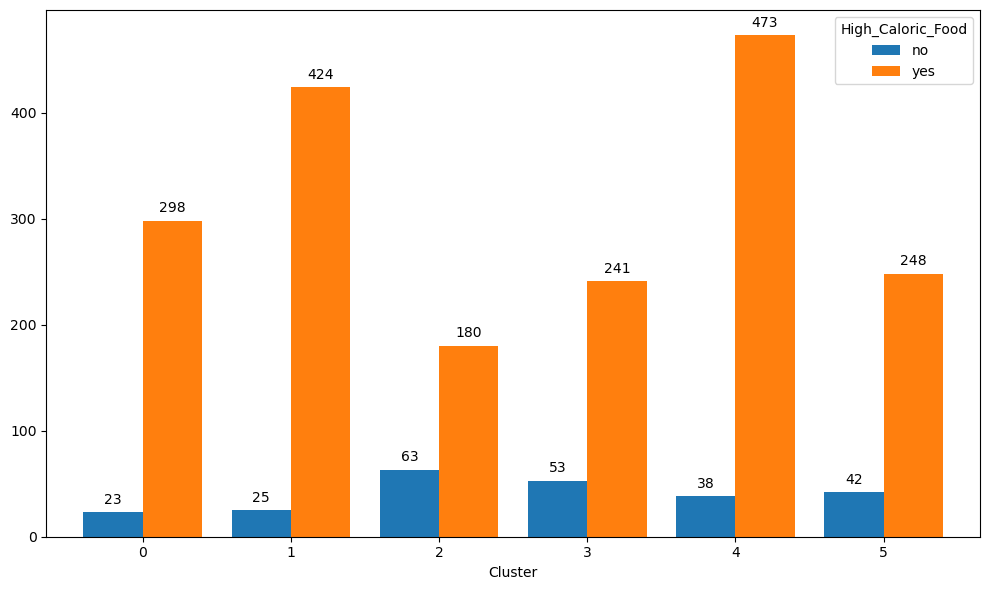

In [68]:
ax = df.groupby(['Clusters', 'High_Caloric_Food']).size().unstack(fill_value=0).plot(kind='bar', figsize=(10, 6), width=0.8)

plt.xlabel('Cluster')
plt.xticks(rotation=0) 
plt.legend(title='High_Caloric_Food')


for p in ax.patches:
    ax.annotate(str(int(p.get_height())), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

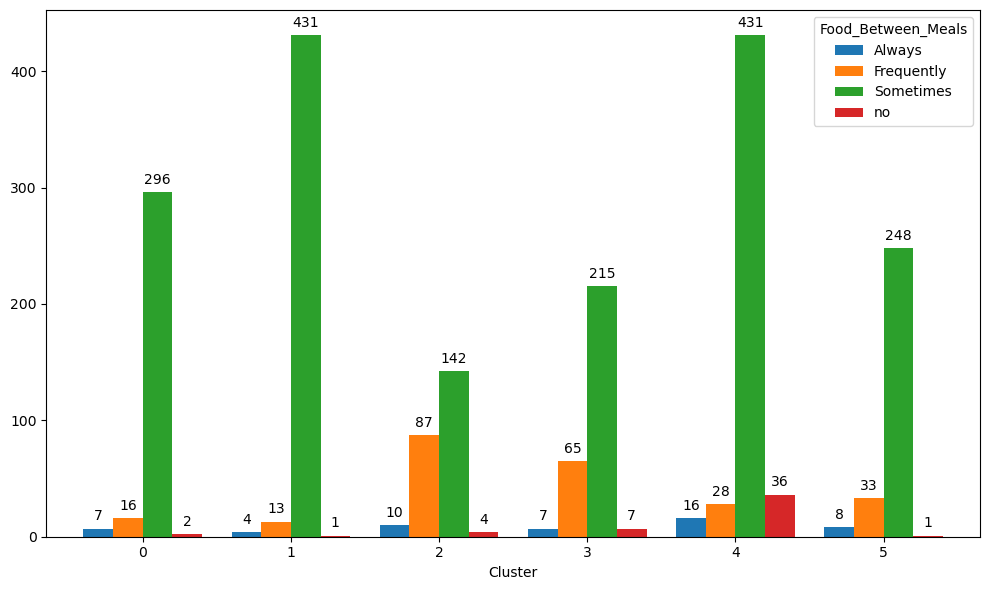

In [69]:
ax = df.groupby(['Clusters', 'Food_Between_Meals']).size().unstack(fill_value=0).plot(kind='bar', figsize=(10, 6), width=0.8)

plt.xlabel('Cluster')
plt.xticks(rotation=0) 
plt.legend(title='Food_Between_Meals')


for p in ax.patches:
    ax.annotate(str(int(p.get_height())), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

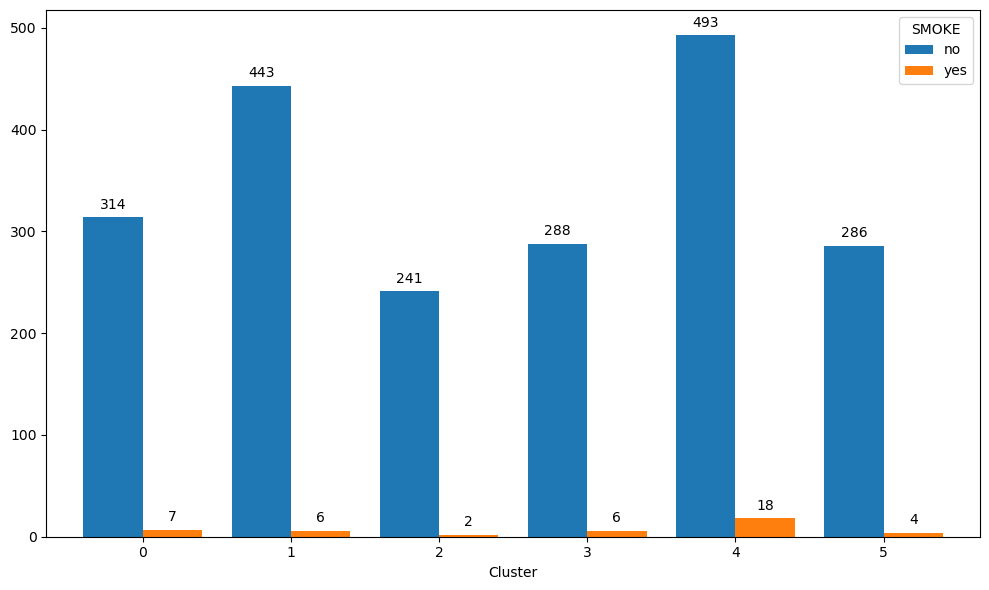

In [70]:
ax = df.groupby(['Clusters', 'SMOKE']).size().unstack(fill_value=0).plot(kind='bar', figsize=(10, 6), width=0.8)

plt.xlabel('Cluster')
plt.xticks(rotation=0) 
plt.legend(title='SMOKE')


for p in ax.patches:
    ax.annotate(str(int(p.get_height())), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

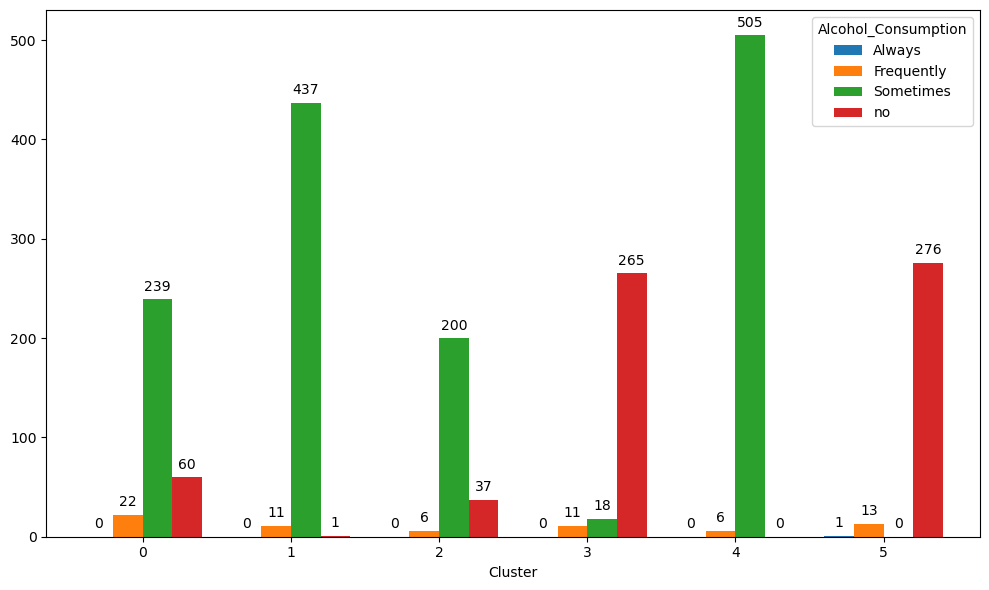

In [71]:
ax = df.groupby(['Clusters', 'Alcohol_Consumption']).size().unstack(fill_value=0).plot(kind='bar', figsize=(10, 6), width=0.8)

plt.xlabel('Cluster')
plt.xticks(rotation=0) 
plt.legend(title='Alcohol_Consumption')

for p in ax.patches:
    ax.annotate(str(int(p.get_height())), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

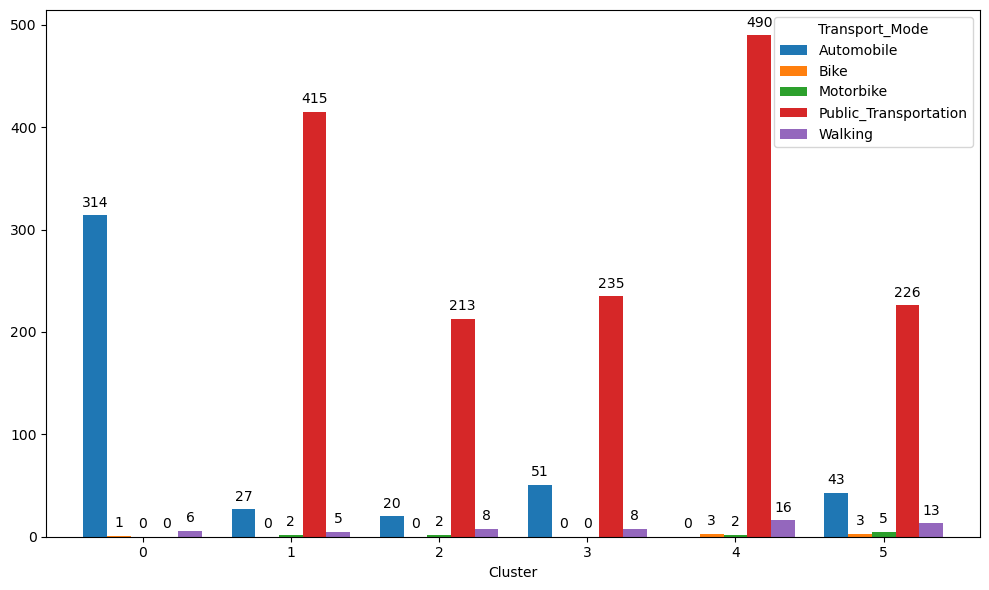

In [72]:
ax = df.groupby(['Clusters', 'Transport_Mode']).size().unstack(fill_value=0).plot(kind='bar', figsize=(10, 6), width=0.8)

plt.xlabel('Cluster')
plt.xticks(rotation=0) 
plt.legend(title='Transport_Mode')

for p in ax.patches:
    ax.annotate(str(int(p.get_height())), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

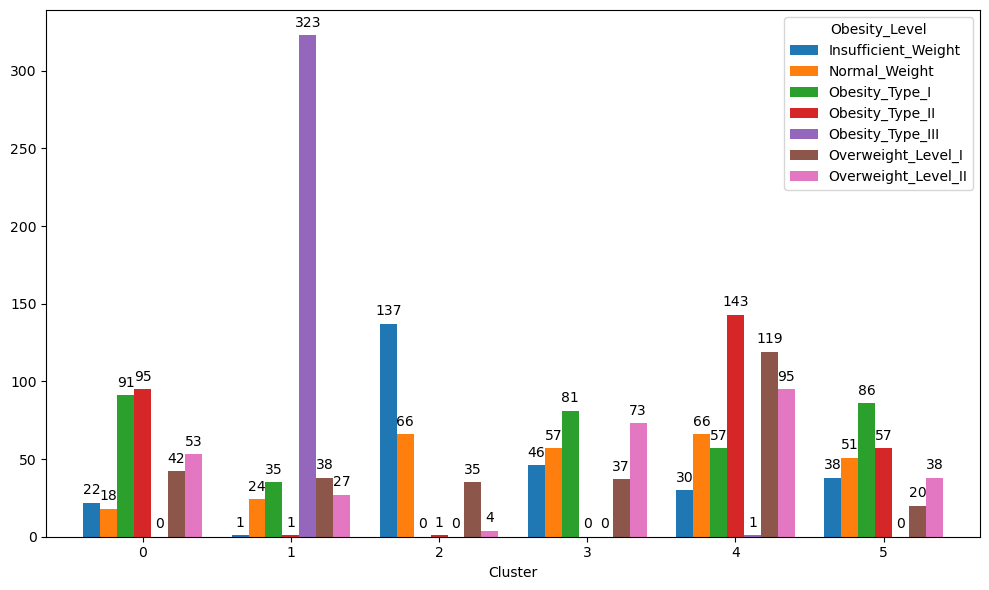

In [73]:
ax = df.groupby(['Clusters', 'Obesity_Level']).size().unstack(fill_value=0).plot(kind='bar', figsize=(10, 6), width=0.8)

plt.xlabel('Cluster')
plt.xticks(rotation=0) 
plt.legend(title='Obesity_Level')

for p in ax.patches:
    ax.annotate(str(int(p.get_height())), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

## Summary and Interpretation
The dataset analysed contains 2,114 observations and 17 variables, with information on gender, age, height, weight, eating habits and physical activity, alcohol consumption, transport use, and a target variable relating to obesity levels. <br>
The number of missing values is very low (approximately 0–1%), relating to 6 observations, confirming the quality of the dataset. <br>
From the analysis conducted, we can state that the variables that show clear differences within the groups created refer to daily behaviours that therefore strongly influence the level of obesity. The variables in question are 'frequency of physical activity', 'type of transport used' and 'eating habits'. <br> The variable 'family history of overweight' also has a strong influence on the level of obesity, highlighting the importance of genetics. <br> We can obviously see that, in general, increasing age corresponds to a less favourable physical condition.